### Testing code functionality
Amy - Sep 2026

***Maria's note***:
**Changes from Amy's notebook (dataset setup):**
- 20 x 20 D–T2 points instead of 10 x 10.
- 8 b-values (0-4) s 8 TEs (20–180 ms) instead of 20 b-values (0–10) s 20 TEs (10–200 ms), so far fewer measurements per voxel
- More voxels, 80 instead of 12.
- SVD rank R = 10 instead of 8
- New true compartments, the same as in demo_pipeline: centres at (D, T2) = (0.4, 90), (0.9, 55), (1.6, 120), with a different width for each
- Added a mean version of the NNLS initialisation (define_initial_C_NNLS_mean in optimiser), which averages the signals before solving NNLS
- Sections 3 and 4 use their own fixed random seed, so they run on the same data and can be compared


#### First create some GT spectra

In [26]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *
from metrics import voxelwise_spectrum_mae

rng=np.random.default_rng(40)

In [27]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        3, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 8.5),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        for row, (name, F) in enumerate([("Ground truth", F_true), ("Estimated", F_est)]):
            image = axes[row, col].imshow(
                F[:, voxel].reshape(nD, nT2),
                origin="lower",
                aspect="auto",
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
            )
            axes[row, col].set_title(f"{name}: voxel {voxel}")
            axes[row, col].set_xlabel("T2 (ms)")
            axes[row, col].set_ylabel("D")
            fig.colorbar(image, ax=axes[row, col], shrink=0.75)

        # The third row reports the component weights that form this spectrum.
        components = np.arange(W_true.shape[0])
        axes[2, col].bar(components - 0.18, W_true[:, voxel], 0.36, label="Ground truth")
        axes[2, col].bar(components + 0.18, W_est[:, voxel], 0.36, label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")
        if col == 0:
            axes[2, col].legend()

    plt.show()

def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est

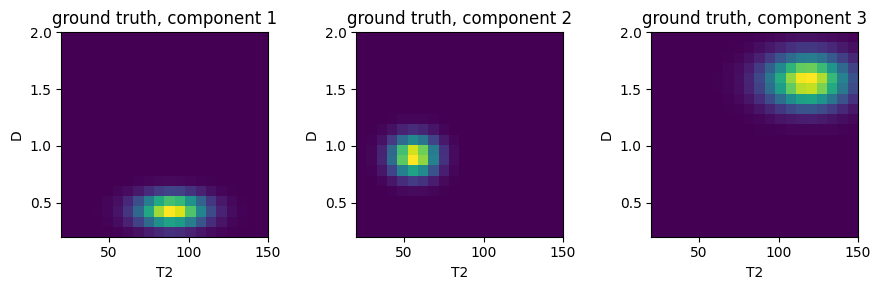

In [28]:

Dmin, T2min, Dmax, T2max, nD, nT2 = 0.2, 20.0, 2.0, 150.0, 20, 20
Bmin, Bmax, nB, TEmin, TEmax, nTE = 0.0, 4.0, 8, 20.0, 180.0, 8

voxels_to_show = [10, 20, 30, 40, 50, 60, 70]

# three ground-truth compartments, each a Gaussian blob in (D, T2) space
D_means = [0.4, 0.9, 1.6]
D_stds = [0.10, 0.12, 0.16]
T2_means = [90, 55, 120]
T2_stds = [15, 10, 18]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)
b_vals = np.linspace(Bmin, Bmax, nB)
TE_vals = np.linspace(TEmin, TEmax, nTE)

# Define fitting parameters
K=3; # Number of canonical spectra
V=80; # Number of voxels
R=10   # Rank for SVD    

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2); 
# Create A matrix
A = create_A_matrix(D,T2,Bmin,Bmax,nB,TEmin,TEmax,nTE); 
# Create true C - canonical spectra
# Here have hardcoded centres
C_true = create_gaussian_compartments(D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds)

# Define GT weights
W_true = rng.uniform(size=(K, V))
W_true /= W_true.sum(axis=0, keepdims=True)

# Set scale parameter
M0_true=np.ones(V)*300;

# Calulate the signal Y = M0 * A * C_true * W_true
SNR = 50
sigma = M0_true/SNR # sigma needs to scale with M0
Y=create_signal(A,C_true,W_true,M0_true,sigma,rng)

# Create GT C_small using SVD
U,s,Vmat=apply_SVD_to_A(A,R)
C_small_true=project_C_to_C_small(C_true,s,Vmat)
#C_small_true = np.diag(s) @ V_mat.T @ C_true - should be equivalent

show_canonical_spectra([('ground truth', C_true)])


#### Run optimisation

I added a function, define_initial_C_NNLS_mean, that averages the signals over all voxels first and then solves one NNLS on the average. The original define_initial_C_NNLS solves NNLS on each voxel and averages the spectra. Both then use k-means on the averaged spectrum to find the component centres and place one Gaussian at each centre.

**Result:** The original (spectrum-averaged) version puts the components in the wrong places here. The new signal-averaged version finds all three in the right places. Only the second is kept, so everything below starts from the signal-averaged initialisation.


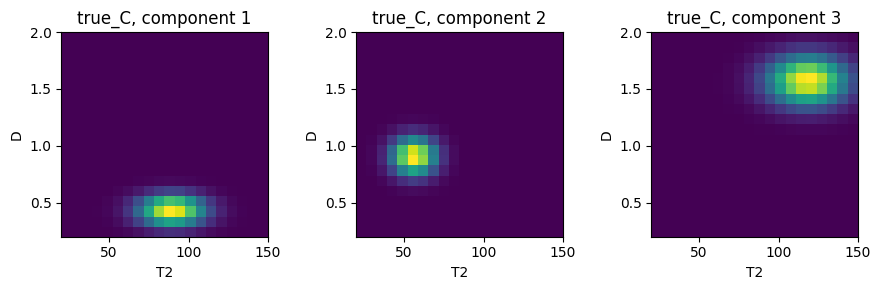

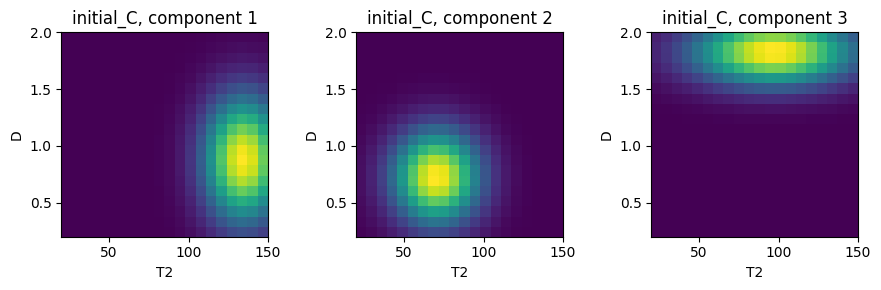

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [299.36084844 296.38478696 289.08154688 298.31757471 310.09086569
 287.08208365 302.01815591 279.60670198 289.96830436 298.9505419
 295.15375559 292.26480477 288.72873282 276.27978363 293.31081569
 283.53481893 302.69638597 299.42786521 282.86925121 288.11977656
 286.5513976  294.46819507 291.86313009 289.62172371 282.70949432
 280.41586565 281.34978699 279.12280384 283.34490159 292.44664591
 294.87348914 291.12454228 273.61687458 297.17317802 289.81176851
 295.84248586 285.79353771 300.8203187  275.75519581 268.36366168
 292.37031127 300.79184293 291.25627022 295.5

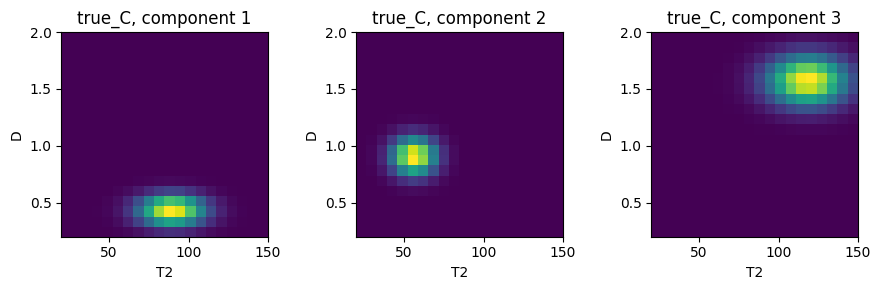

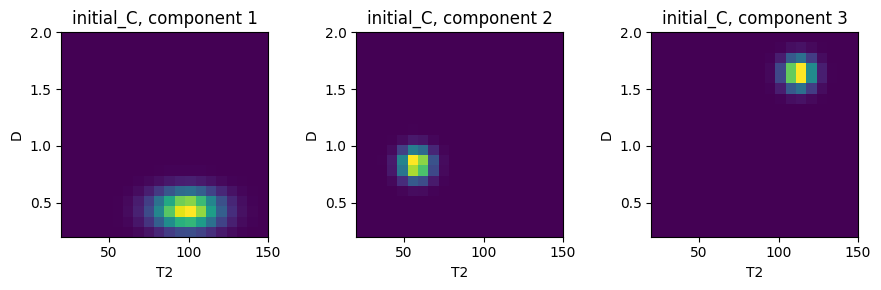

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [299.36084844 296.38478696 289.08154688 298.31757471 310.09086569
 287.08208365 302.01815591 279.60670198 289.96830436 298.9505419
 295.15375559 292.26480477 288.72873282 276.27978363 293.31081569
 283.53481893 302.69638597 299.42786521 282.86925121 288.11977656
 286.5513976  294.46819507 291.86313009 289.62172371 282.70949432
 280.41586565 281.34978699 279.12280384 283.34490159 292.44664591
 294.87348914 291.12454228 273.61687458 297.17317802 289.81176851
 295.84248586 285.79353771 300.8203187  275.75519581 268.36366168
 292.37031127 300.79184293 291.25627022 295.5

In [29]:
# Set intial conditions
C0=define_initial_C_NNLS(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)

# Set intial conditions
C0=define_initial_C_NNLS_mean(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)





iter 0: loss=2405.6456, fit_err=177196.447350, sigma2=36.000000
iter 100: loss=2391.1042, fit_err=176150.427881, sigma2=36.000000
iter 200: loss=2391.1042, fit_err=176150.427854, sigma2=36.000000


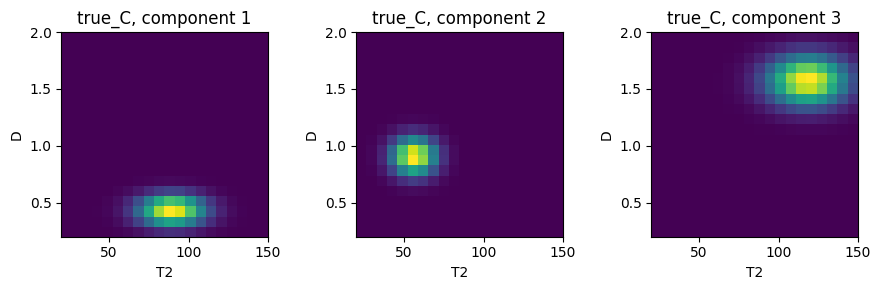

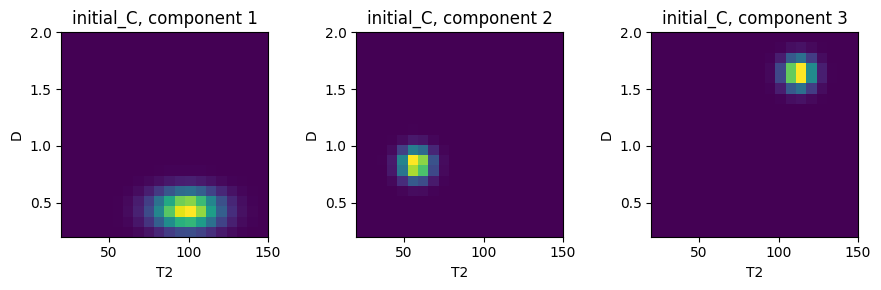

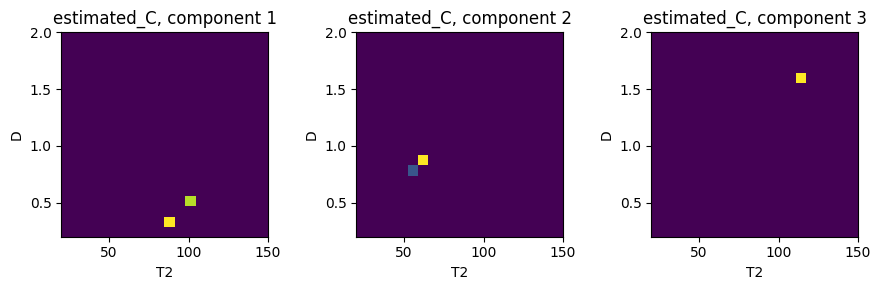

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.36173258 296.38886986 289.08681876 298.32013254 310.09223985
 287.08475079 302.01942573 279.60840217 289.97093336 298.94999741
 295.15316295 292.26430243 288.73150889 276.28410284 293.31411465
 283.53929334 302.69504985 299.43026263 282.87264073 288.12121023
 286.55637289 294.47104857 291.86457289 289.62250827 282.7161282
 280.4222001  281.34833214 279.13013139 283.34645485 292.45170054
 294.87787406 291.12895421 273.6251313  297.17715124 289.81695591
 295.84323767 285.79864331 300.81845437 275.75889337 268.36982711
 292.36919018 300.79505573 291.25991119 295

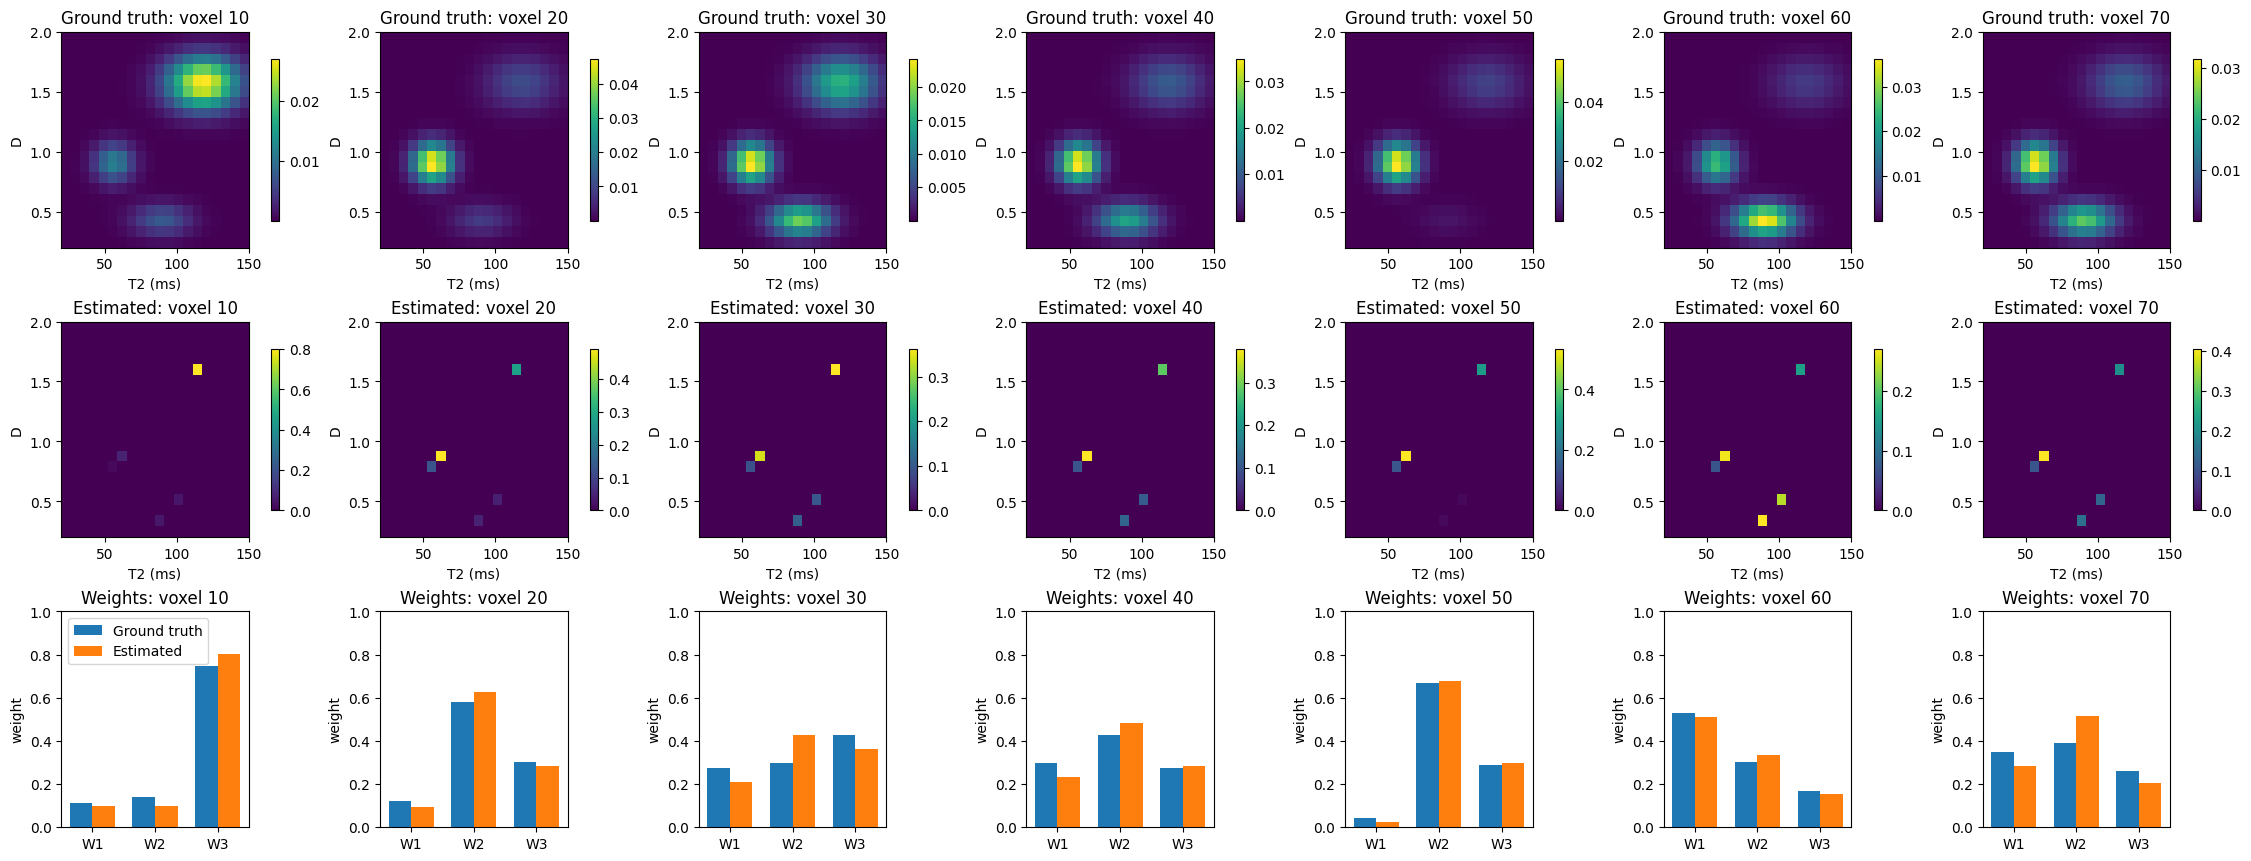

In [30]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # IDEALLY WE WANT TO NOT HAVE THIS, OR HAVE THE MODEL FAIRLY INSENSITIVE TO THE NOISE LEVEL BEING A LITTLE WRONG
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here

        c_sparsity=0.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=100,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)


Maria's note: Starting from the signal-averaged initialisation, the weights are recovered well. The spectra shrink to single spikes at roughly the right positions, so the peak locations are right but the shape and width are lost




Note this constrained optimisation of C (not C_small) has several constraint options:

- c_smoothness
Makes each canonical D–T2 spectrum spatially smooth across neighbouring grid cells.

- c_sparsity
Encourages each canonical spectrum to concentrate its mass into fewer grid locations.

- c_diversity
Discourages different canonical spectra from overlapping at the same D–T2 locations.

Other constraints already in the model (not on C):

- C simplex constraint
Each canonical spectrum is non-negative and sums to one.

- W simplex constraint
Each voxel’s component weights are non-negative and sum to one.

- M0 > 0
Voxel signal scale cannot be negative.

- lam
Ridge/Gaussian penalty on reduced C_small; shrinks its overall magnitude. Not physical D–T2 smoothness.

- Dirichlet alpha on W
A probabilistic prior favouring globally more pure (alpha < 1) or more even (alpha > 1) voxel weights.

- weight_entropy
Non-Dirichlet alternative that encourages individual voxel weights to be sparse/dominant.

#### We can make C smoother with the smoothness option

iter 0: loss=2406.8850, fit_err=177186.085666, sigma2=36.000000
iter 1: loss=2395.2406, fit_err=176339.381206, sigma2=36.000000
iter 2: loss=2390.8462, fit_err=176012.856246, sigma2=36.000000
iter 3: loss=2388.9640, fit_err=175865.494472, sigma2=36.000000
iter 4: loss=2388.1871, fit_err=175806.510436, sigma2=36.000000
iter 5: loss=2387.8309, fit_err=175777.627901, sigma2=36.000000
iter 6: loss=2387.6175, fit_err=175759.836113, sigma2=36.000000
iter 7: loss=2387.4647, fit_err=175747.159501, sigma2=36.000000
iter 8: loss=2387.3455, fit_err=175737.196708, sigma2=36.000000
iter 9: loss=2387.2482, fit_err=175728.908816, sigma2=36.000000
iter 10: loss=2387.1671, fit_err=175722.064161, sigma2=36.000000
iter 11: loss=2387.0995, fit_err=175716.279086, sigma2=36.000000
iter 12: loss=2387.0423, fit_err=175711.290755, sigma2=36.000000
iter 13: loss=2386.9941, fit_err=175707.010102, sigma2=36.000000
iter 14: loss=2386.9532, fit_err=175703.302649, sigma2=36.000000
iter 15: loss=2386.9184, fit_err=17

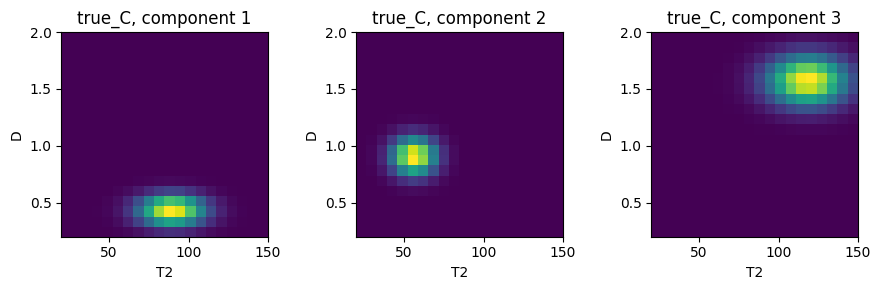

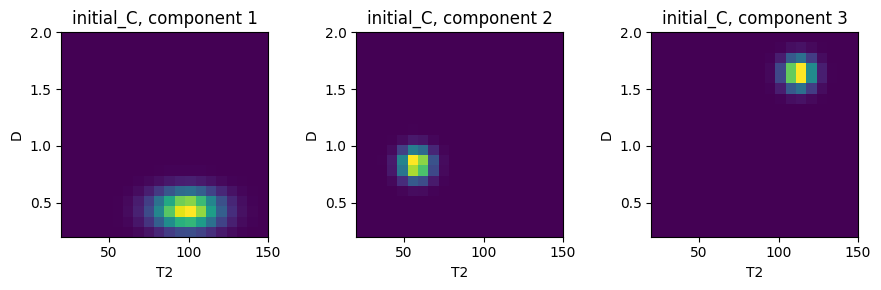

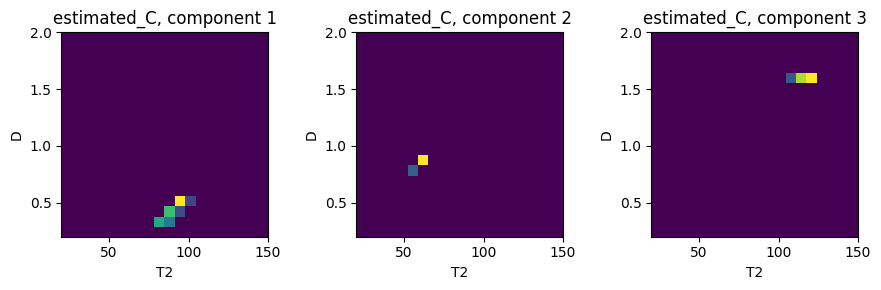

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.36117025 296.38842146 289.08623732 298.31971417 310.09134826
 287.08354977 302.01918083 279.60790958 289.96988468 298.94949026
 295.15294661 292.26406291 288.73097514 276.28385847 293.31400971
 283.53895974 302.69493266 299.42974701 282.87205136 288.12096722
 286.55621338 294.47078655 291.86409318 289.62198344 282.71576628
 280.42163573 281.34805051 279.12969419 283.34593344 292.45136814
 294.87750237 291.12832439 273.62470568 297.17682415 289.81645925
 295.84298118 285.79817188 300.81805402 275.75783695 268.36933909
 292.36892658 300.79455    291.25979171 29

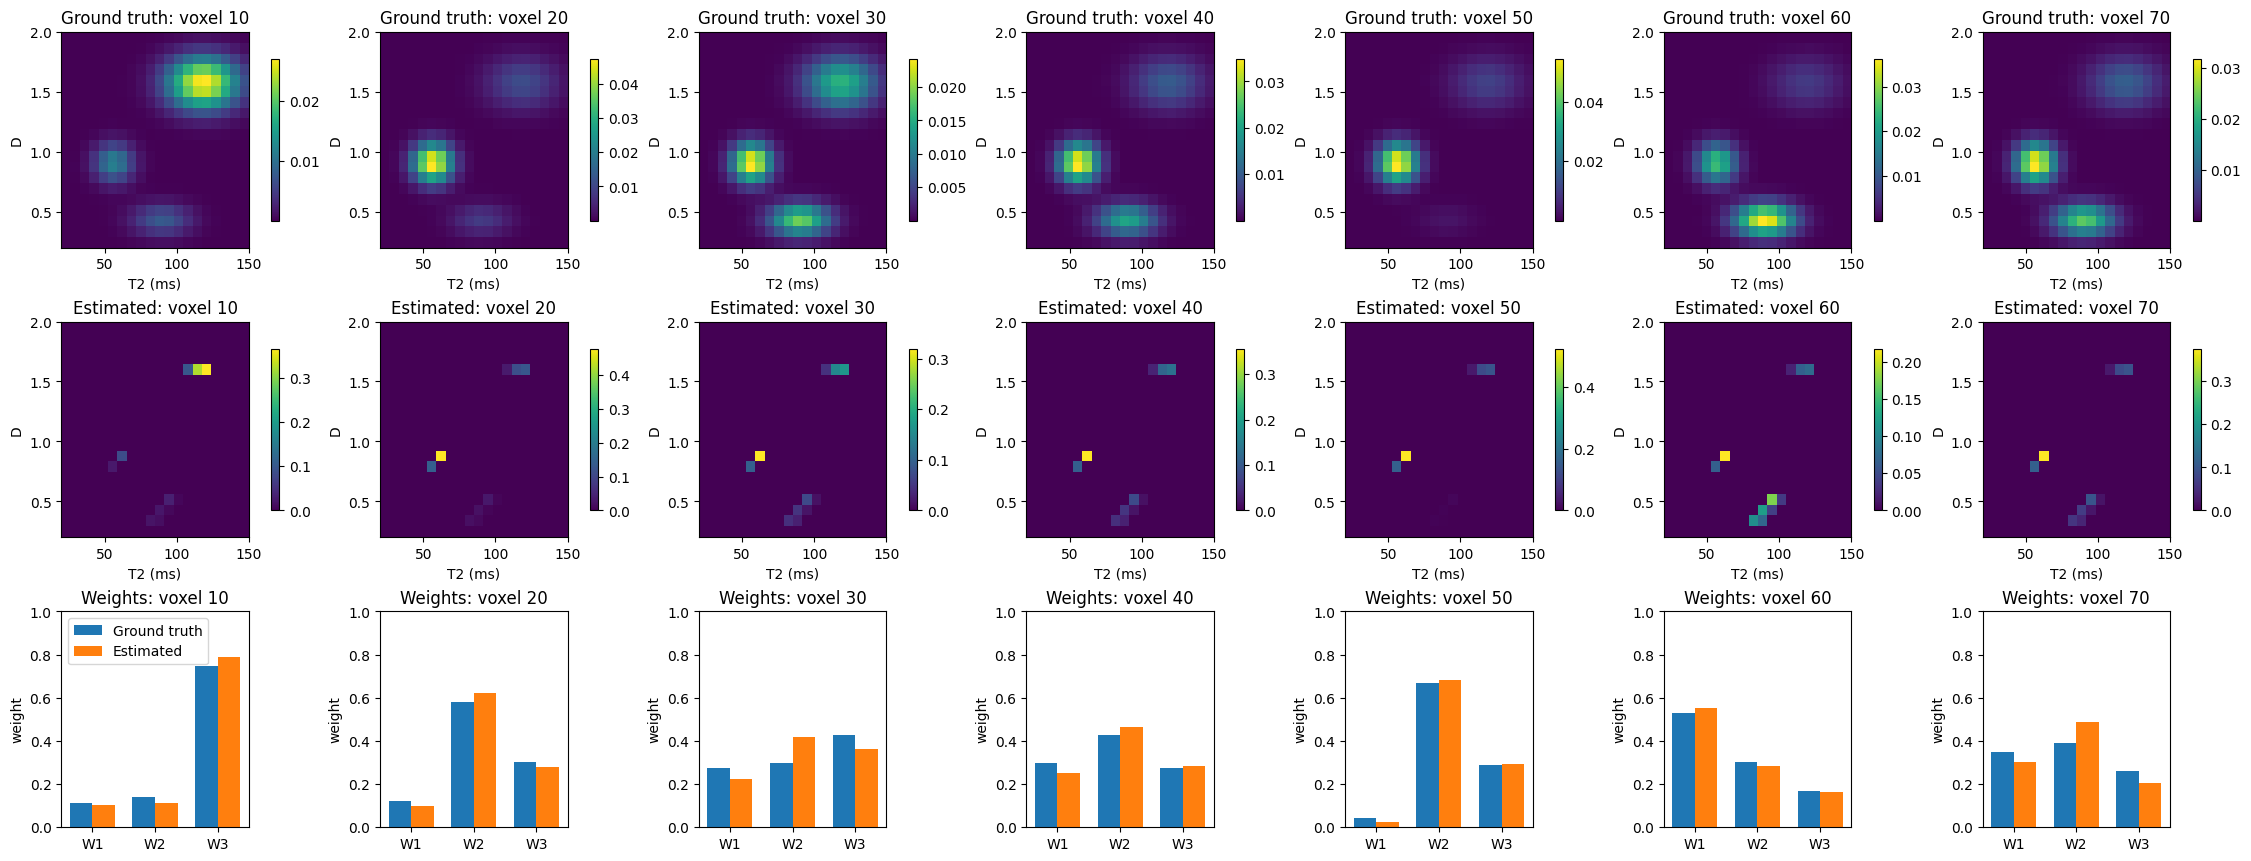

In [31]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here
        
        c_sparsity=0.0,            # make C sparse
        c_smoothness=1.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)


**Result:** At this strength smoothness has little visible effect. The spectra are still spiky and the weights are unchanged. A stronger value is needed to see an effect, most likely


#### or sparse

iter 0: loss=2411.2381, fit_err=177522.872230, sigma2=36.000000
iter 1: loss=2399.7608, fit_err=176701.376964, sigma2=36.000000
iter 2: loss=2398.9773, fit_err=176652.381720, sigma2=36.000000
iter 3: loss=2398.1533, fit_err=176608.115975, sigma2=36.000000
iter 4: loss=2397.7821, fit_err=176581.417882, sigma2=36.000000
iter 5: loss=2397.7792, fit_err=176581.212398, sigma2=36.000000
iter 6: loss=2397.7770, fit_err=176581.062789, sigma2=36.000000
iter 7: loss=2397.7754, fit_err=176580.953089, sigma2=36.000000
iter 8: loss=2397.7742, fit_err=176580.873592, sigma2=36.000000
iter 9: loss=2397.7733, fit_err=176580.816271, sigma2=36.000000
iter 10: loss=2397.7726, fit_err=176580.774211, sigma2=36.000000
iter 11: loss=2397.7721, fit_err=176580.744611, sigma2=36.000000
iter 12: loss=2397.7717, fit_err=176580.723378, sigma2=36.000000
iter 13: loss=2397.7715, fit_err=176580.708289, sigma2=36.000000
iter 14: loss=2397.7712, fit_err=176580.697944, sigma2=36.000000
iter 15: loss=2397.7711, fit_err=17

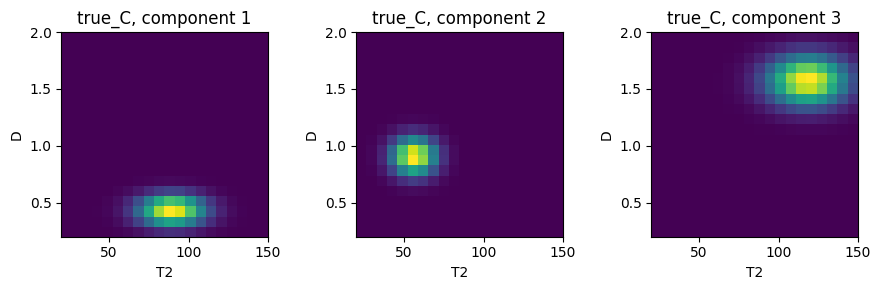

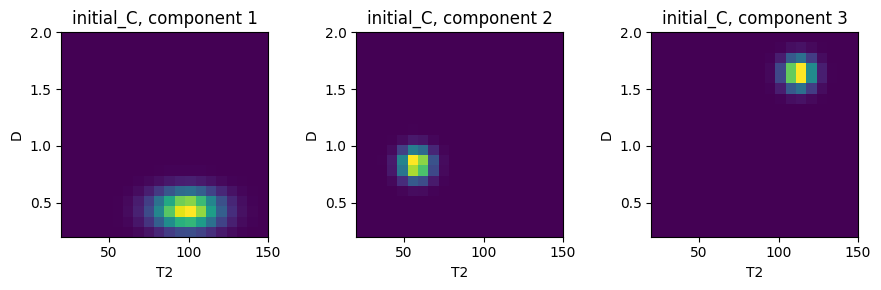

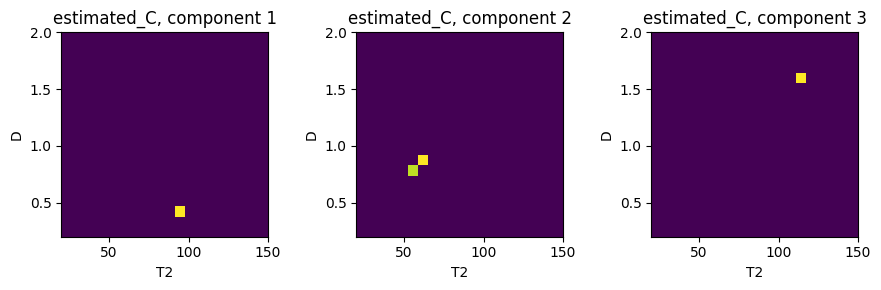

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.36155028 296.38892598 289.08688497 298.32087892 310.09170057
 287.08418926 302.01956916 279.60851672 289.9702241  298.95028608
 295.15320793 292.26424297 288.73134377 276.2839041  293.31414495
 283.53904316 302.69536385 299.43000244 282.87246061 288.12134005
 286.55678    294.47098182 291.86446547 289.62211383 282.71612054
 280.42189267 281.34873615 279.12996662 283.34636971 292.45177779
 294.87767743 291.1287432  273.62517343 297.17743621 289.8166917
 295.84323827 285.79846407 300.81835623 275.75819016 268.36979784
 292.3692054  300.79504376 291.25985116 295

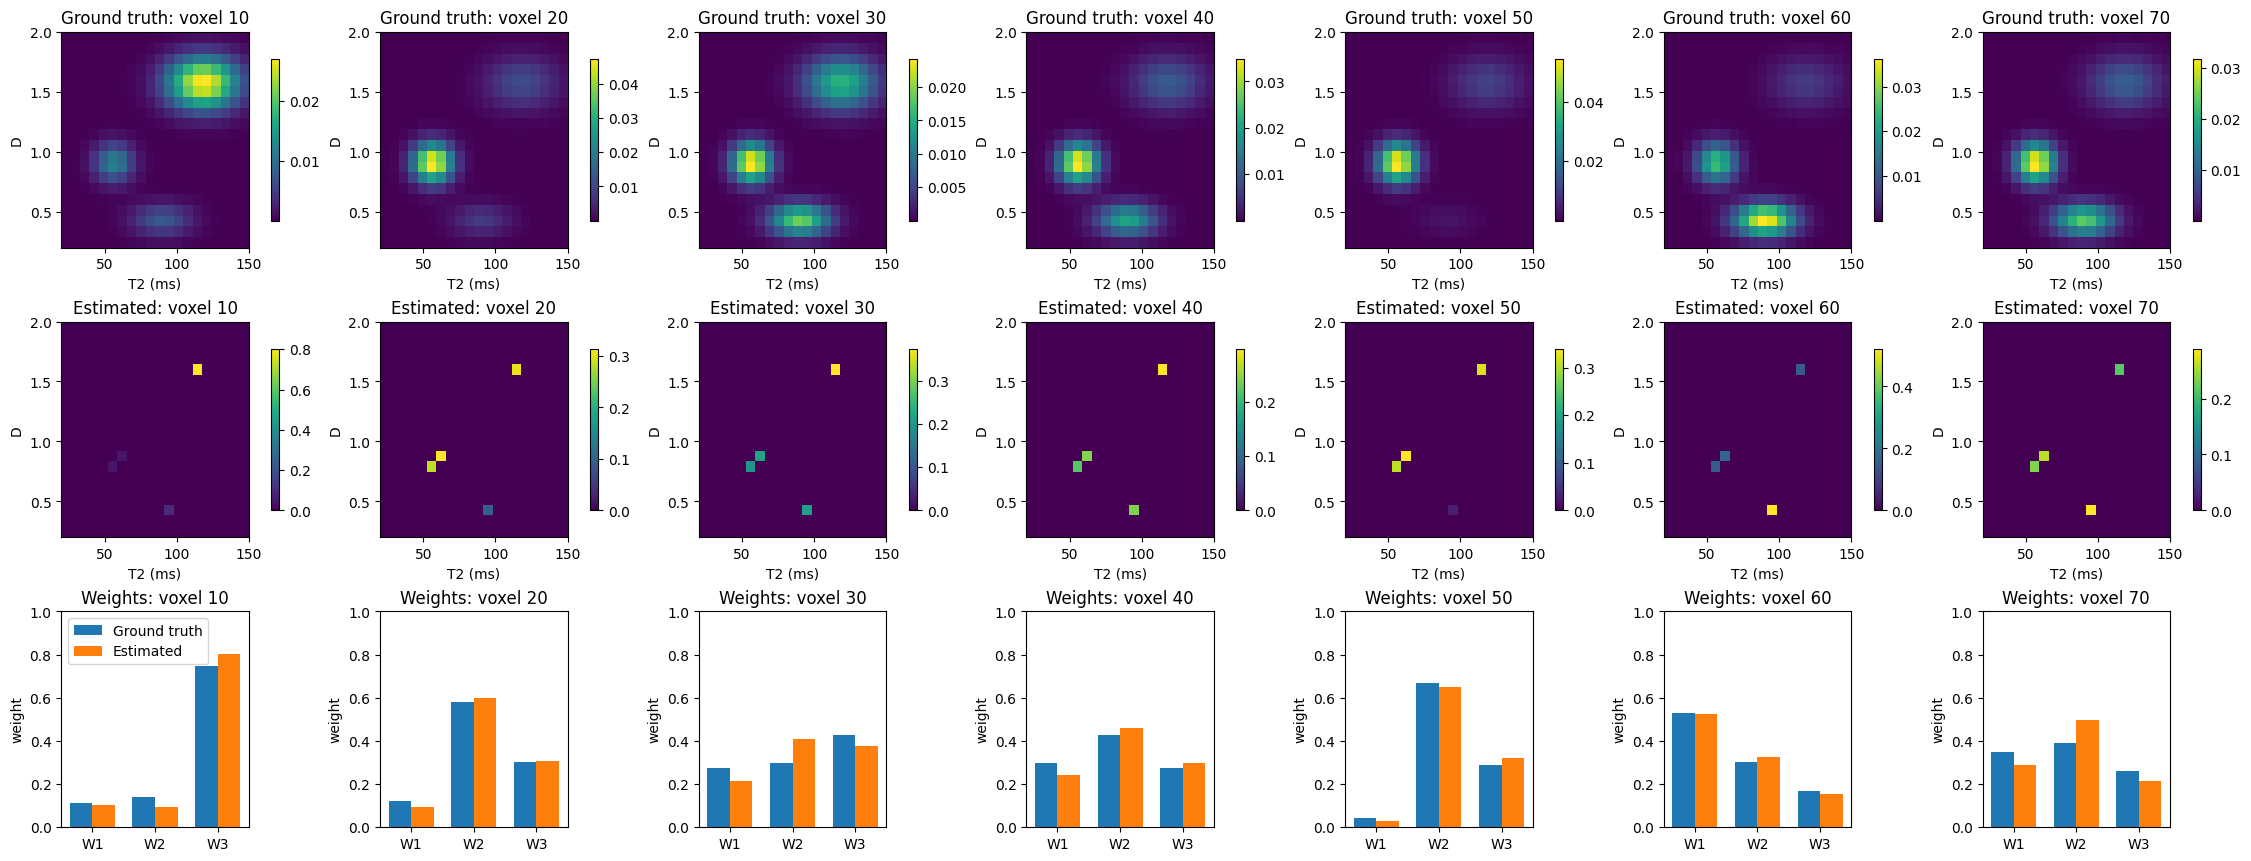

In [32]:


W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here

        c_sparsity=1.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)


#### This looks pretty good
Some notes:

We have simplex constraints on C and W.
C is shared across voxels making it heirarchical
Initialisation of C, M0 and W is good, giving a very good baseline.
You can make C smoother or sparser by adding additional constraints.

You do not need a Dirichlet prior on W for this to be described as a hierarchical Bayesian MAP model.
With:
alpha = 1.0
update_alpha_flag = False
The weight prior is effectively uniform over the simplex. That is a valid weak prior and is a good baseline for basic recovery.

You can set weight_entropy>0 to make W have a sparist-favouring prior. This might be helpful for harder optimisations.

m0_prior = M0_init
m0_prior_sigma = 0.15
<-- This sets M0 to be around an initial value which is estimated using a monoexpoential fit. sigma gives the spread around the initial value


Maria's note: Sparsity also has little effect, since the spectra are already spikes. The weights are unchanged


# 2. How about estimating C_small

iter 0: loss=2351.6858, fit_err=173311.341956, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2350.4971, fit_err=173227.544633, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2349.9668, fit_err=173189.366816, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2349.6042, fit_err=173163.258512, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2349.3533, fit_err=173145.197025, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2349.1771, fit_err=173132.511203, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 6: loss=2349.0510, fit_err=173123.431672, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 7: loss=2348.9588, fit_err=173116.792094, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 8: loss=2348.8898, fit_err=173111.824801, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 9: loss=2348.8370, fit_err=173108.023631, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 10: loss=2348.7957, fit_err=173105.052633, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 11: 

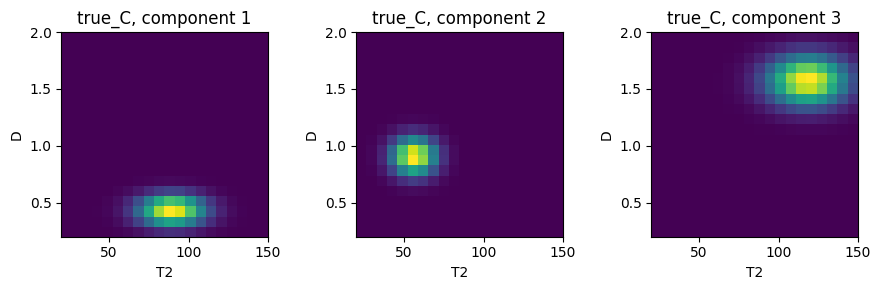

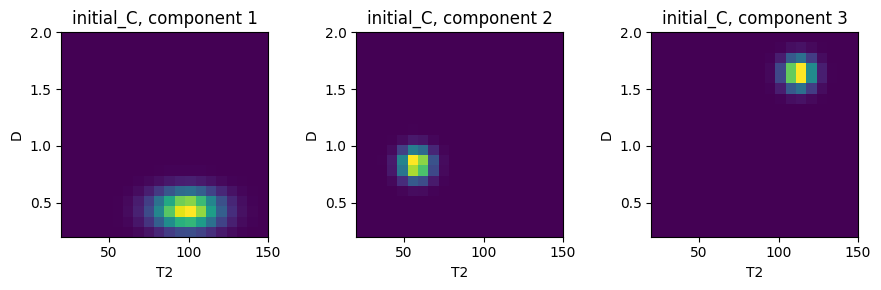

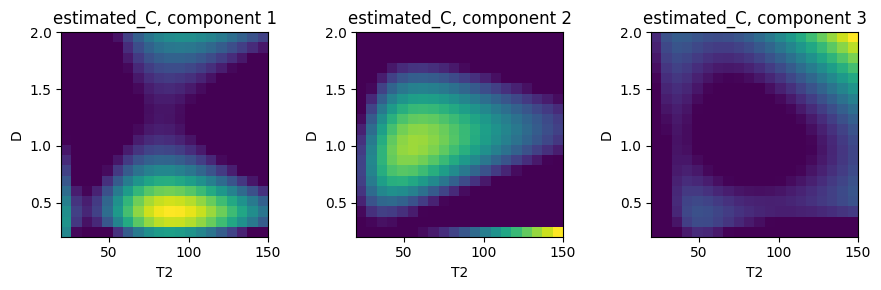

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.35928347 296.38614597 289.08463431 298.31914167 310.08987731
 287.08224363 302.01716147 279.60640526 289.9683094  298.94850522
 295.14989559 292.26172549 288.72910346 276.28106719 293.31128436
 283.53666052 302.69268177 299.42781595 282.86993728 288.1186387
 286.55421427 294.46815462 291.86225734 289.61968016 282.71381981
 280.42032282 281.34670064 279.1270579  283.3442756  292.44887617
 294.875025   291.1261487  273.62273012 297.17487672 289.81424954
 295.84089536 285.79573397 300.81492078 275.75611211 268.36744954
 292.3670323  300.79225992 291.25683093 295

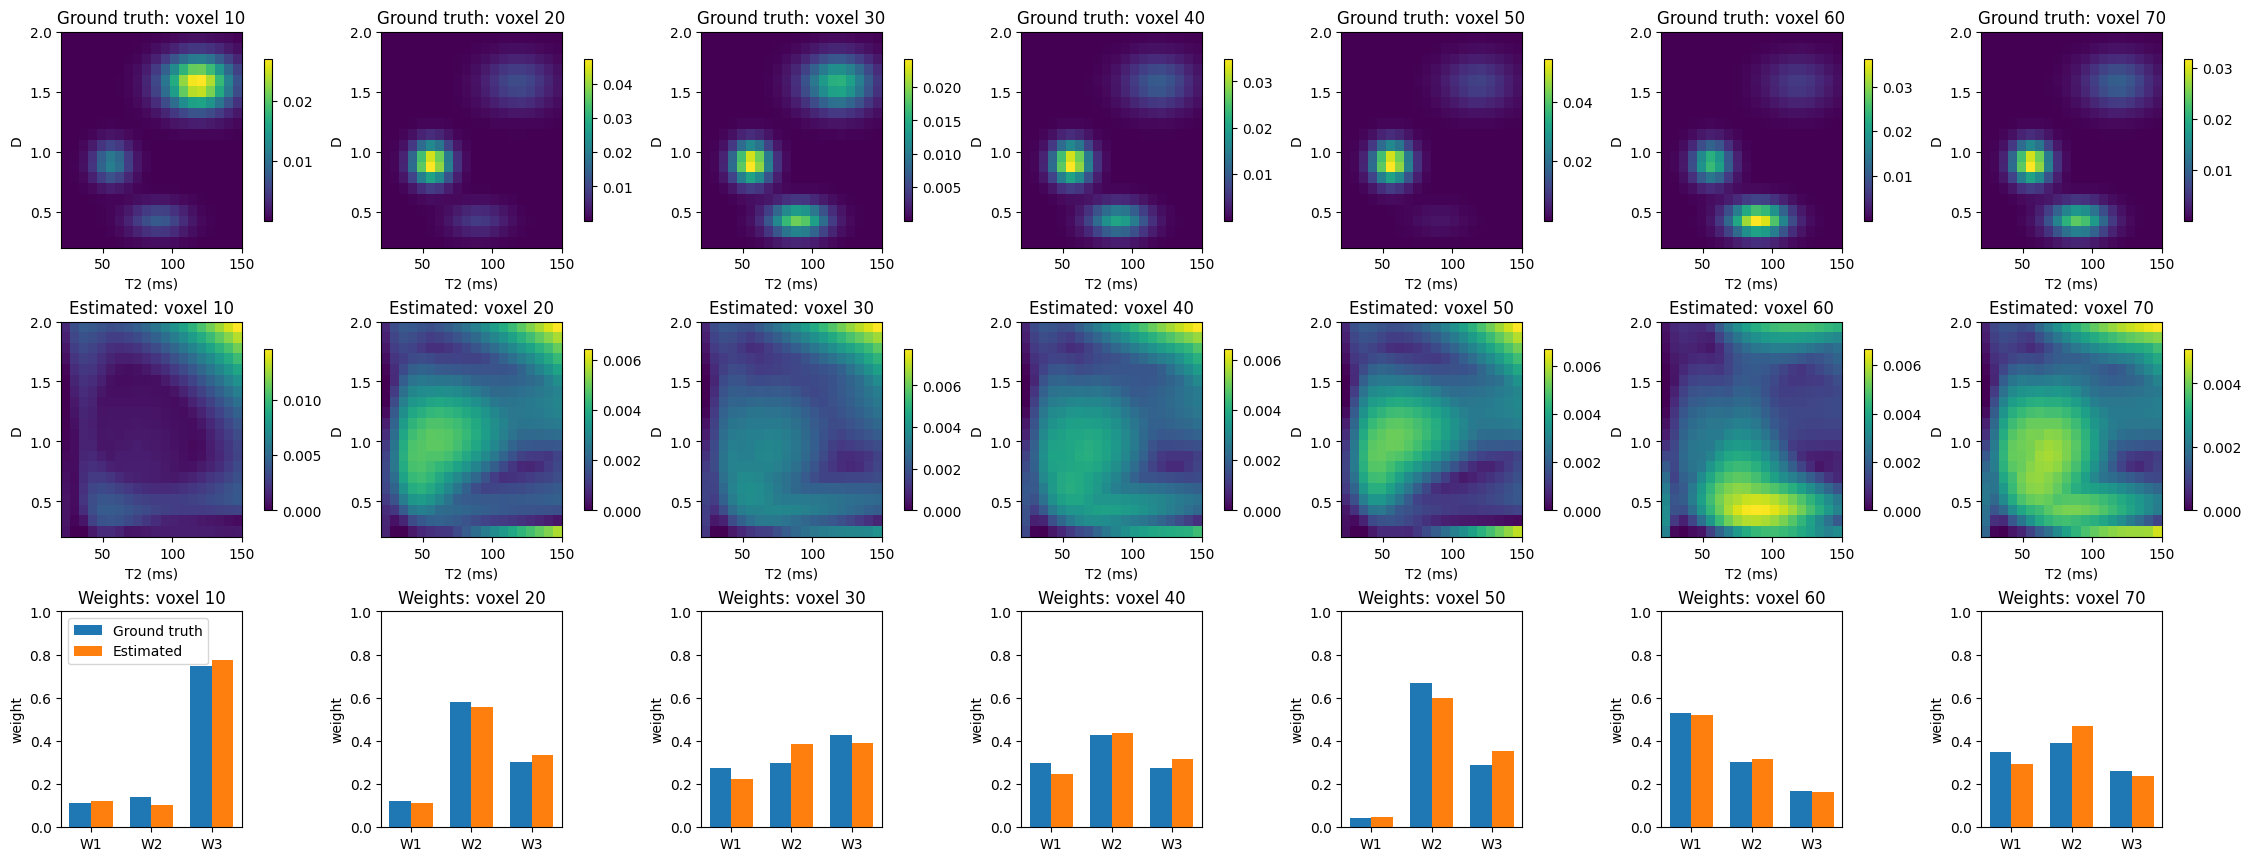

In [33]:
# CODE AT THE TOP HERE SO YOU CAN TRY DIFFERENT RANKS
R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


# Here we use run_optimisation not run_optimisation_constrained 
W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)

C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)




#### The spectra are a bit dodgy - can change R to adjust this, but the weights actually look quite good regardless. Could fit peaks afterwards?

Maria's note: Agreed. The C_small spectra are smooth but spread mass across the grid, while the weights stay good. Fitting peak positions afterwards looks like the right next step.


## 3. What happens if you set a Drichilet prior and try to estimate W and C_small?
Trying to recreate Maria's issues

iter 0: loss=2351.6858, fit_err=173311.341956, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2350.4971, fit_err=173227.544633, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2349.9668, fit_err=173189.366816, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2349.6042, fit_err=173163.258512, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2349.3533, fit_err=173145.197025, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2330.9921, fit_err=173132.511203, sigma2=36.000000, lam=0.0000, alpha=1.9439
iter 6: loss=2328.2072, fit_err=173132.033781, sigma2=36.000000, lam=0.0000, alpha=2.0586
iter 7: loss=2326.2737, fit_err=173119.375188, sigma2=36.000000, lam=0.0000, alpha=2.1318
iter 8: loss=2324.6138, fit_err=173114.170329, sigma2=36.000000, lam=0.0000, alpha=2.1985
iter 9: loss=2323.1593, fit_err=173114.758735, sigma2=36.000000, lam=0.0000, alpha=2.2606
iter 10: loss=2321.8625, fit_err=173119.009483, sigma2=36.000000, lam=0.0000, alpha=2.3186
iter 11: 

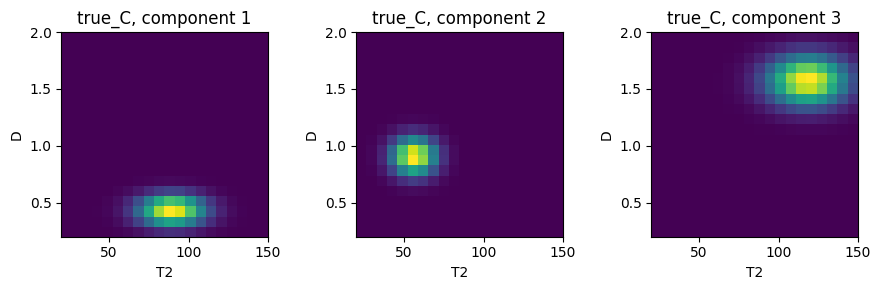

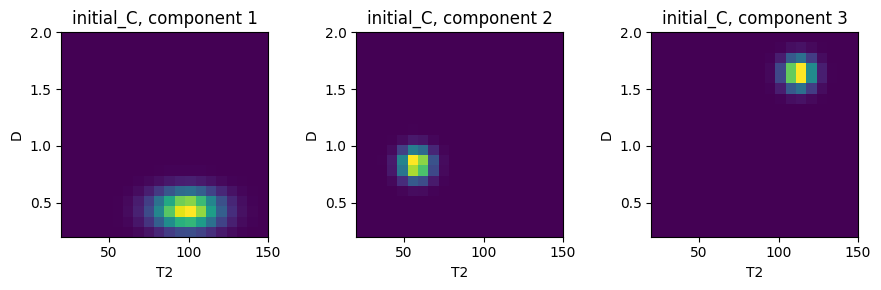

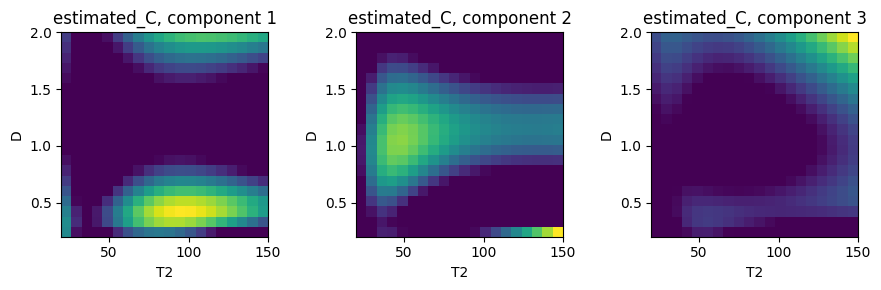

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.3593489  296.38602561 289.08440831 298.31913025 310.08983969
 287.08179237 302.01712362 279.60621874 289.96812482 298.94811617
 295.15045219 292.26205375 288.72907754 276.28158906 293.31165423
 283.5369257  302.69259389 299.42784193 282.8697103  288.1187051
 286.55404865 294.46817262 291.8622904  289.62004656 282.71382252
 280.42041425 281.34631928 279.12718204 283.34425579 292.44889853
 294.8749686  291.1263031  273.62254771 297.17468435 289.81448859
 295.84123315 285.79590588 300.81546181 275.75580524 268.36749283
 292.36690945 300.79223417 291.25690832 295

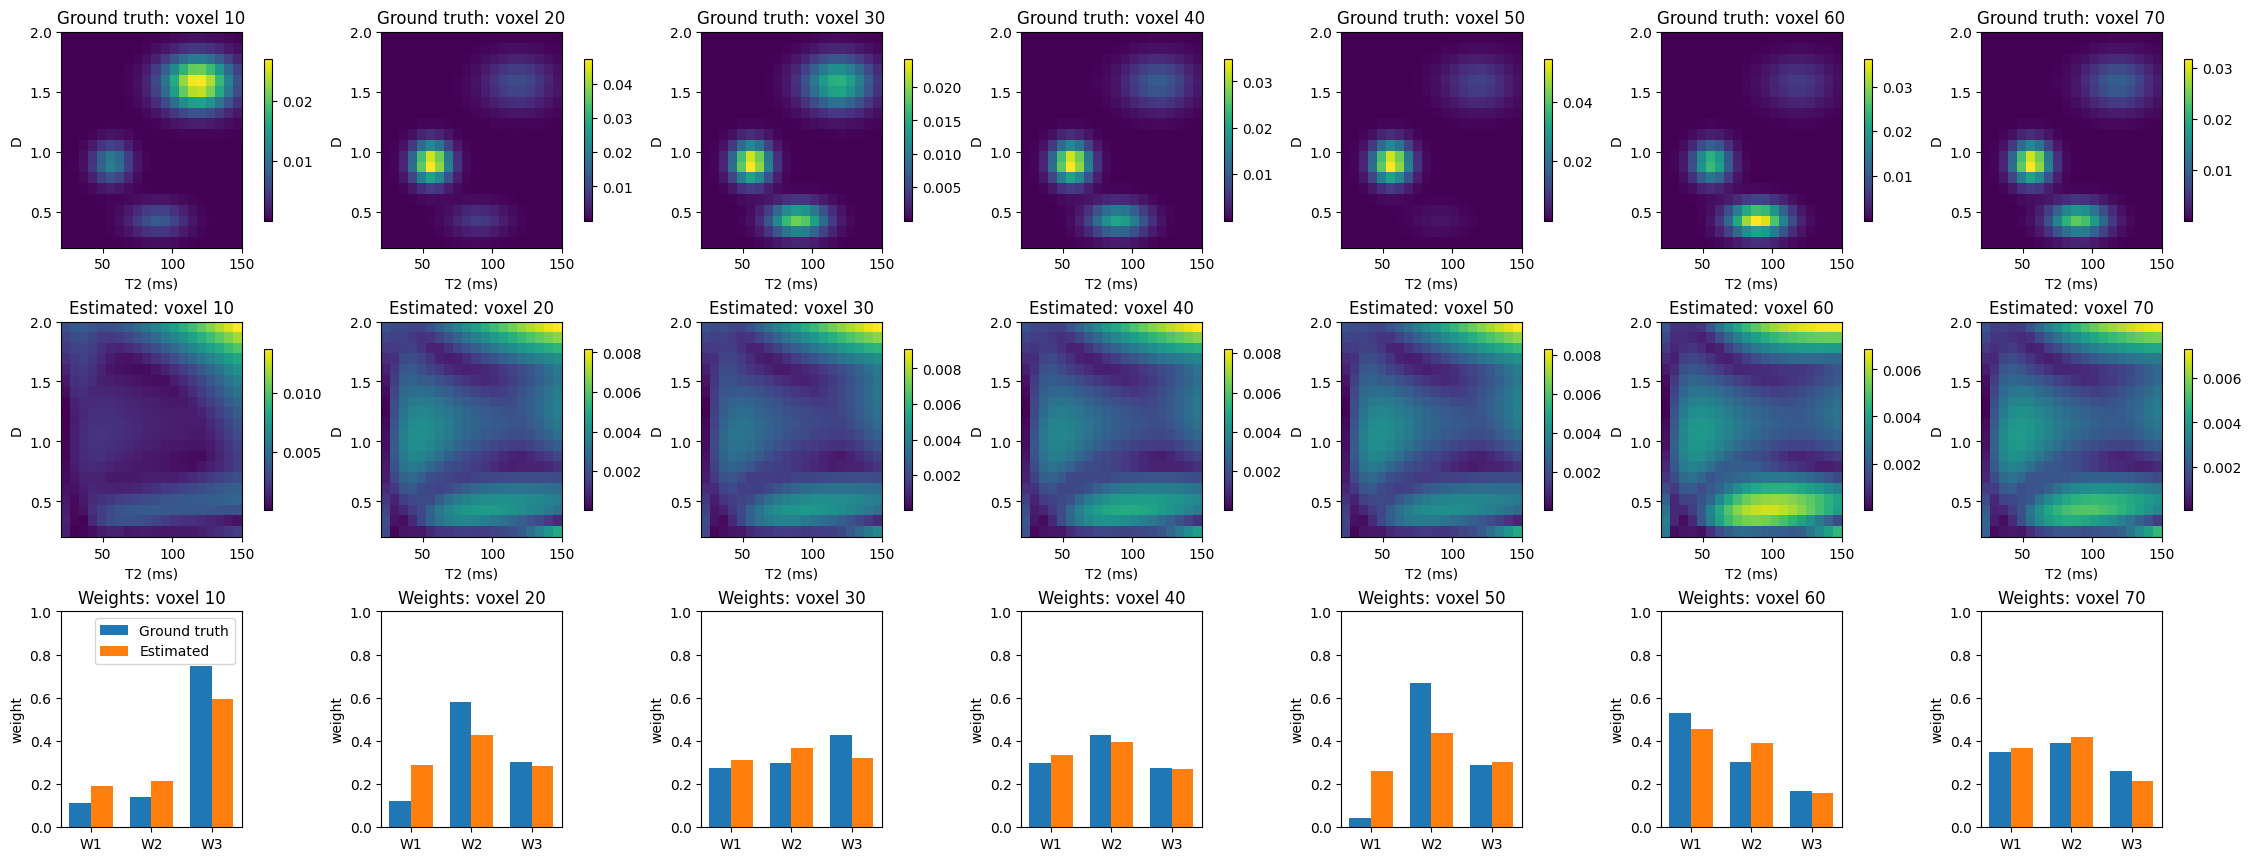

In [34]:
# 

R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

print("W MAE:", np.mean(np.abs(W_true - W_est)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est)))
print("C MAE:", np.mean(np.abs(C_true - C_est)))
print("alpha:", alpha_est)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])

print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)




#### This also seems to work - our spectra are blurred but we recover the wieghts well and we can postprocess the spectra. 

Note, the GT fibre fractions are not drawn from a Dirichlet distribution, do there is no "GT" alpha, but this optimisation uses Dirichlet as a regulariser.

Maria's note: A learned alpha below one favours sparse weights and above one favours even weights. Here alpha moves above one, which matches the fairly even true weights and the weights are still recovered well


### Let's try with a GT alpha to see if we can recover this also

Maria's note: This cell only runs the initialisation, to check the starting spectra. The data now has sparse weights drawn from a Dirichlet distribution with a known alpha. The next cell repeats this and runs the optimisation


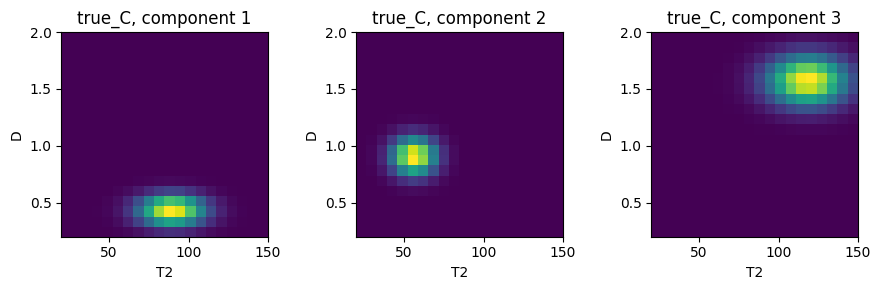

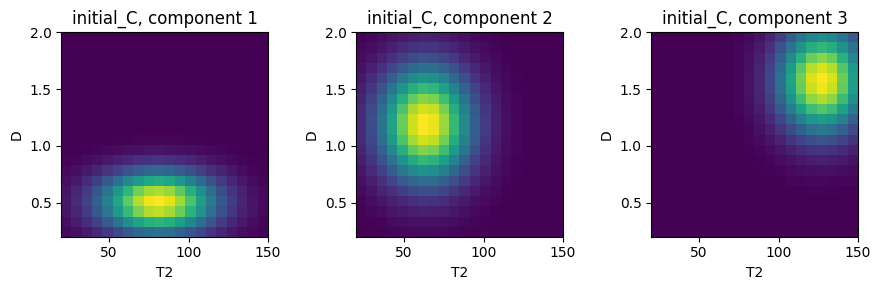

In [35]:
alpha_true = 0.5
rng_d = np.random.default_rng(0) #rng_d has to be defined again to get the same results!
W_true_dirichlet = rng_d.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_d)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])

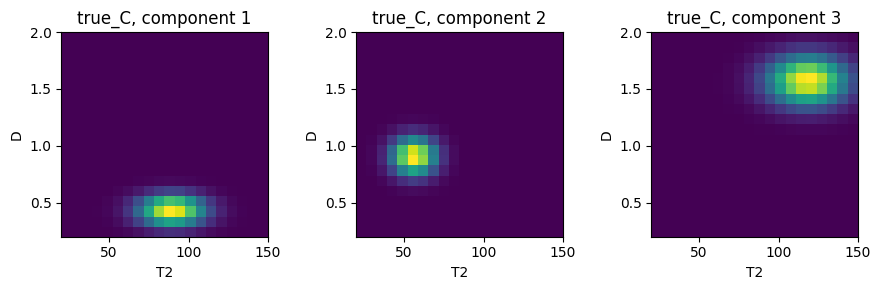

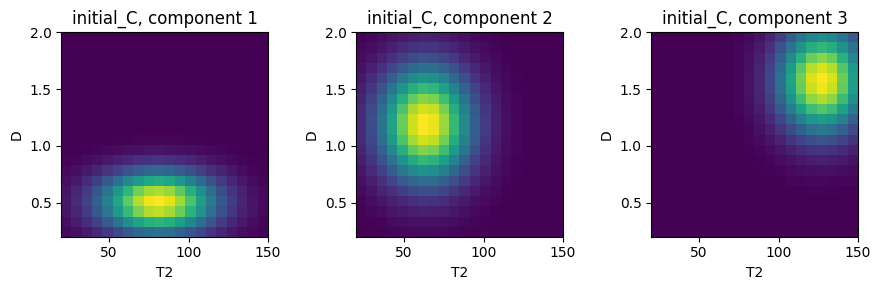

iter 0: loss=2711.7743, fit_err=199166.477825, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2565.2829, fit_err=188672.745805, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2539.4738, fit_err=186819.516924, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2529.4958, fit_err=186102.371241, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2524.7826, fit_err=185763.586140, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2496.9238, fit_err=185575.145242, sigma2=36.000000, lam=0.0000, alpha=0.5573
iter 6: loss=2493.5812, fit_err=185484.984565, sigma2=36.000000, lam=0.0000, alpha=0.5460
iter 7: loss=2491.5111, fit_err=185378.936564, sigma2=36.000000, lam=0.0000, alpha=0.5429
iter 8: loss=2489.9719, fit_err=185330.073488, sigma2=36.000000, lam=0.0000, alpha=0.5385
iter 9: loss=2488.9556, fit_err=185284.648925, sigma2=36.000000, lam=0.0000, alpha=0.5366
iter 10: loss=2488.2682, fit_err=185259.324748, sigma2=36.000000, lam=0.0000, alpha=0.5350
iter 11: 

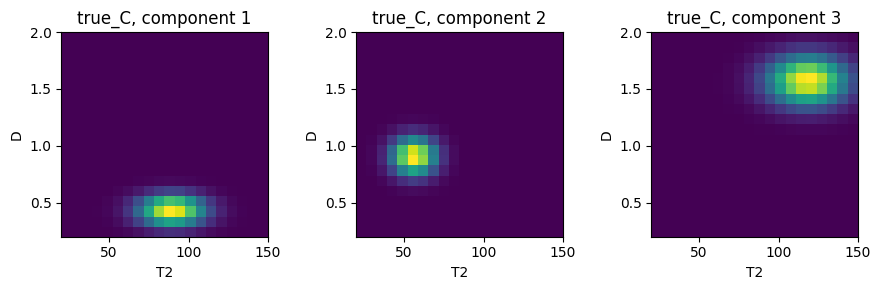

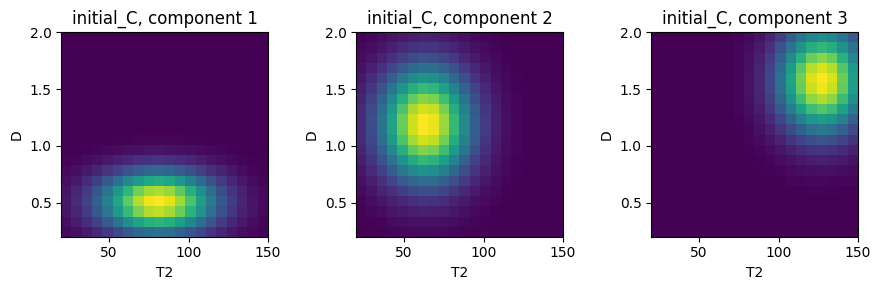

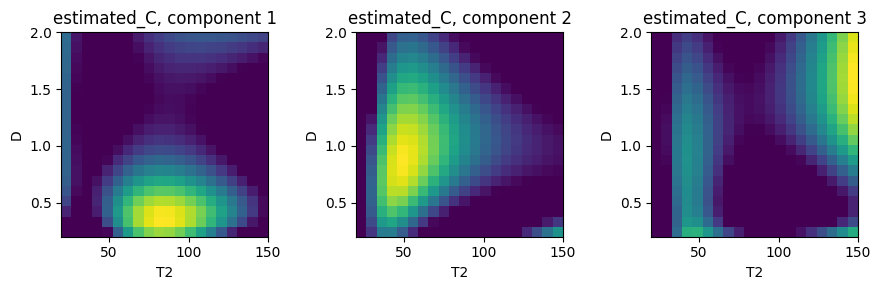

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [297.11998188 284.83504065 278.78362288 305.43542971 295.62985849
 298.22710269 290.50680241 296.86628261 278.71849105 290.78182535
 288.33771652 295.97013831 297.41779341 295.37661032 290.47003615
 307.04444719 302.06460101 281.38454521 302.22846099 297.27602638
 280.06378027 304.45599142 285.78830498 294.21150074 285.42932394
 288.98132981 297.03308274 293.38590586 295.47777879 293.57230212
 296.65220759 291.07233101 296.57836309 295.90468052 285.3965723
 302.48876154 295.39298747 288.82287905 300.47392006 298.86422556
 290.19392779 284.57945682 287.51989878 297

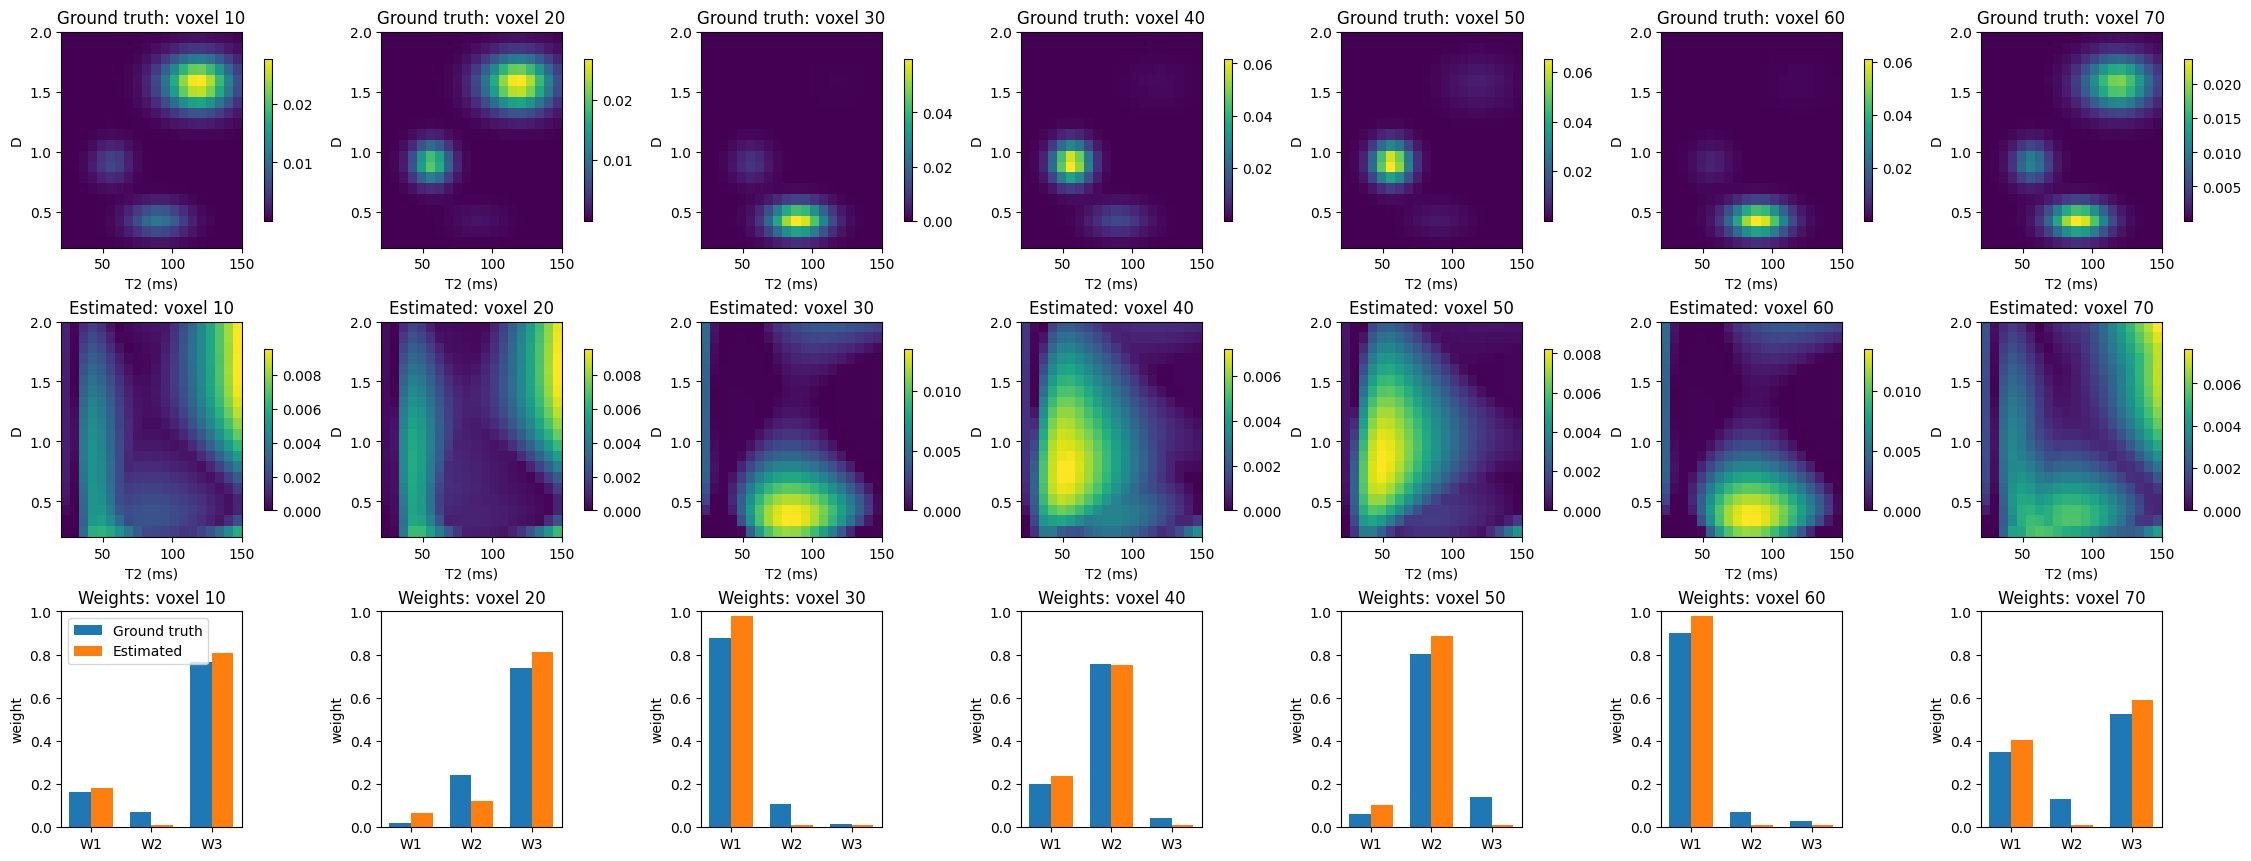

In [36]:
alpha_true = 0.5
rng_d = np.random.default_rng(0)
W_true_dirichlet = rng_d.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_d)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])


# ----------------


R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)


W_est_dirichlet, M0_est_dirichlet, Csmall_est_dirichlet, alpha_est_dirichlet, sigma2_est_dirichlet, lam_est_dirichlet, losses_dirichlet, fit_errs_dirichlet = (
    run_optimisation(
        Y_dirichlet, U,
        Csmall0_dirichlet, M0_init_dirichlet,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0_dirichlet,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init_dirichlet,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here
        
        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est_dirichlet = estimate_C(Vmat, s, Csmall_est_dirichlet)
C_est_dirichlet, W_est_dirichlet = order_components(C_true, C_est_dirichlet, W_est_dirichlet, K)

F_true = C_true @ W_true_dirichlet
F_est = C_est_dirichlet @ W_est_dirichlet

print("W MAE:", np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_dirichlet)))
print("C MAE:", np.mean(np.abs(C_true - C_est_dirichlet)))
print("alpha:", alpha_est_dirichlet)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])
show_canonical_spectra([('estimated_C', C_est_dirichlet)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est_dirichlet)


show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)






#### alpha isnt reconstructed perfectly but it does track with GT (e.g. estimated=0.3 when GT=0.1, and estimated = 5 when GT=10)

This also looks reasonable

Maria's note:  With the seeded data here, alpha is recovered close to the true value and the weights are good. The spectra are still blurred and one initial component sits too high in D


## 4. An alternative to alpha

Instead of using a Dirichlet prior, we could instead have an entropy prior on the weights. With lower entropy, more voxels have sparse weights, whilst still obeying the simplex constraint.

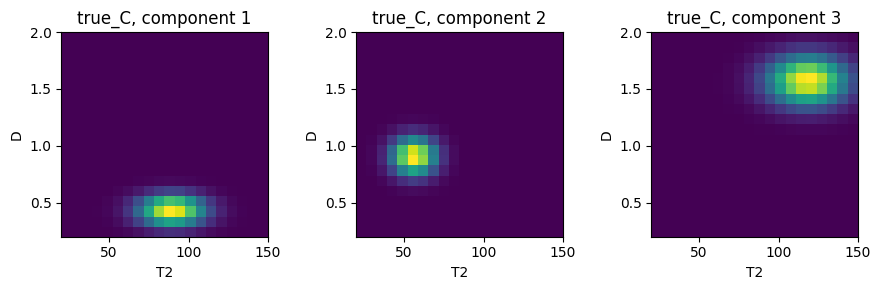

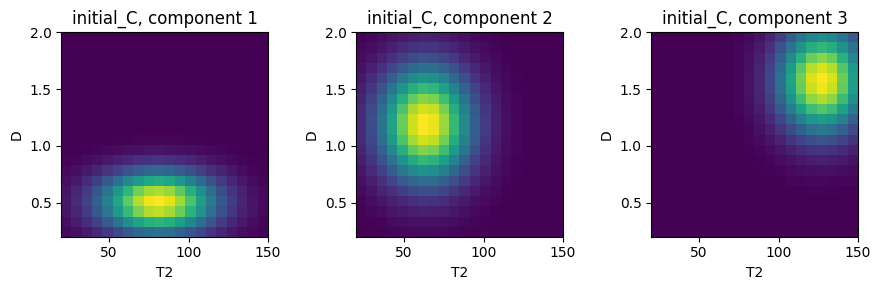

iter 0: loss=3234.3453, fit_err=202833.101069, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=3116.1375, fit_err=193515.305794, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=3088.0084, fit_err=191379.377957, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=3072.2876, fit_err=190393.543908, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=3061.9583, fit_err=189933.108729, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=3054.5589, fit_err=189735.390425, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 6: loss=3049.3356, fit_err=189620.931823, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 7: loss=3045.2661, fit_err=189575.621672, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 8: loss=3039.3616, fit_err=189280.834346, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 9: loss=3035.5536, fit_err=189204.078246, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 10: loss=3031.9310, fit_err=189168.688926, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 11: 

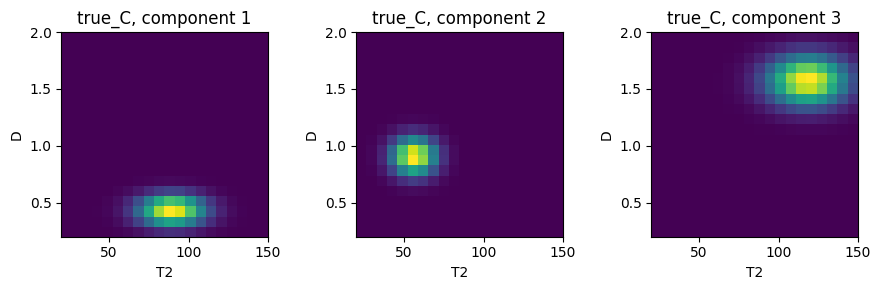

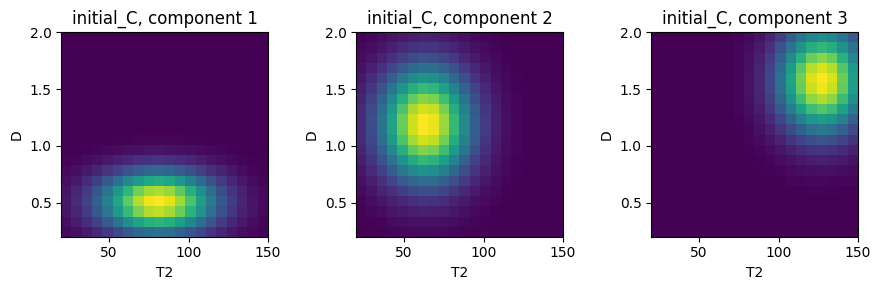

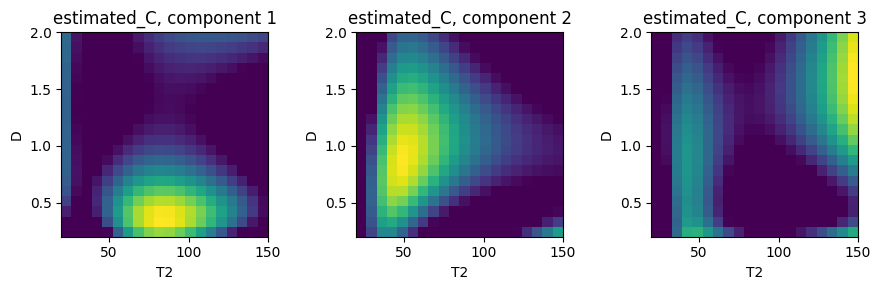

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [297.12351168 284.83192295 278.7859069  305.43996529 295.63010716
 298.22642086 290.50678553 296.87021953 278.72073929 290.78223274
 288.34177266 295.96983339 297.41915999 295.38057976 290.46817674
 307.04655454 302.06486333 281.38429787 302.22963138 297.27353637
 280.0612426  304.45651011 285.78652404 294.21125413 285.42994313
 288.98166555 297.03192453 293.38774961 295.47836962 293.57342183
 296.65463661 291.0704102  296.5801275  295.90510366 285.39482444
 302.48766317 295.39320165 288.82258328 300.47501685 298.86747387
 290.19425103 284.54430837 287.52011983 29

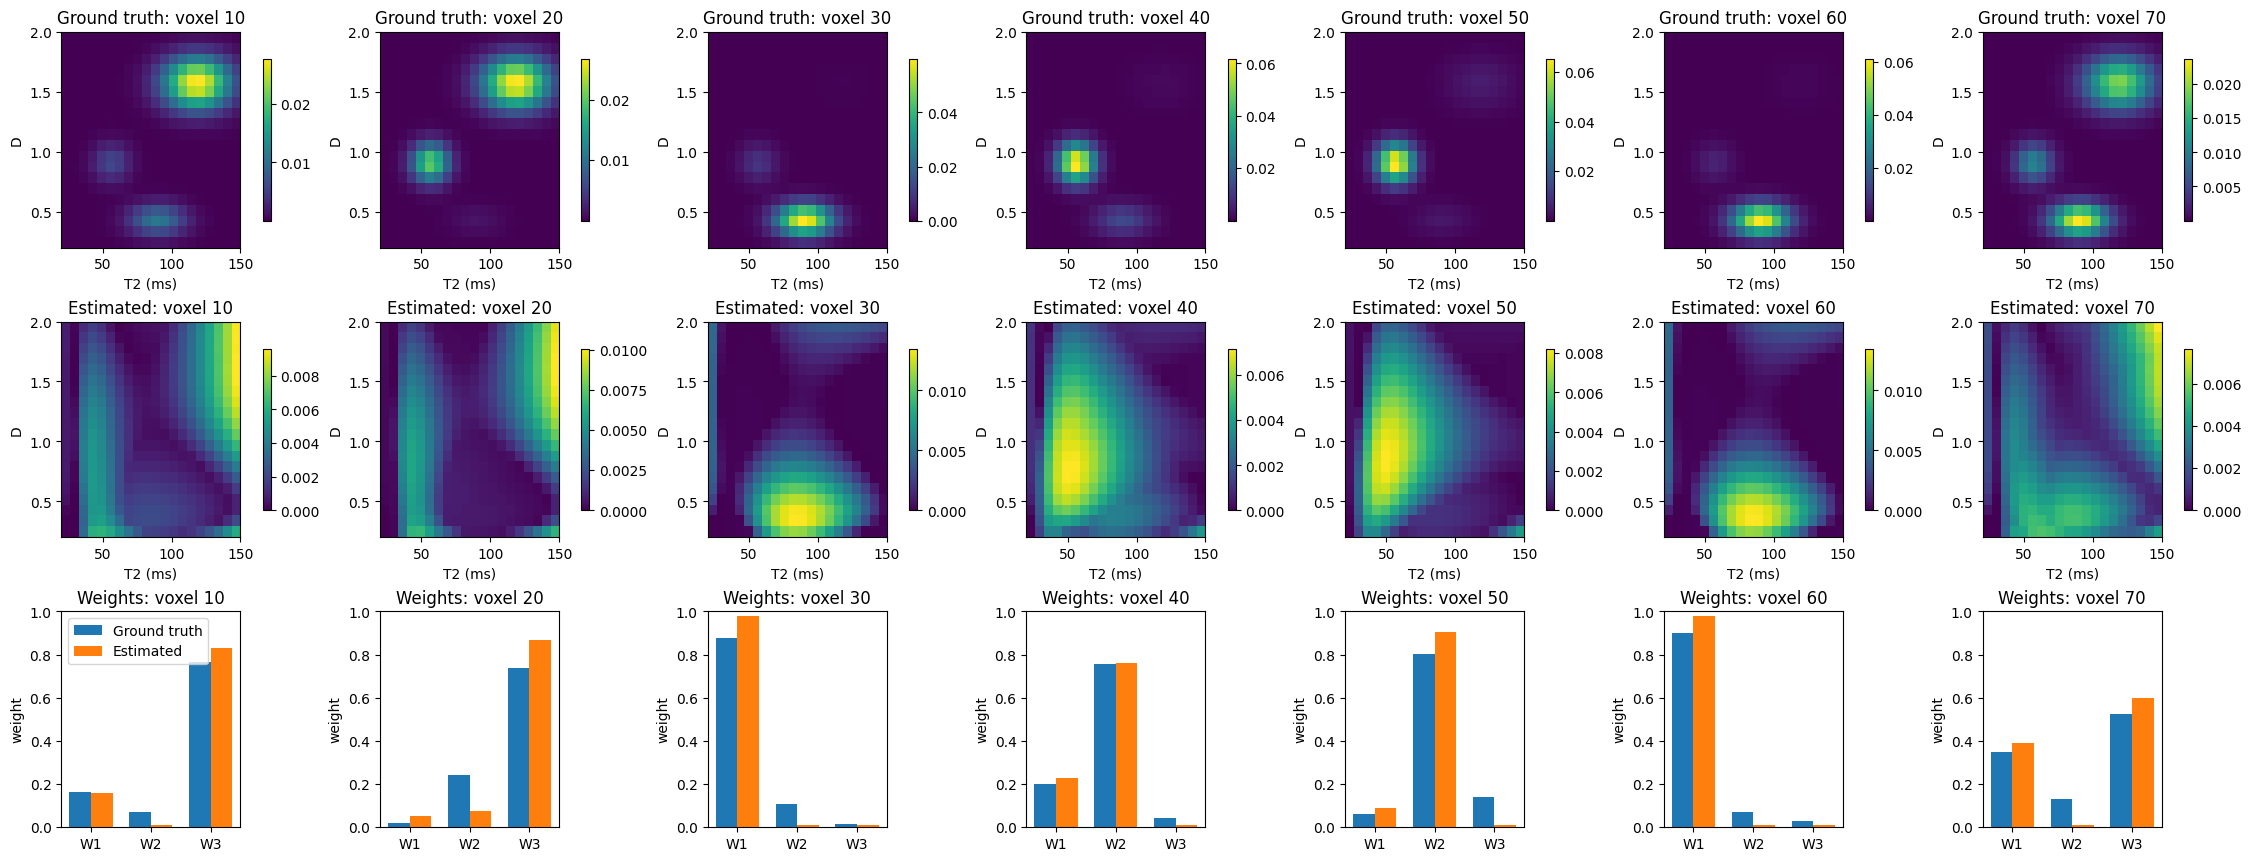

In [37]:
# Here initilise with Dirichlet-distributed weights with alpha<1 to make sparse wieghts, but optimise not assuming Dirichlet

alpha_true = 0.5
rng_d = np.random.default_rng(0)
W_true_dirichlet = rng_d.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_d)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])


# ----------------


R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)


W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y_dirichlet, U,
        Csmall0_dirichlet, M0_init_dirichlet,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0_dirichlet,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init_dirichlet,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=10.0,        

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true_dirichlet
F_est = C_est @ W_est

# print("W MAE:", np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
# print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_dirichlet)))
# print("C MAE:", np.mean(np.abs(C_true - C_est_dirichlet)))
# print("alpha:", alpha_est_dirichlet)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est, voxels_to_show)






#### This doesnt seem to make a big difference? the weights are well estimated with entropy=0. Leaving in as an option

Maria's note: This uses the same data as the Dirichlet run above, with an entropy penalty on the weights instead of a learned alpha. The entropy prior gives almost the same weights and spectra, so it doesn't clearly help. The seed comparison below agrees.


#### I added a Dirichlet vs entropy prior over several seeds
NNLS on each voxel, then average the spectra. Each seed gives new weights and noise.

Seed 0: true C (first row) vs initial C (second row), starting W MAE 0.090


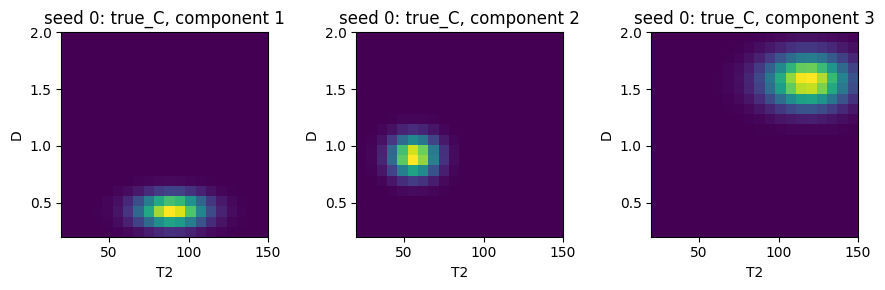

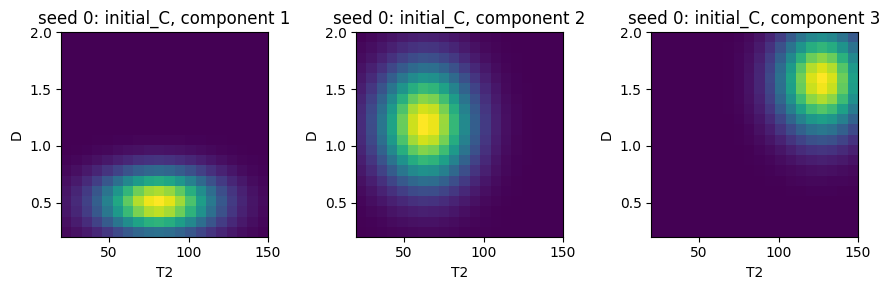



iter 0: loss=2711.7743, fit_err=199166.477825, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 0, dirichlet prior: estimated C, W MAE 0.052


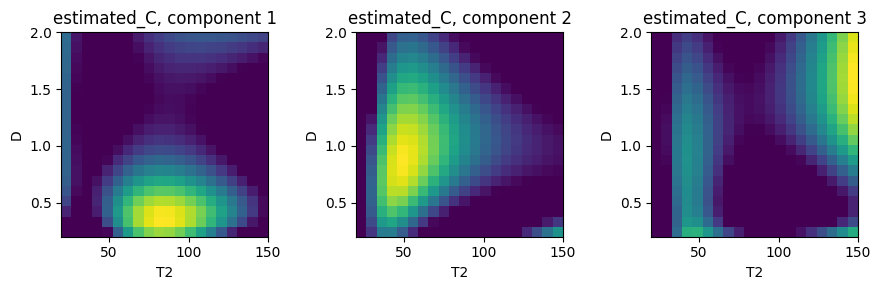

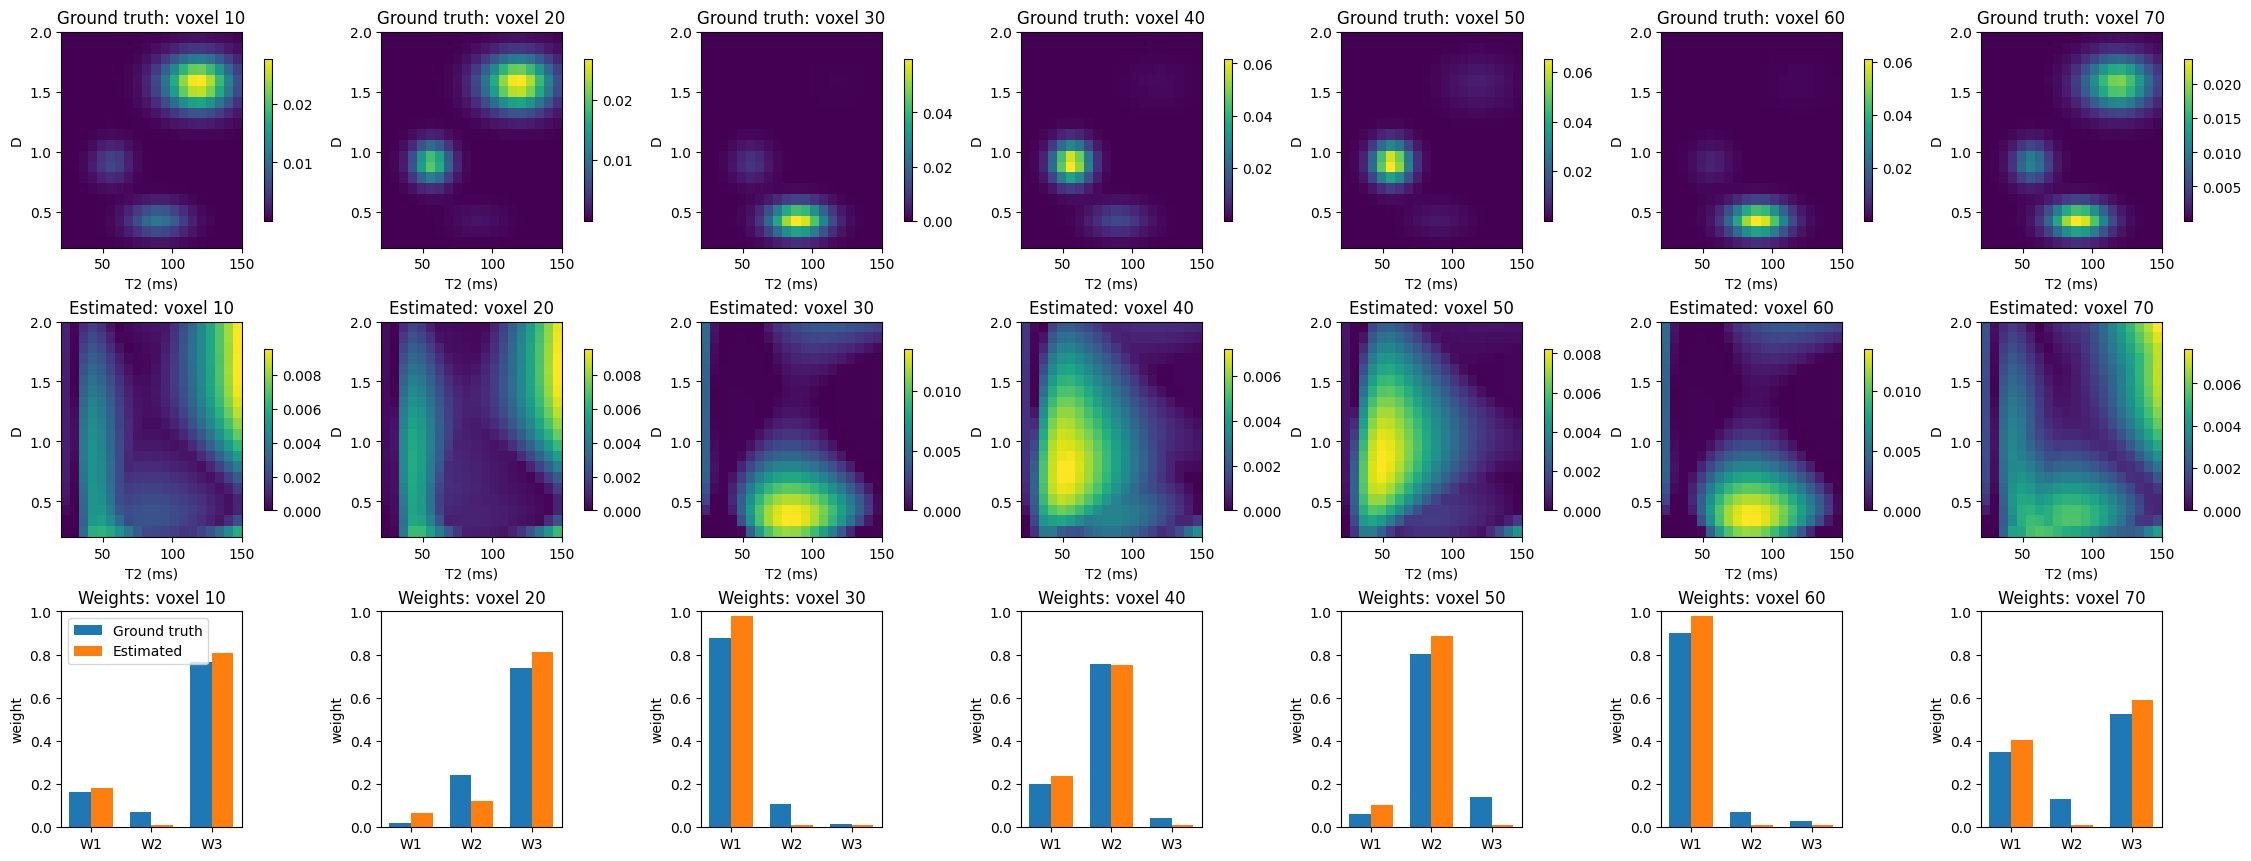

iter 0: loss=3234.3453, fit_err=202833.101069, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 0, entropy prior: estimated C, W MAE 0.059


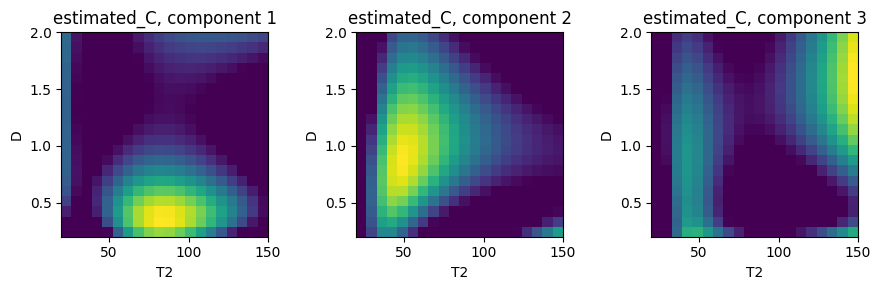

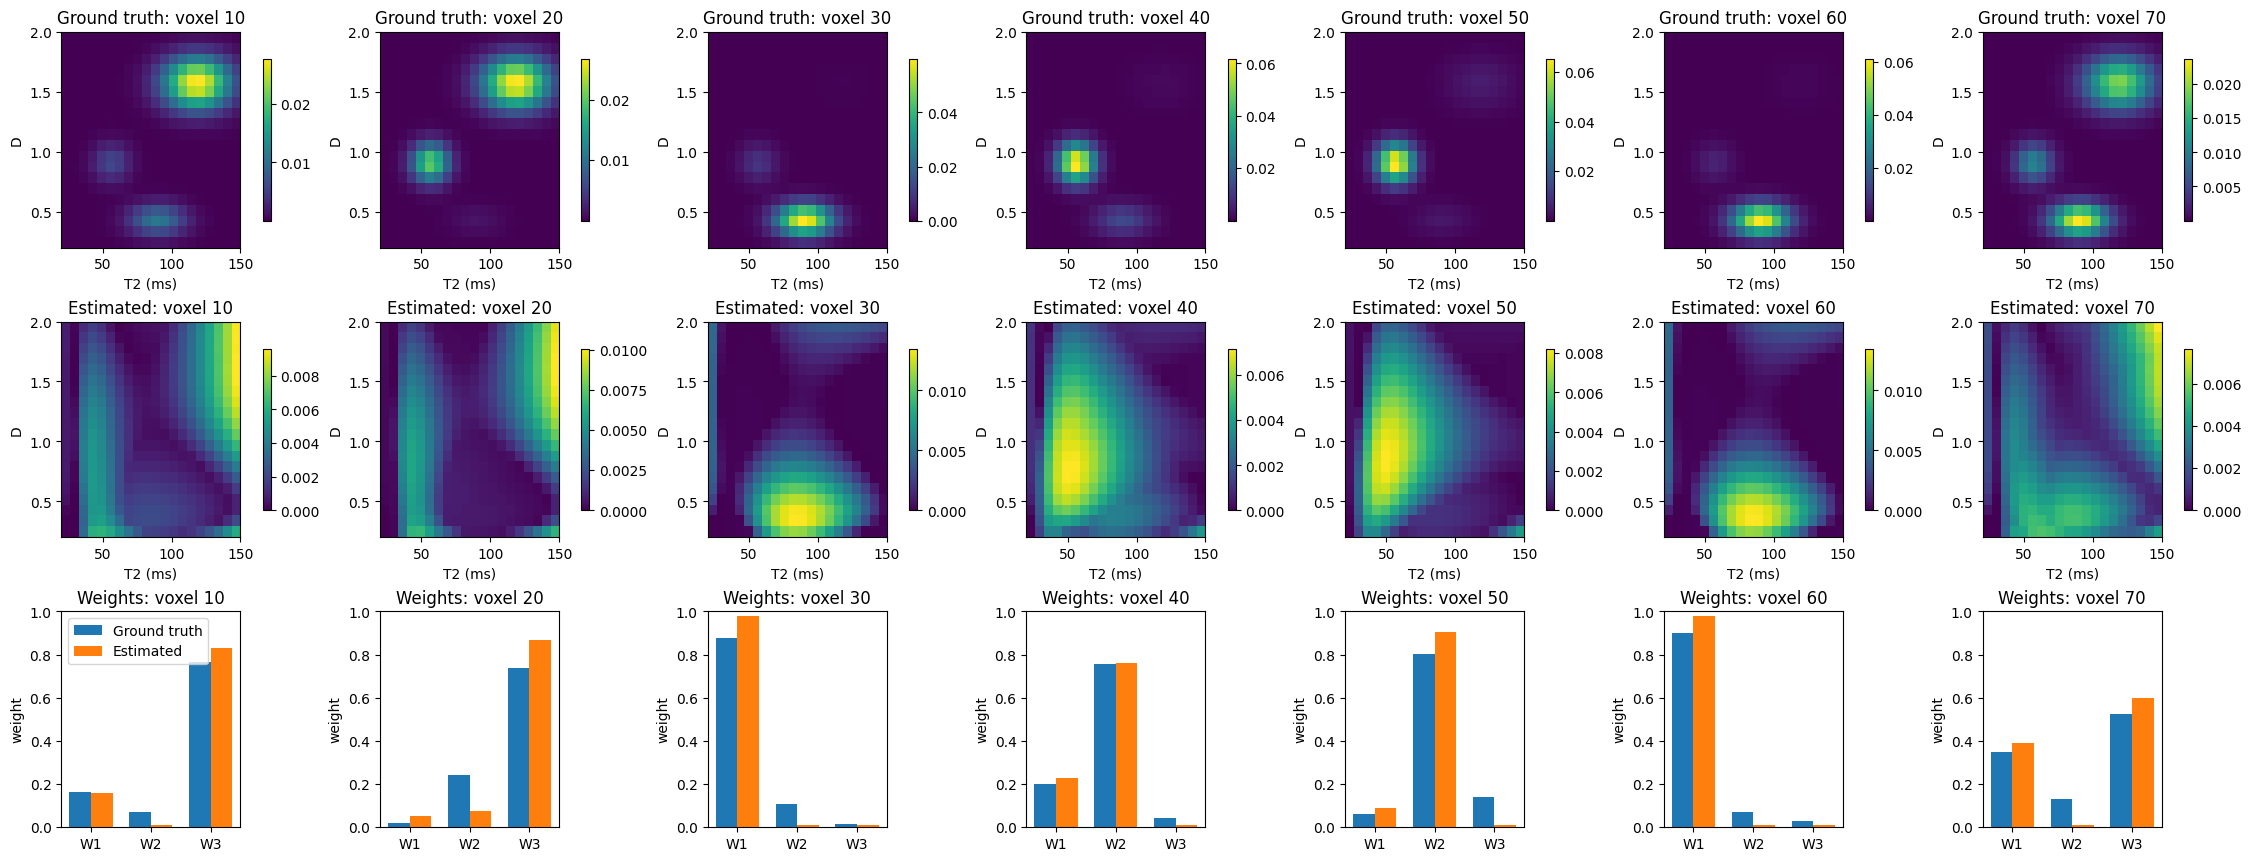

Seed 1: true C (first row) vs initial C (second row), starting W MAE 0.185


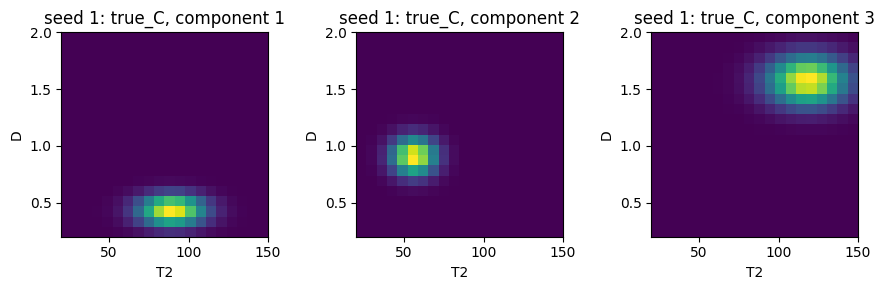

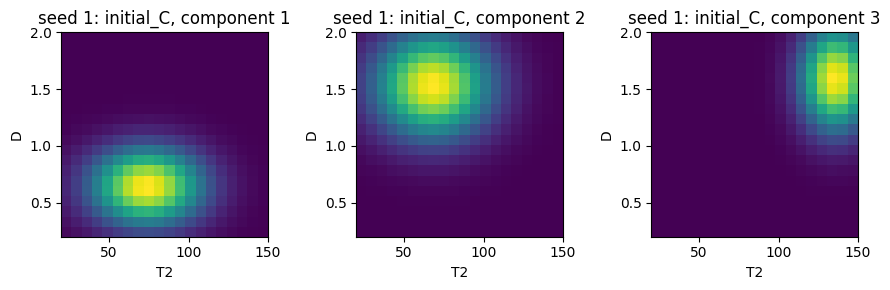



iter 0: loss=3591.1205, fit_err=262289.425974, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 1, dirichlet prior: estimated C, W MAE 0.135


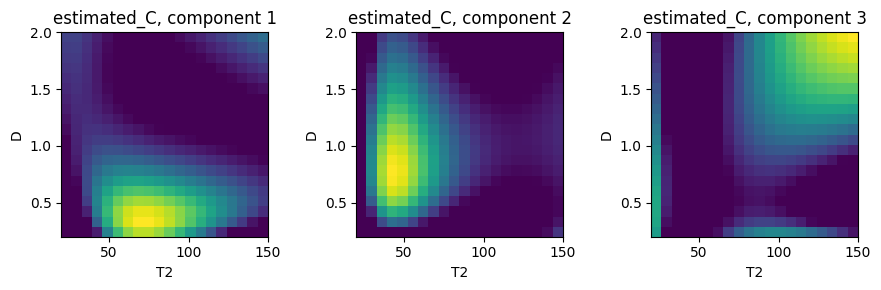

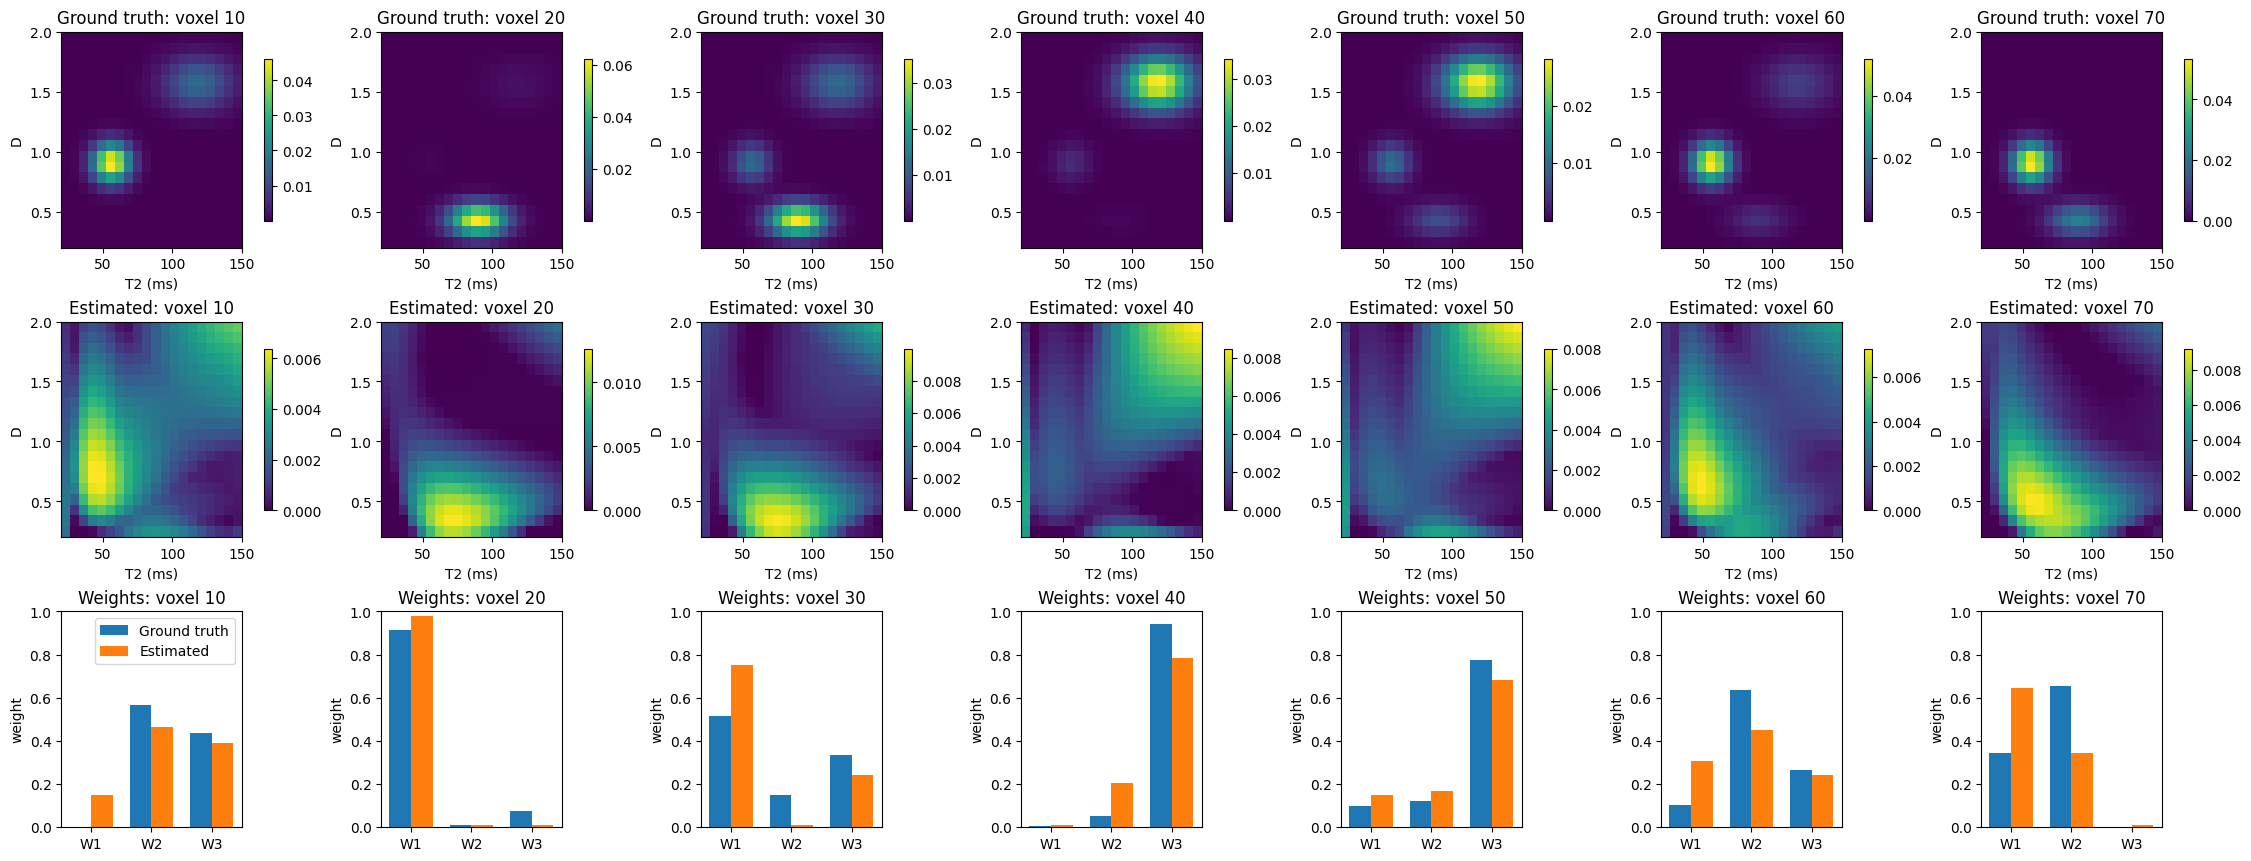

iter 0: loss=4172.7829, fit_err=270253.230011, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 1, entropy prior: estimated C, W MAE 0.121


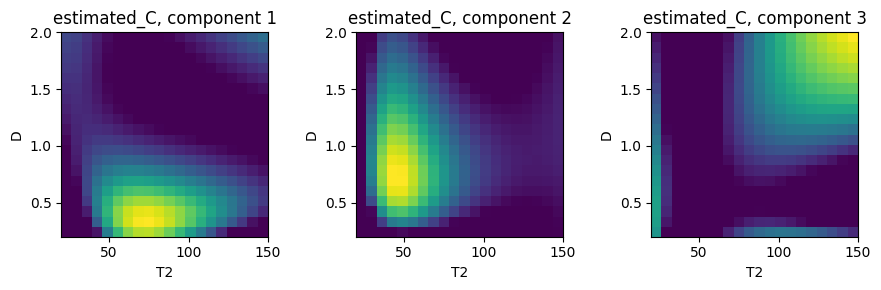

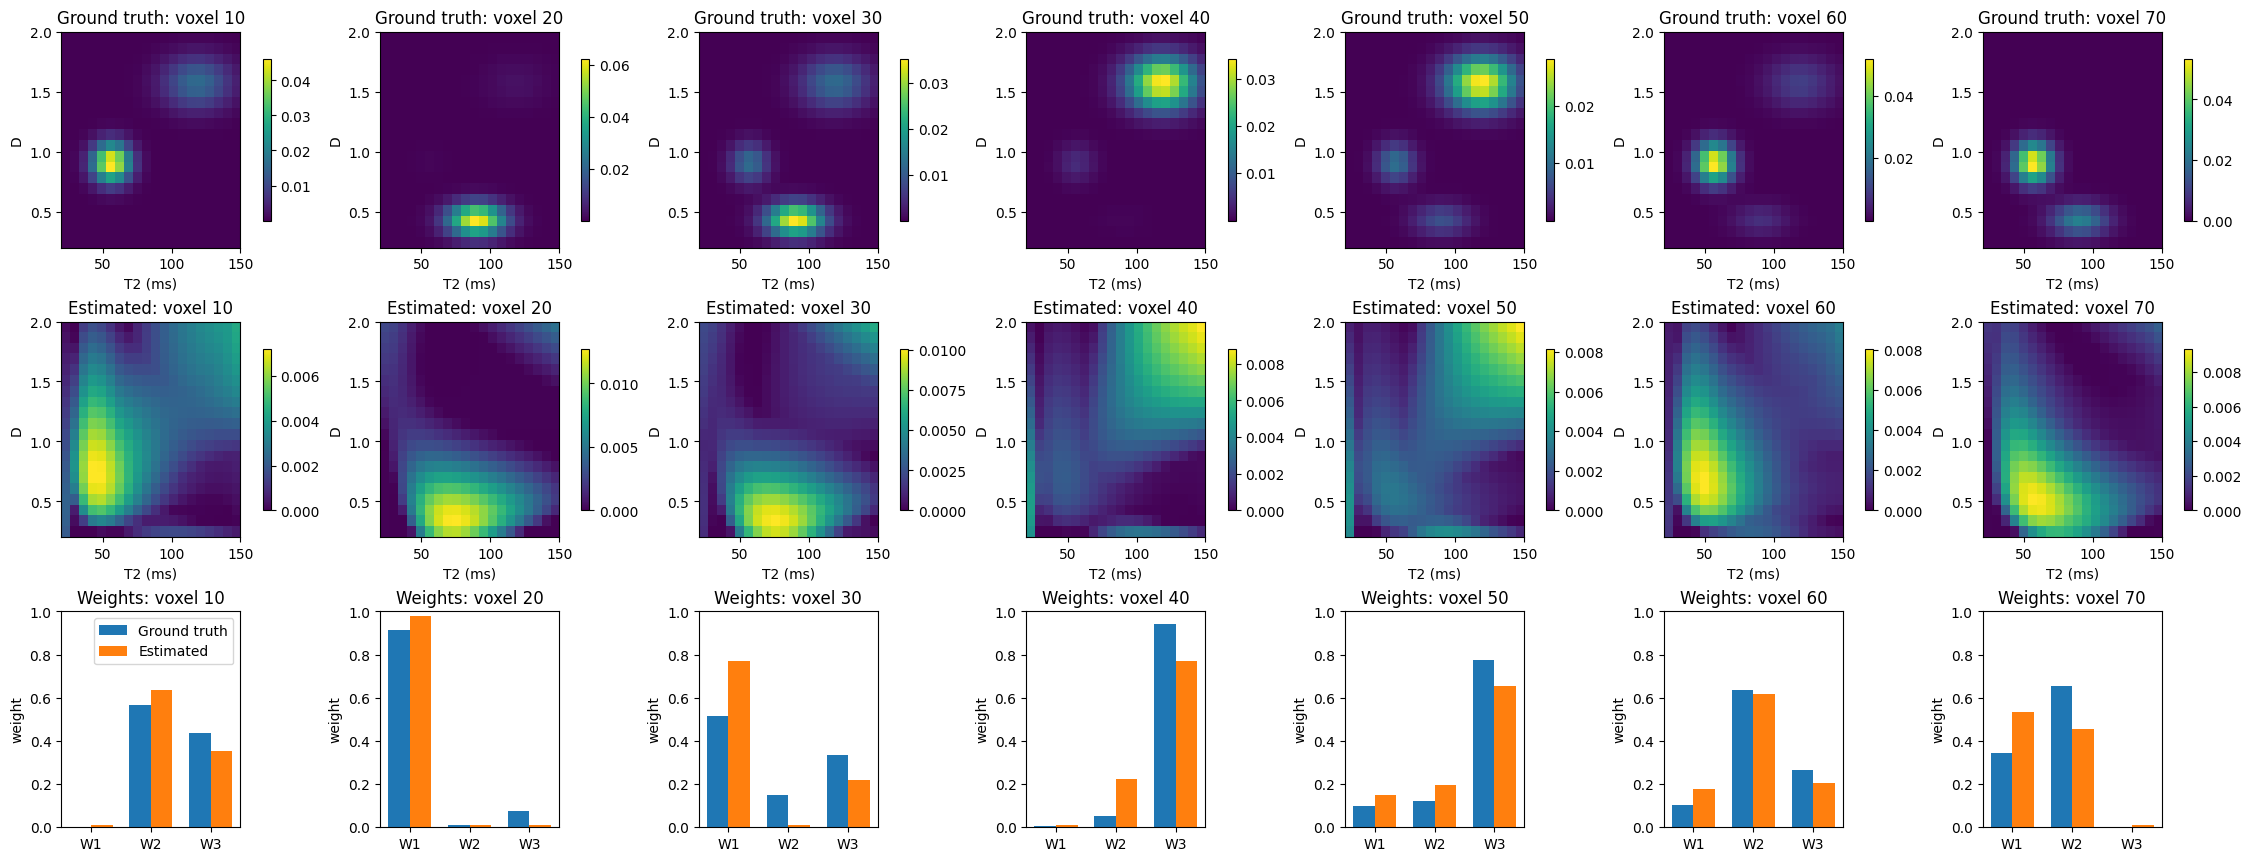

Seed 2: true C (first row) vs initial C (second row), starting W MAE 0.289


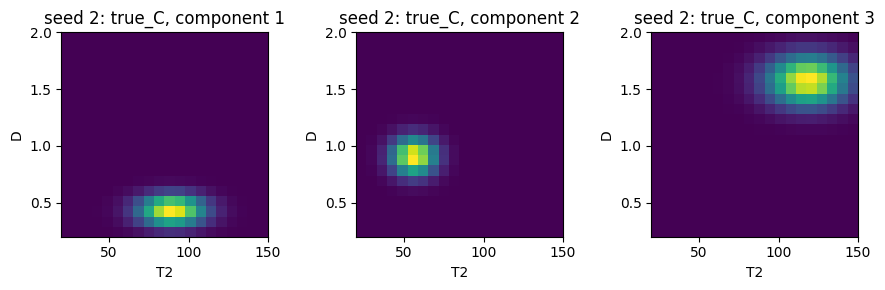

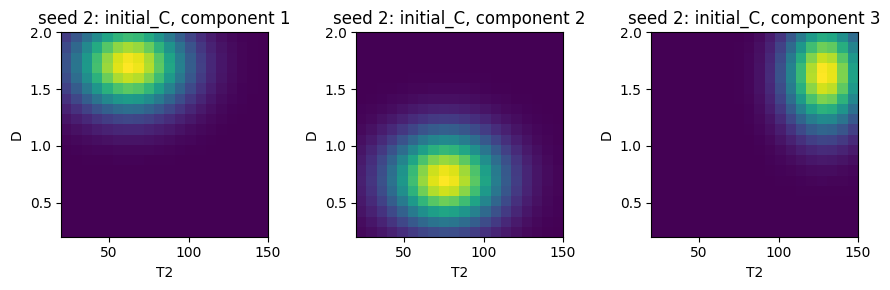



iter 0: loss=4305.6331, fit_err=313715.475917, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 2, dirichlet prior: estimated C, W MAE 0.173


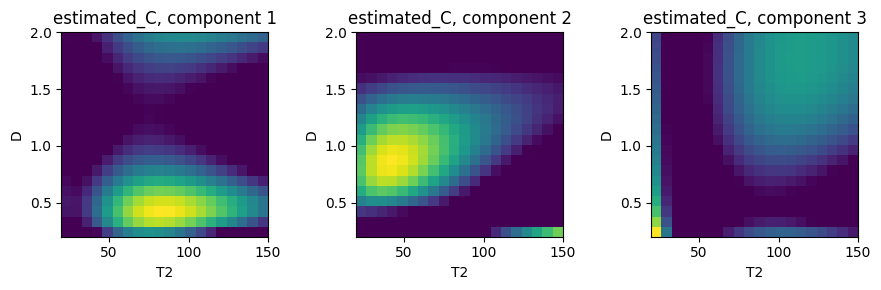

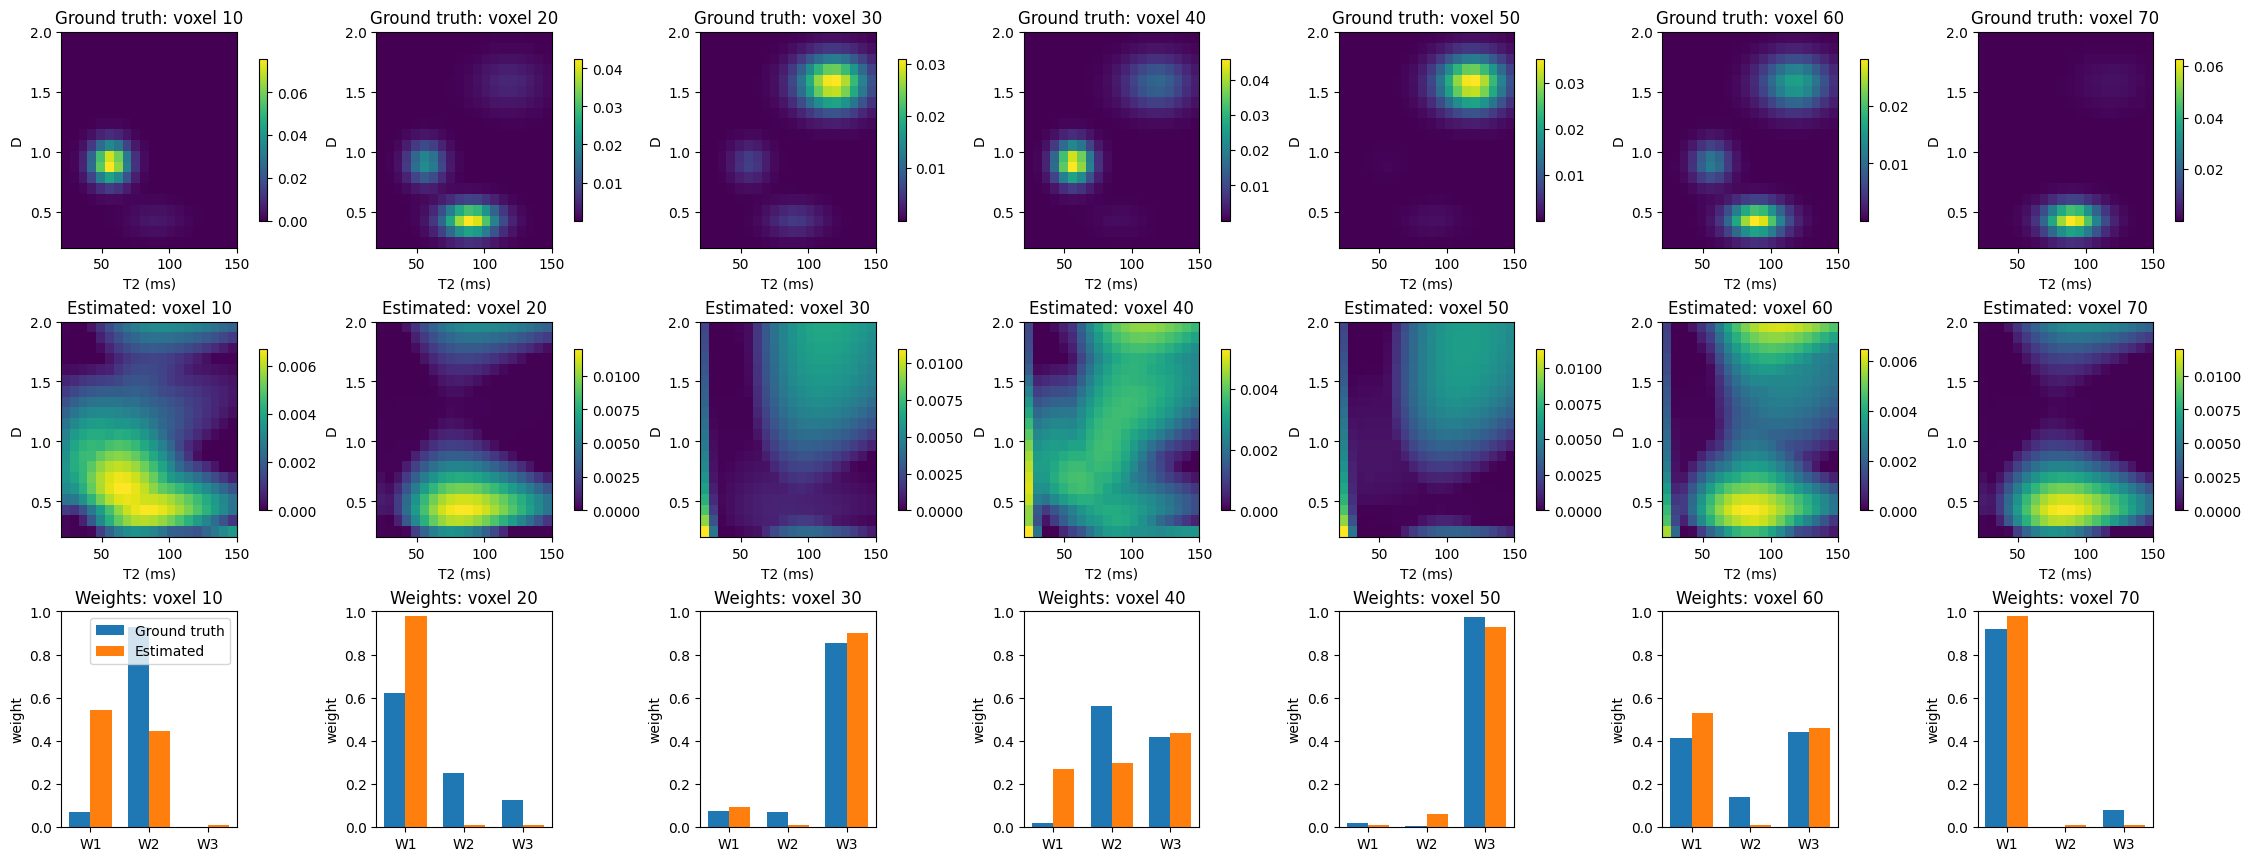

iter 0: loss=4943.6705, fit_err=325929.534362, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 2, entropy prior: estimated C, W MAE 0.222


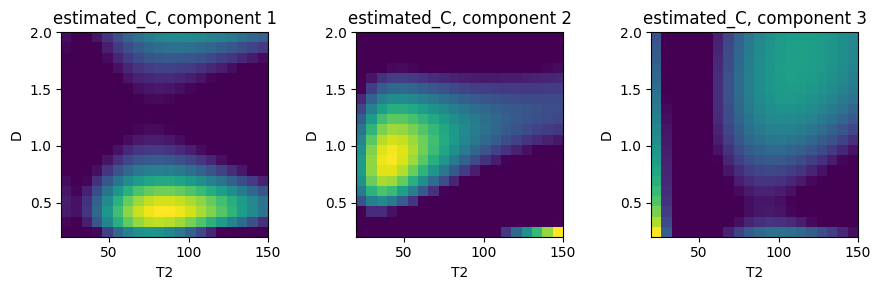

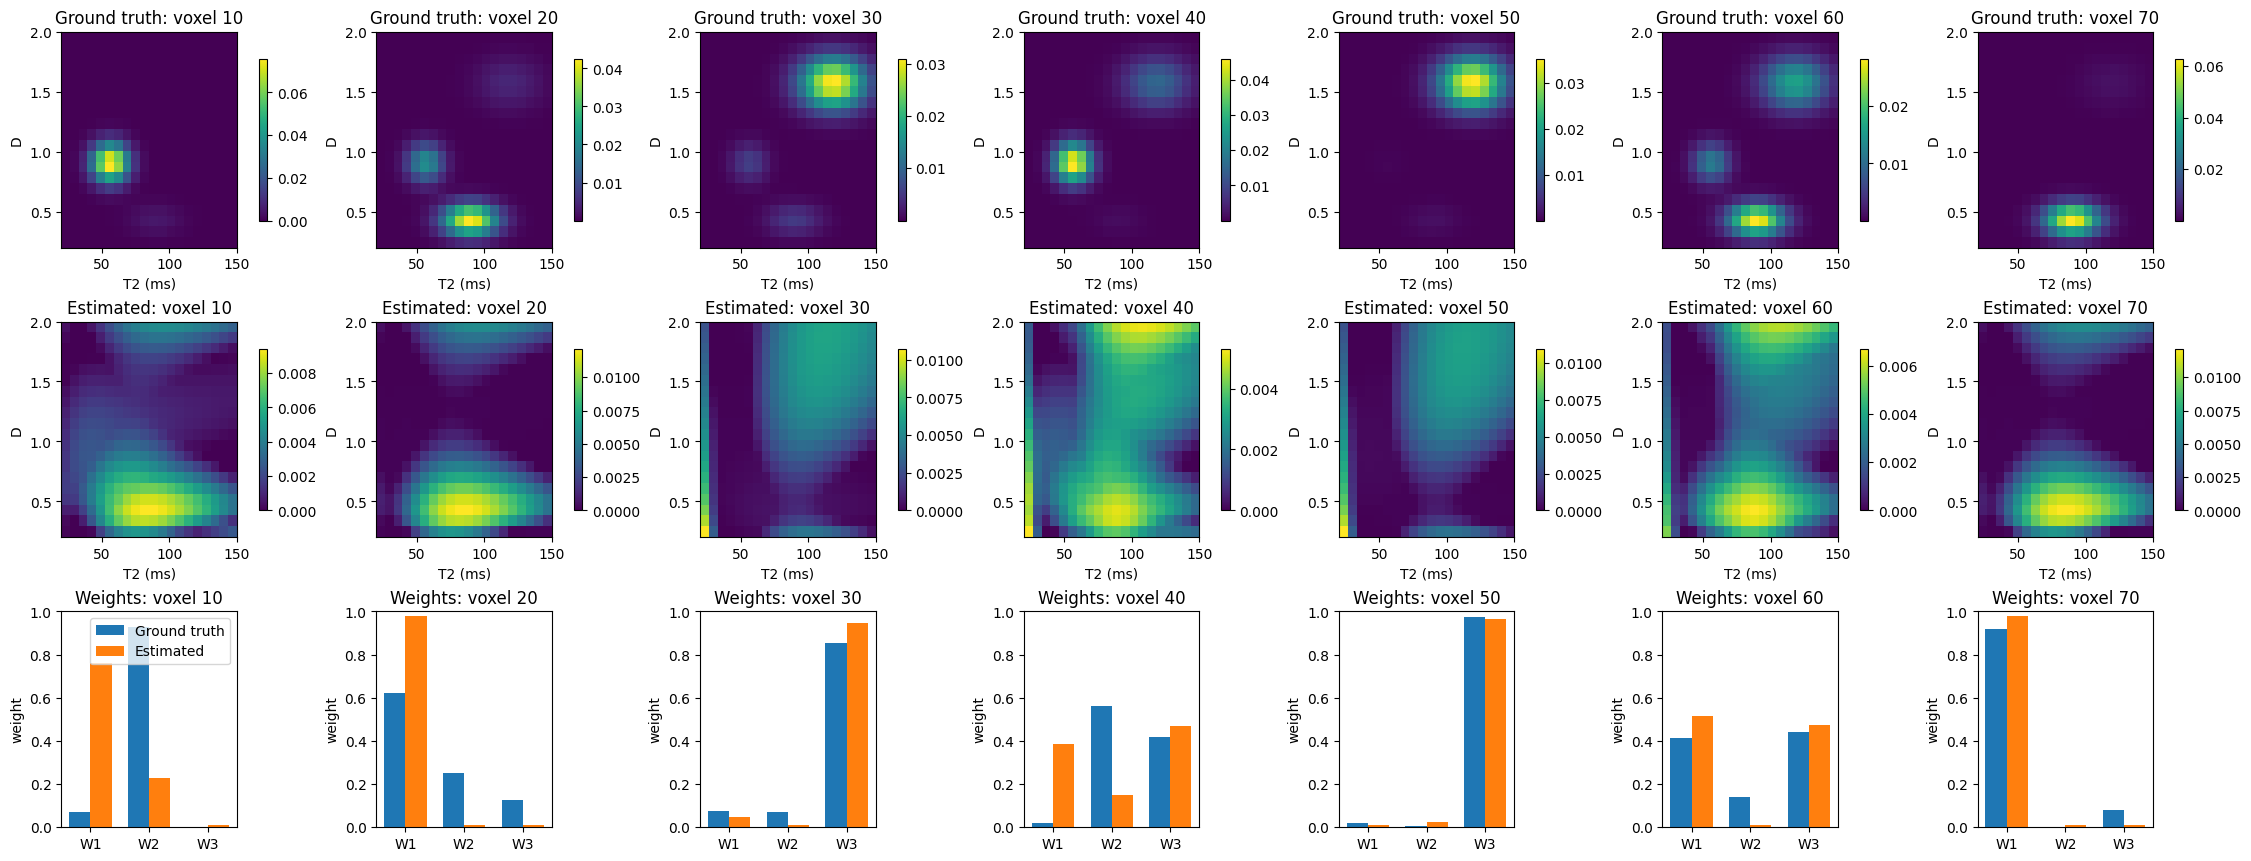

Seed 3: true C (first row) vs initial C (second row), starting W MAE 0.120


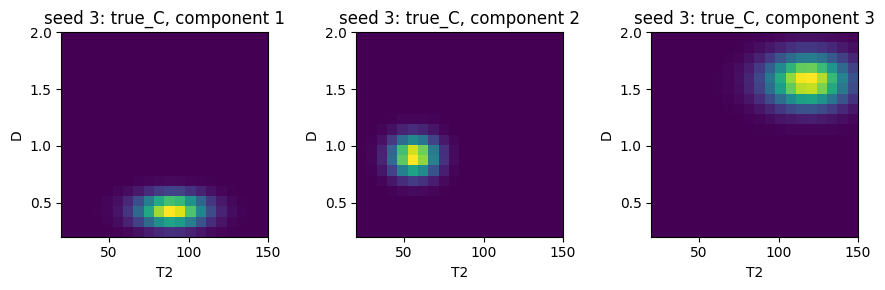

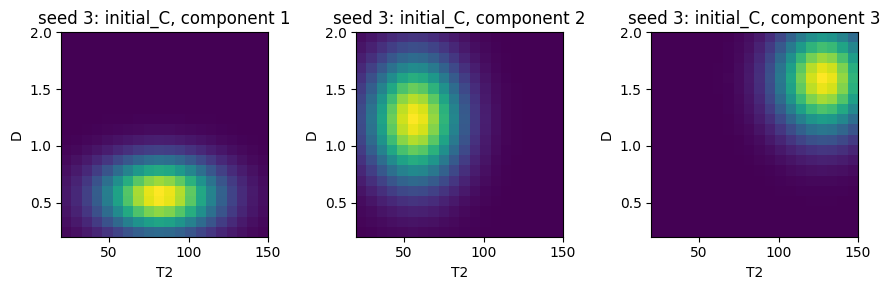



iter 0: loss=3075.0865, fit_err=225279.314945, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 3, dirichlet prior: estimated C, W MAE 0.063


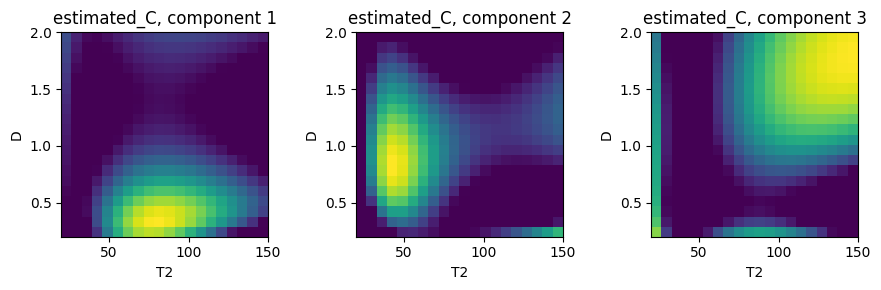

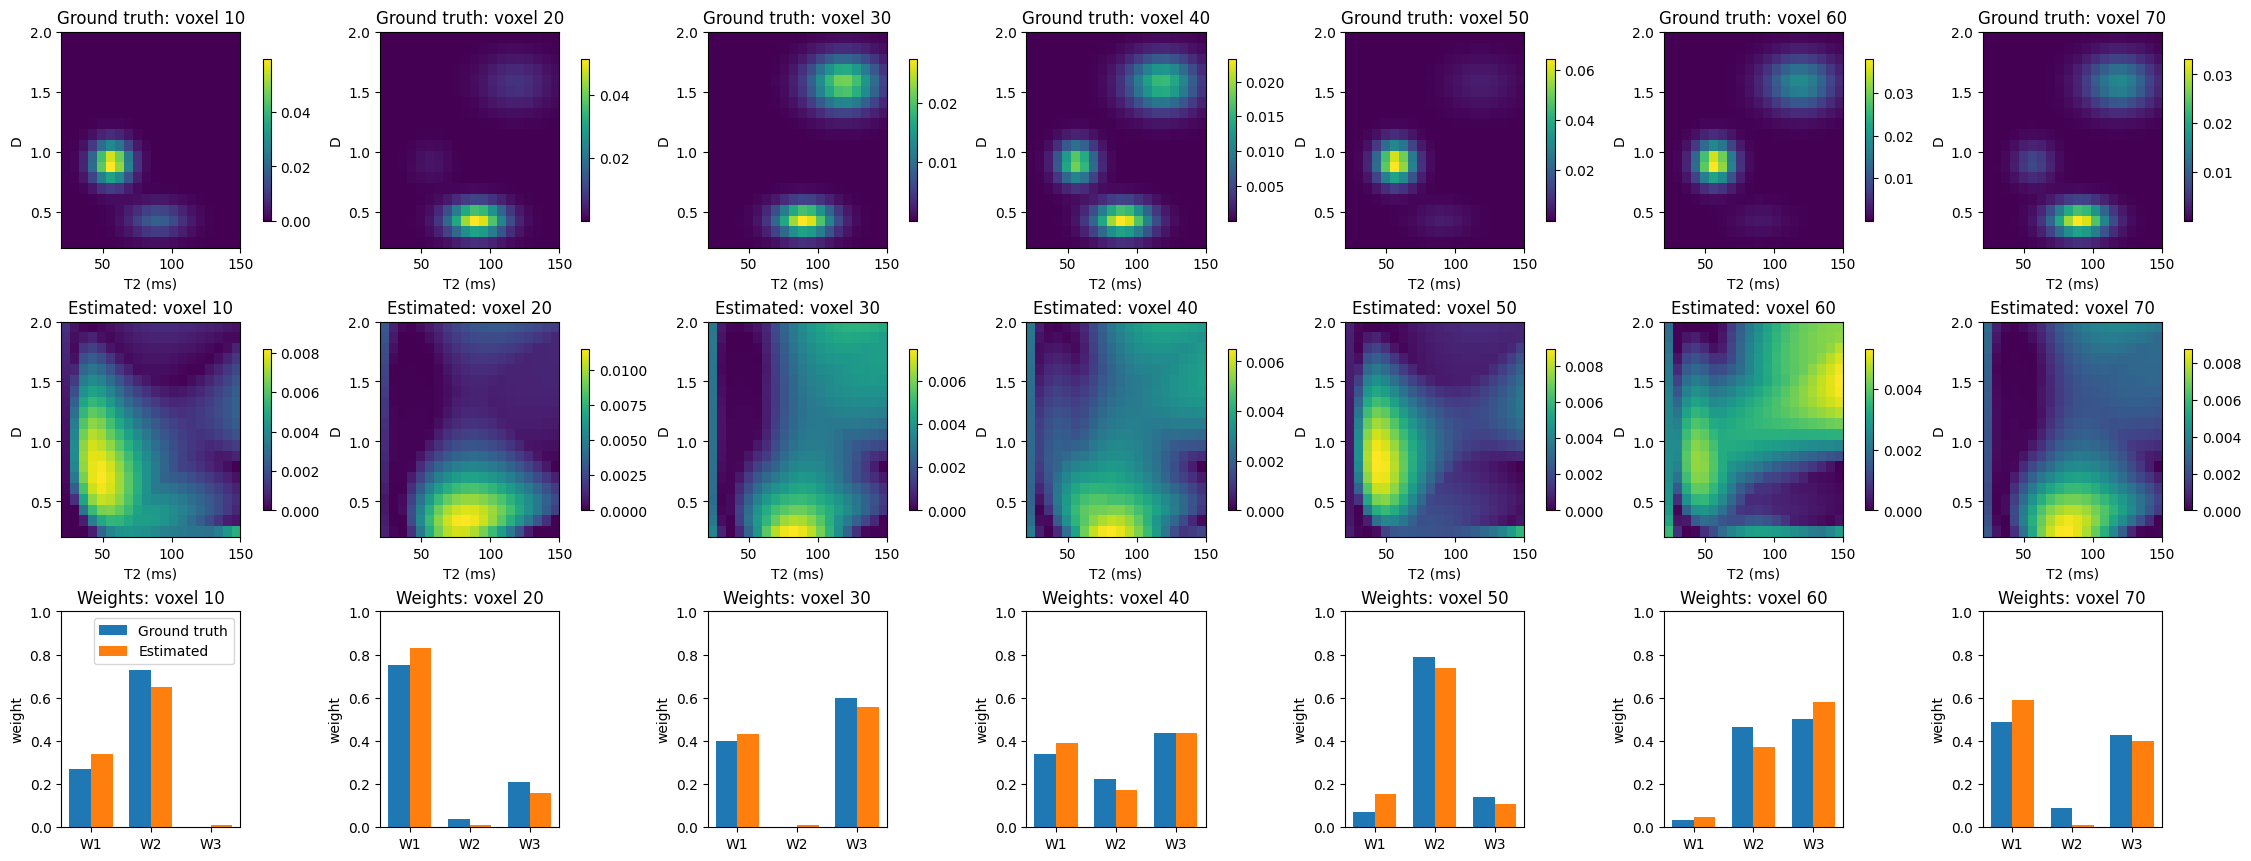

iter 0: loss=3594.4316, fit_err=230802.123027, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 3, entropy prior: estimated C, W MAE 0.063


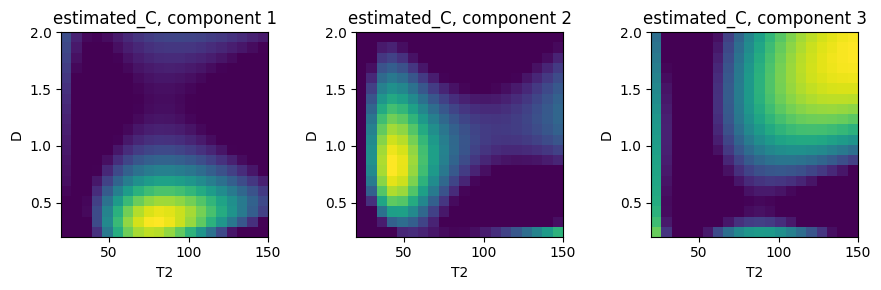

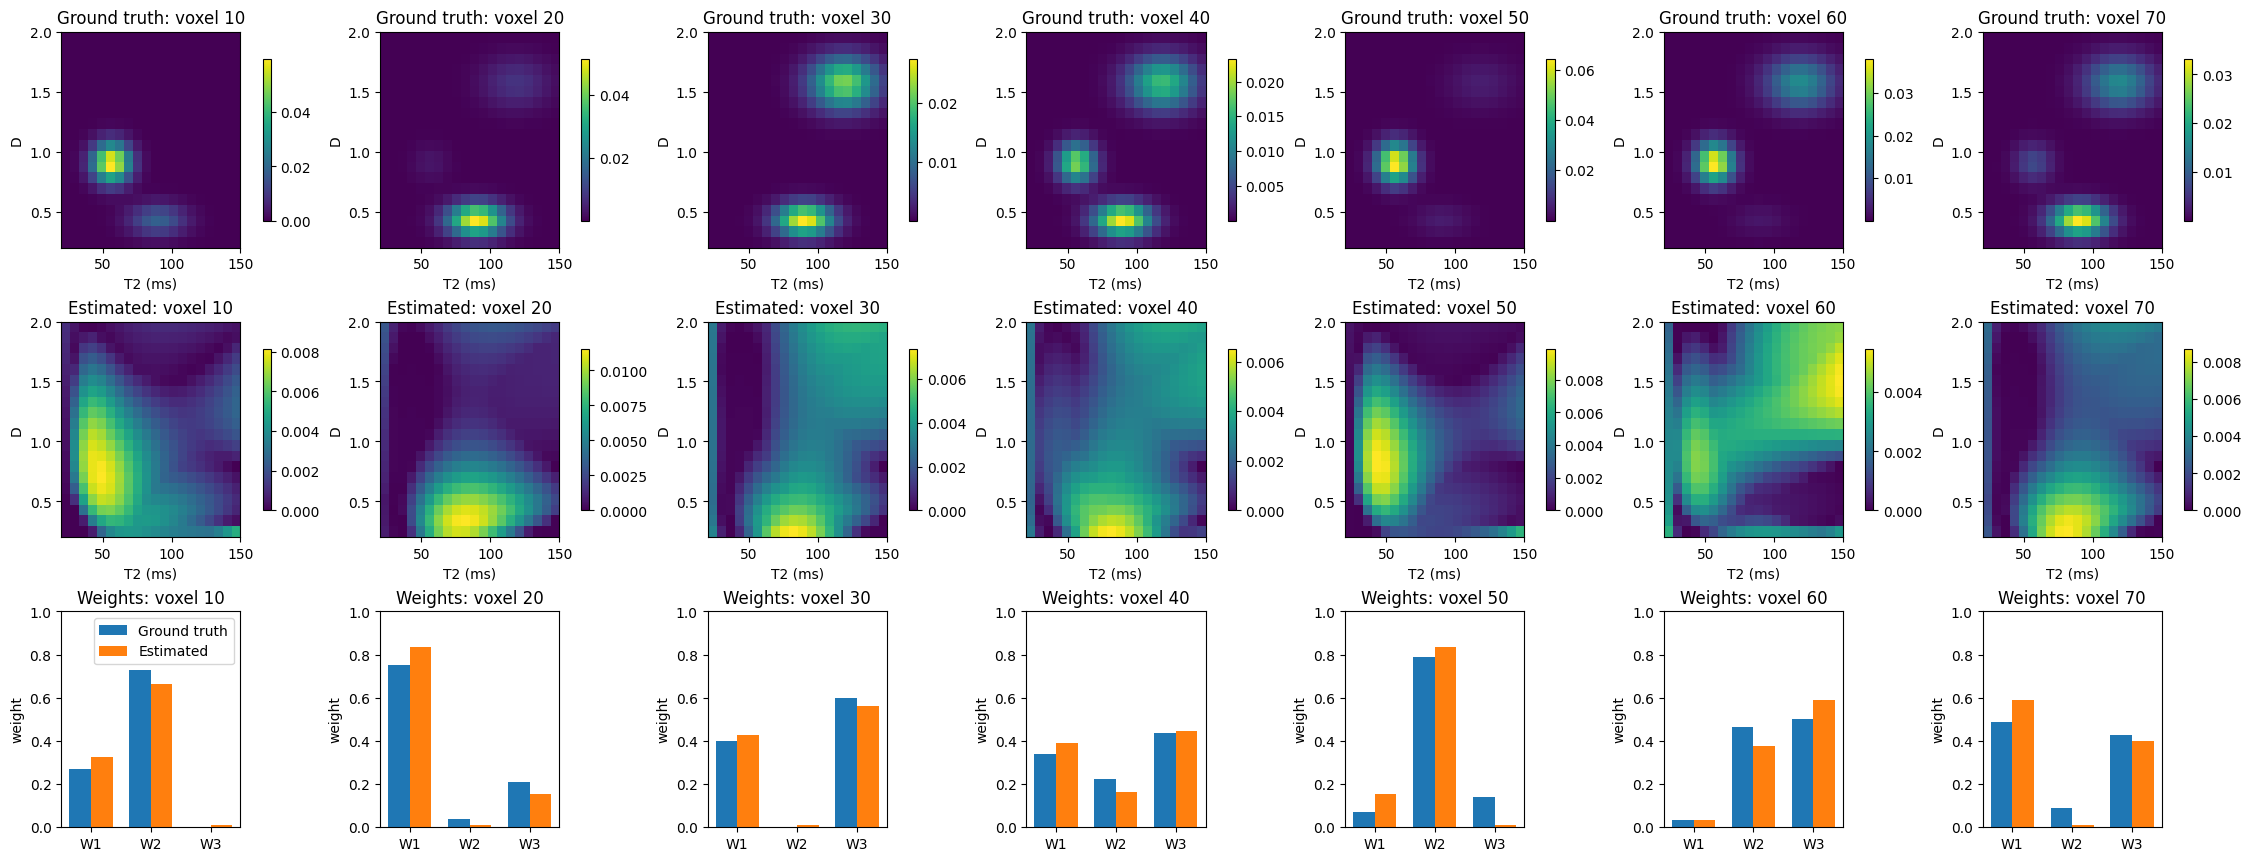

Seed 4: true C (first row) vs initial C (second row), starting W MAE 0.182


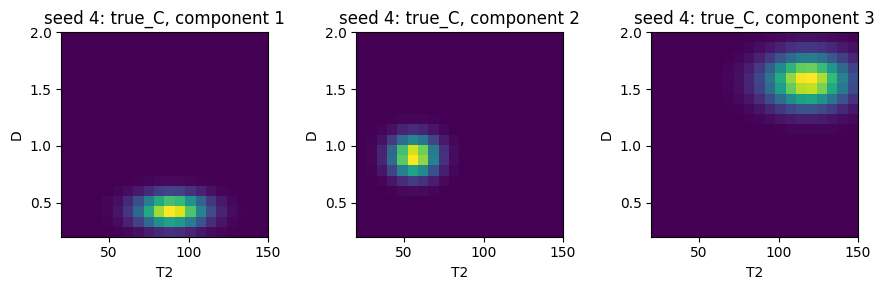

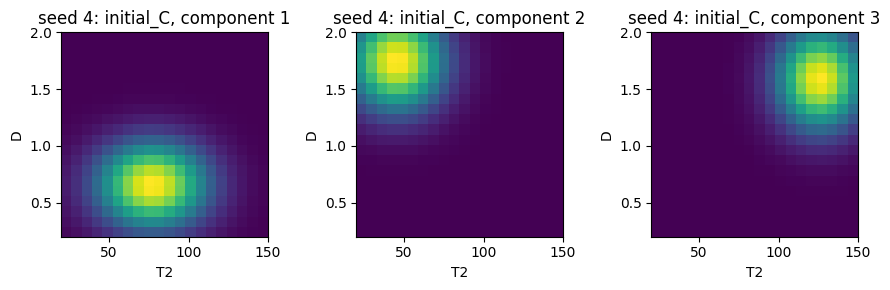



iter 0: loss=3417.5258, fit_err=249823.507872, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 4, dirichlet prior: estimated C, W MAE 0.163


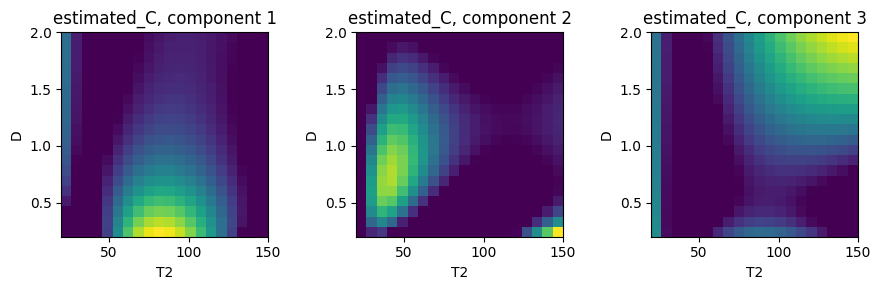

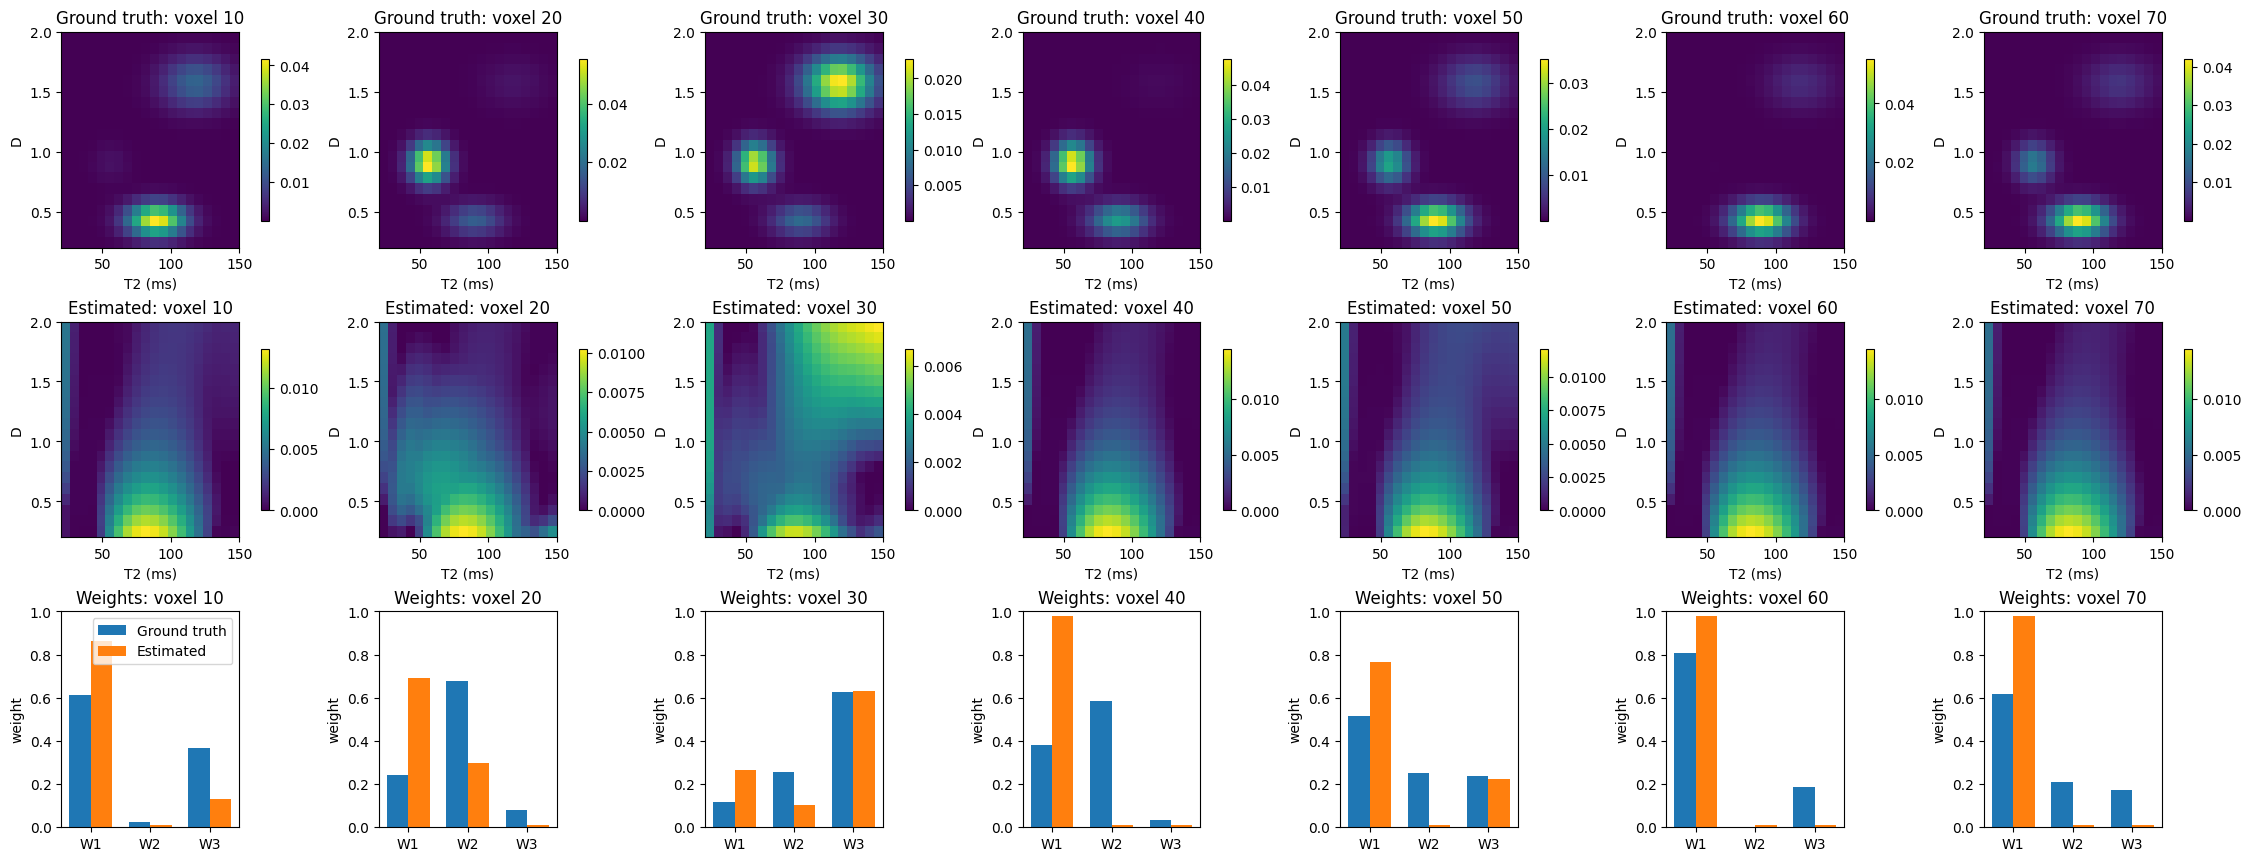

iter 0: loss=3878.8873, fit_err=255809.032234, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 4, entropy prior: estimated C, W MAE 0.195


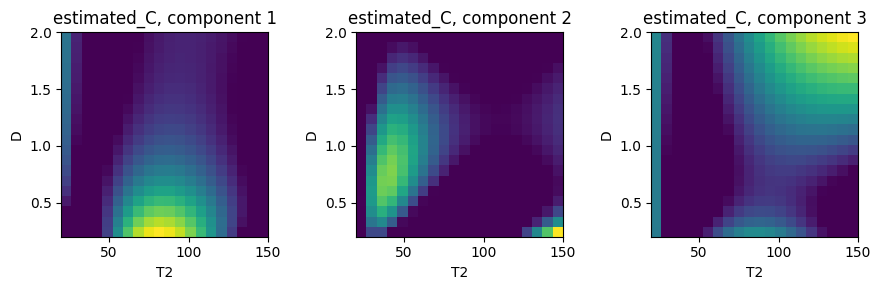

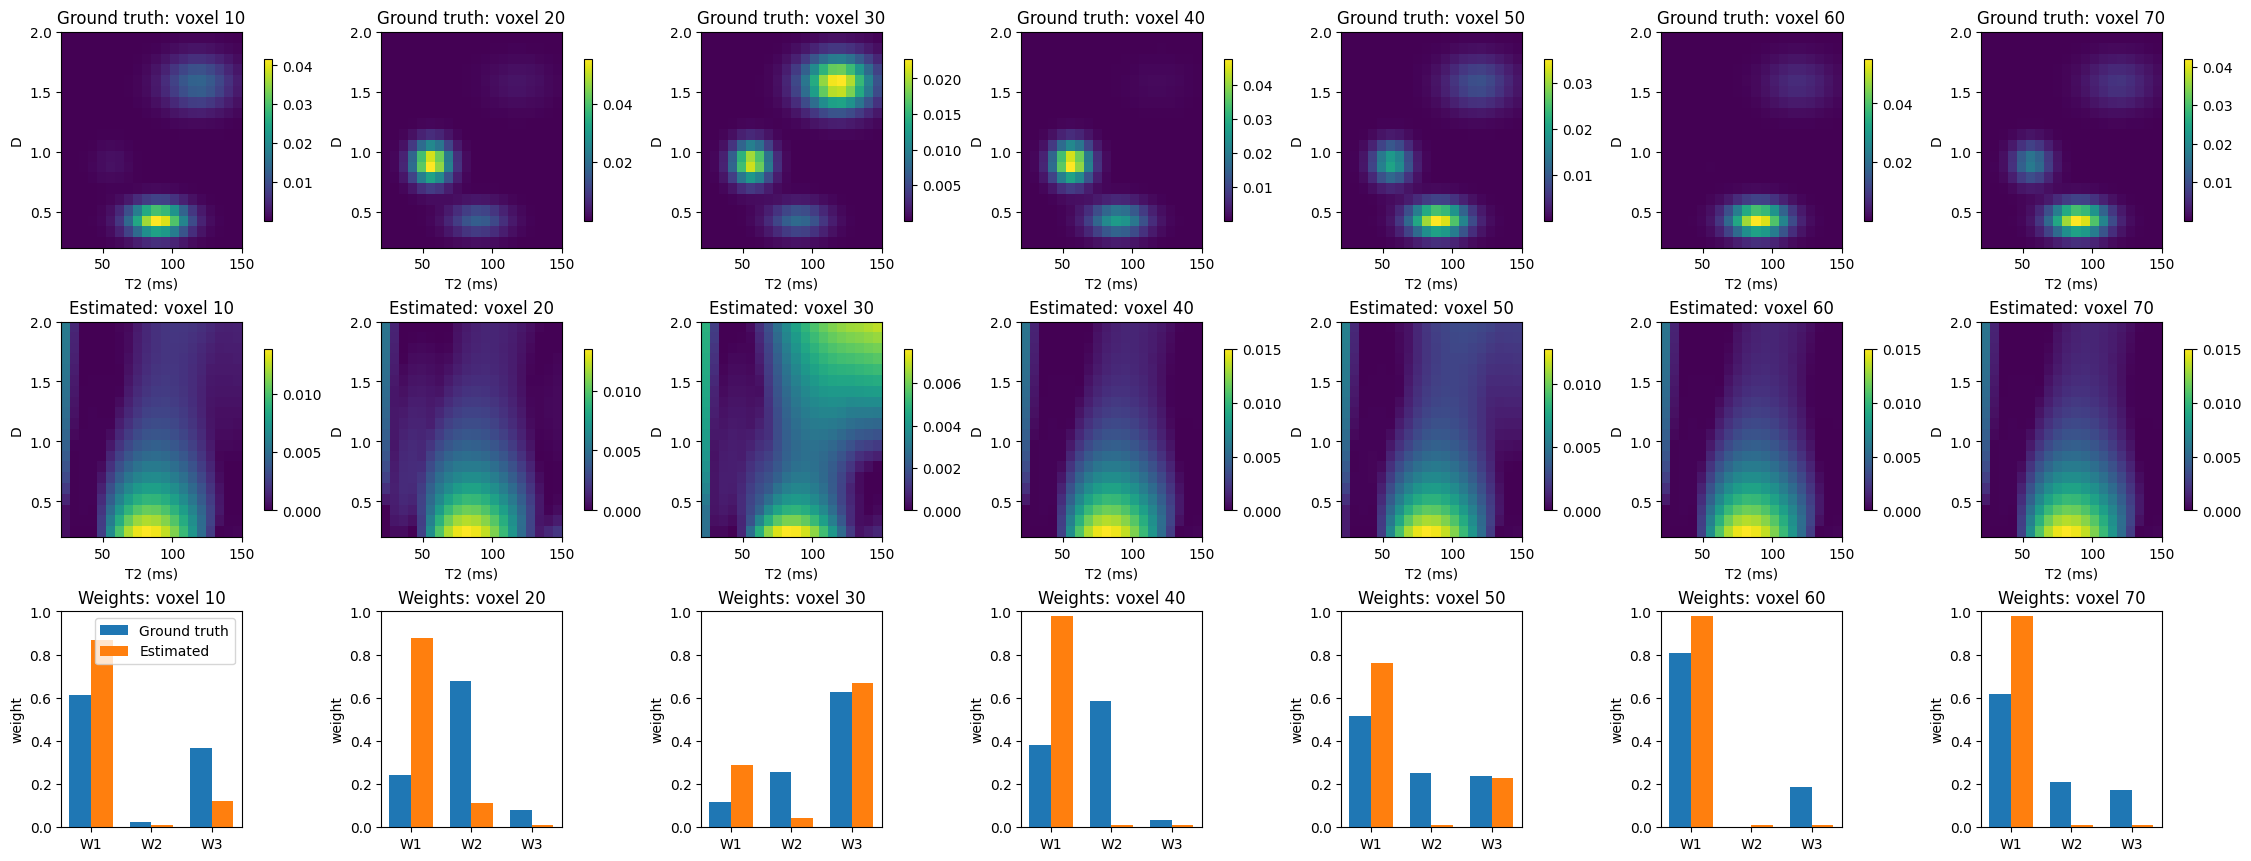

W MAE per seed: start, dirichlet, entropy
[[0.09  0.052 0.059]
 [0.185 0.135 0.121]
 [0.289 0.173 0.222]
 [0.12  0.063 0.063]
 [0.182 0.163 0.195]]
mean: [0.173 0.117 0.132]


In [38]:
# Dirichlet vs entropy prior on the same data, over several seeds
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

rows = []
for seed in range(5):
    rng_seed = np.random.default_rng(seed)
    alpha_true = 0.5
    W_true_dirichlet = rng_seed.dirichlet(alpha_true * np.ones(K), size=V).T

    # Calulate the signal Y = M0 * A * C_true * W_true
    Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_seed)

    # Set intial conditions
    C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
    #^^^ This function could be re-written to not have so many arguments 
    Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

    M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

    print(f"Seed {seed}: true C (first row) vs initial C (second row), starting W MAE {np.mean(np.abs(W_true_dirichlet - W0_dirichlet)):.3f}")
    show_canonical_spectra([(f'seed {seed}: true_C', C_true)])
    show_canonical_spectra([(f'seed {seed}: initial_C', C0_dirichlet)])
    print("\n")


    # ----------------


    R = 10
    U, s, Vmat = apply_SVD_to_A(A, R)

    # C0 stays on the physical D–T2 grid, so it does not depend on R.
    Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

    # Refit weights because U @ Csmall0 has changed.
    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    errors = [np.mean(np.abs(W_true_dirichlet - W0_dirichlet))]
    for name, kwargs in priors.items():
        W_est_dirichlet, _, Csmall_est_dirichlet, *_ = run_optimisation(
            Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, K=K, R=R, eps=1e-10, n_iter=300,
            sigma2=np.mean(sigma**2), lam=1e-8, W=W0_dirichlet.copy(),
            update_W_flag=True, update_C_flag=True, update_M0_flag=True,
            m0_prior=M0_init_dirichlet, m0_prior_sigma=0.15, alpha=1.0, alpha_update_start=5,
            verbose_every=300, **kwargs)
        C_est_dirichlet, W_est_dirichlet = order_components(C_true, estimate_C(Vmat, s, Csmall_est_dirichlet), W_est_dirichlet, K)
        errors.append(np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
        print(f"Seed {seed}, {name} prior: estimated C, W MAE {errors[-1]:.3f}")
        show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
        
        F_true = C_true @ W_true_dirichlet
        F_est = C_est_dirichlet @ W_est_dirichlet
        show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)

    rows.append(errors)

print("W MAE per seed: start, dirichlet, entropy")
print(np.round(rows, 3))
print("mean:", np.round(np.mean(rows, axis=0), 3))


#### Same comparison: signal-averaged initialisation
Average the signals, then one NNLS. Same seeds and settings as above, only the initialisation changes.

Seed 0: true C (first row) vs initial C (second row), starting W MAE 0.098


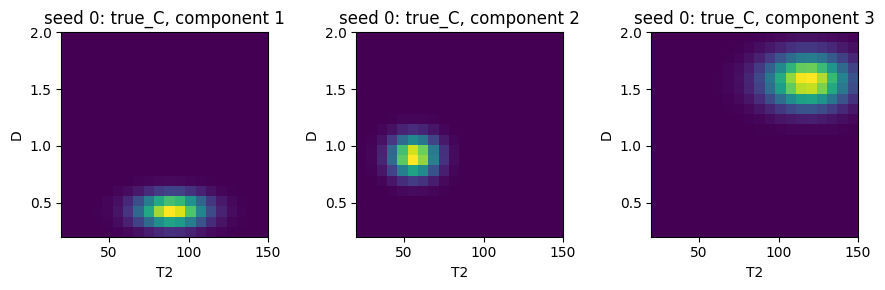

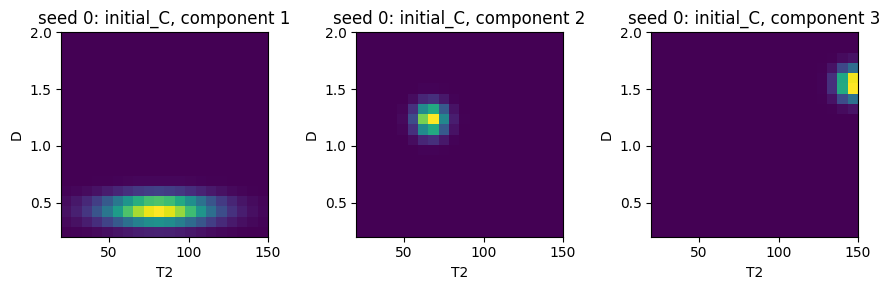



iter 0: loss=2565.4598, fit_err=188673.681302, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=2427.5027, fit_err=181465.262803, sigma2=36.000000, lam=0.0000, alpha=0.5002
iter 200: loss=2427.5015, fit_err=181466.399038, sigma2=36.000000, lam=0.0000, alpha=0.5001
Seed 0, dirichlet prior: estimated C, W MAE 0.041


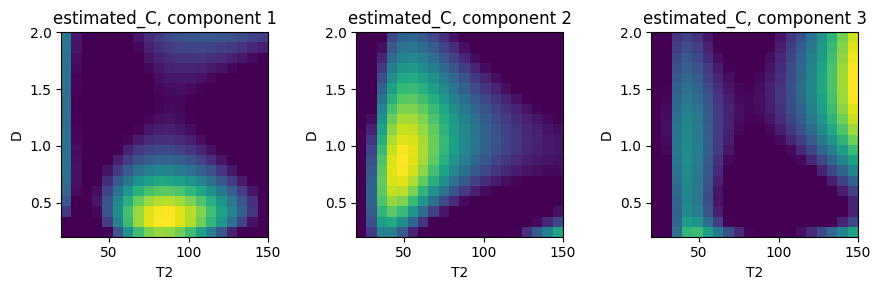

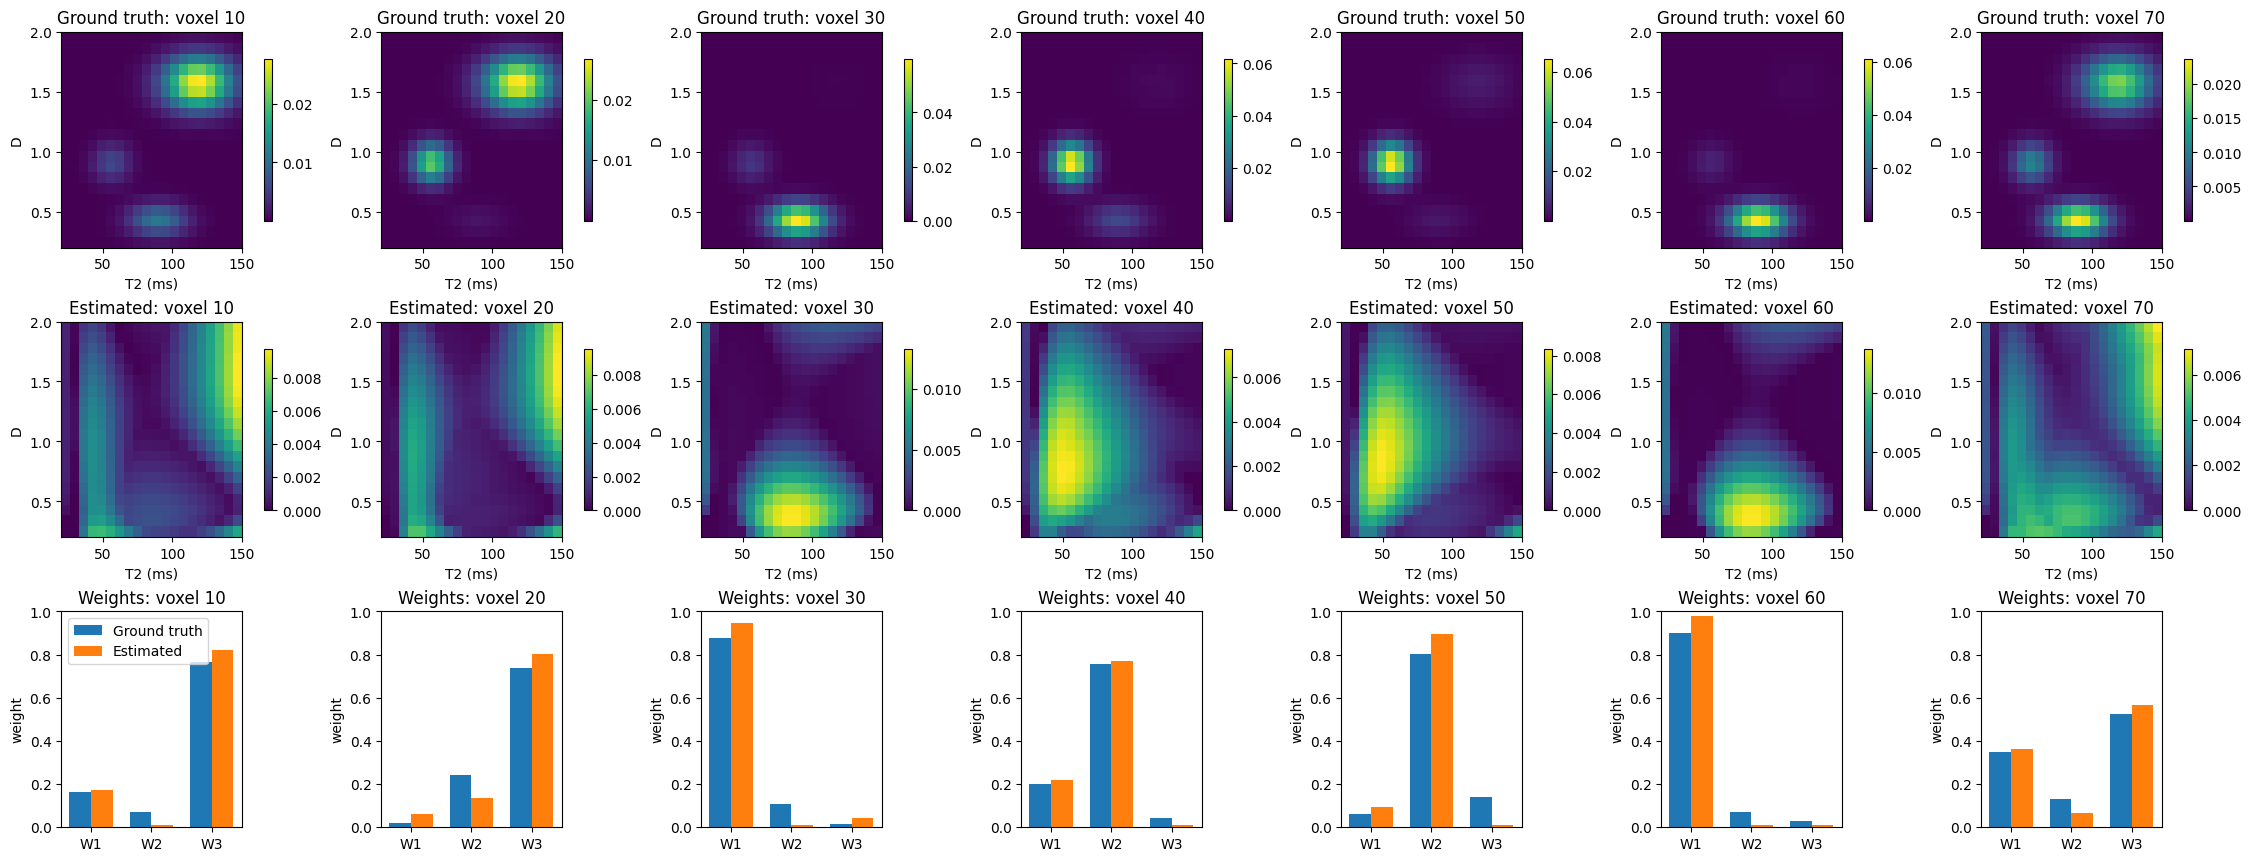

iter 0: loss=3162.1022, fit_err=190519.746344, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=2948.9145, fit_err=182797.987588, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 200: loss=2948.9145, fit_err=182798.045178, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 0, entropy prior: estimated C, W MAE 0.048


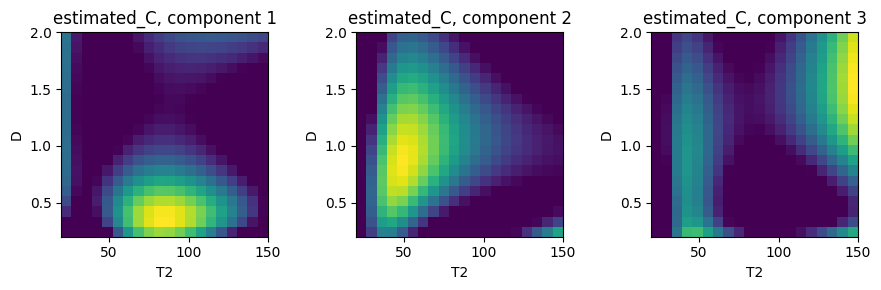

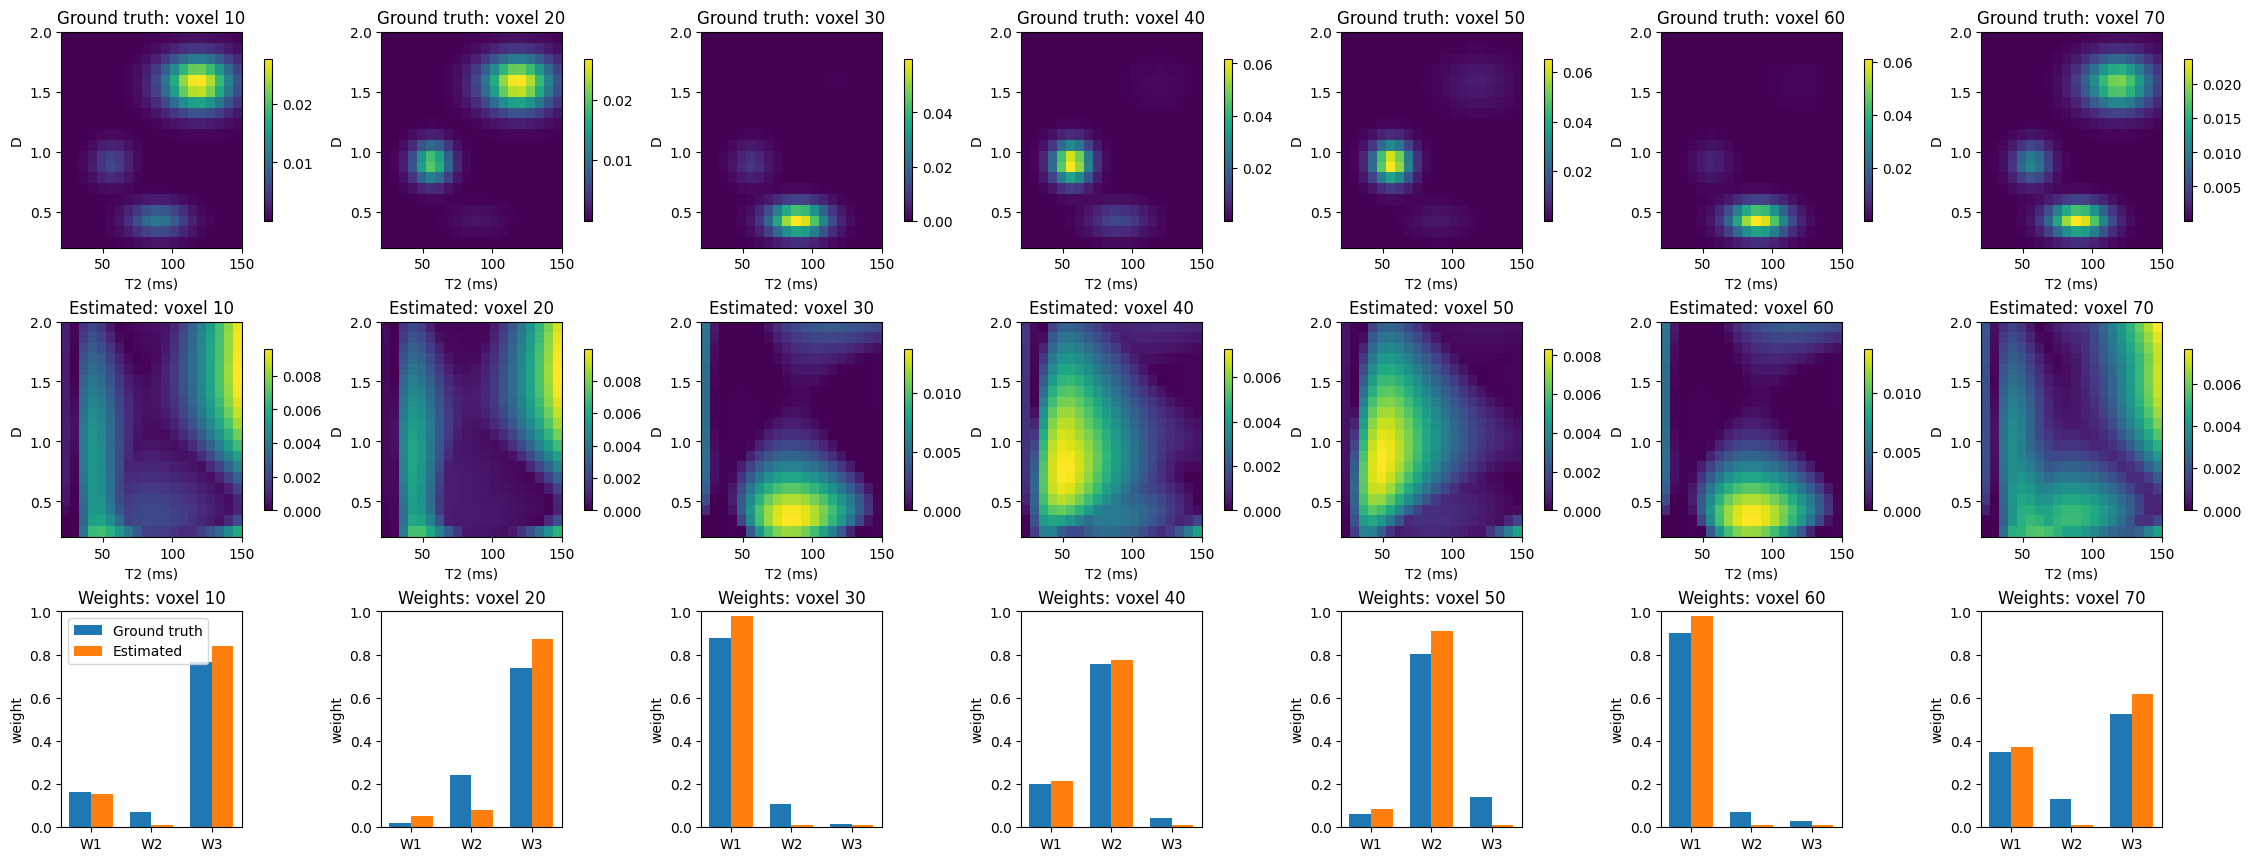

Seed 1: true C (first row) vs initial C (second row), starting W MAE 0.206


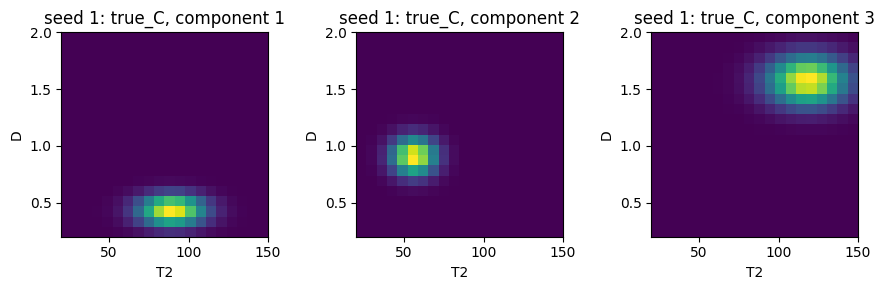

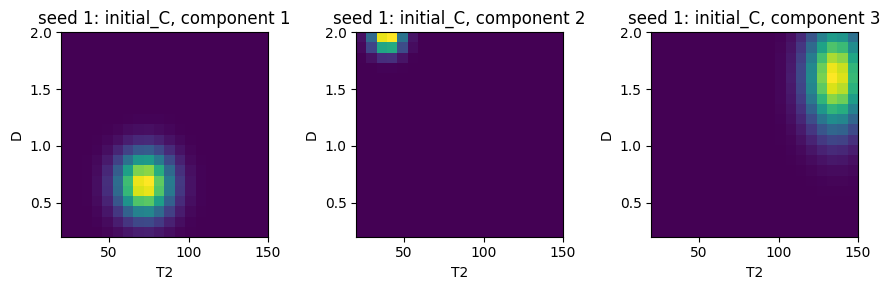



iter 0: loss=3565.8677, fit_err=260472.611046, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=3085.6645, fit_err=228419.696816, sigma2=36.000000, lam=0.0000, alpha=0.5218
iter 200: loss=3085.0873, fit_err=228411.492089, sigma2=36.000000, lam=0.0000, alpha=0.5197
Seed 1, dirichlet prior: estimated C, W MAE 0.185


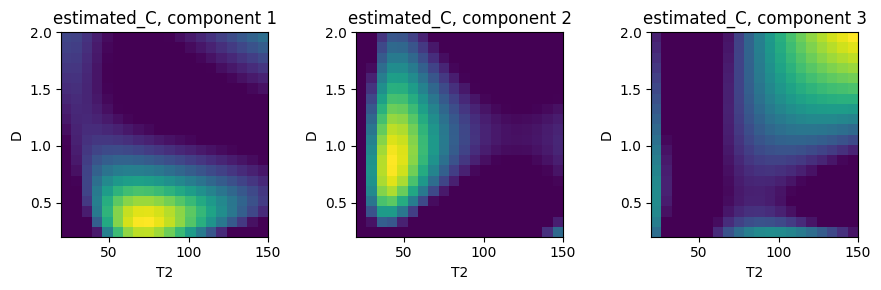

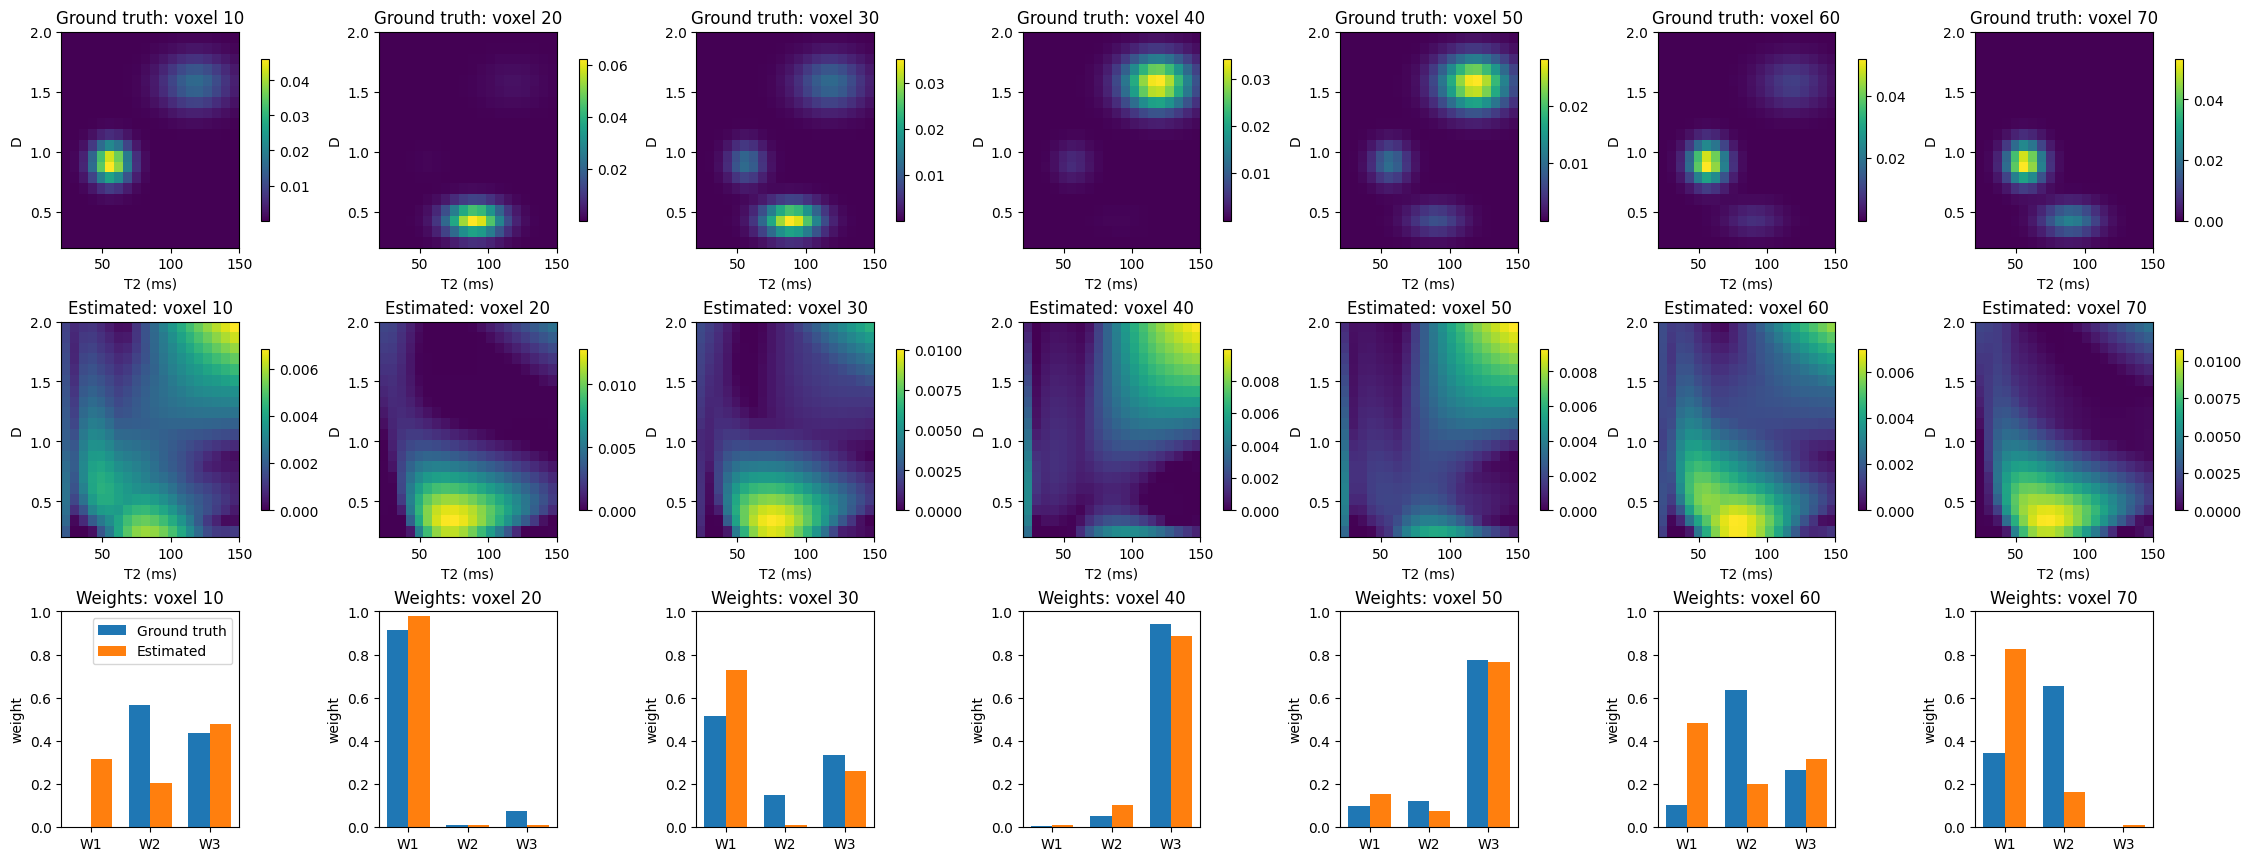

iter 0: loss=4137.8756, fit_err=267006.757777, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=3597.7797, fit_err=229399.498763, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 200: loss=3573.4633, fit_err=229355.298679, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 1, entropy prior: estimated C, W MAE 0.219


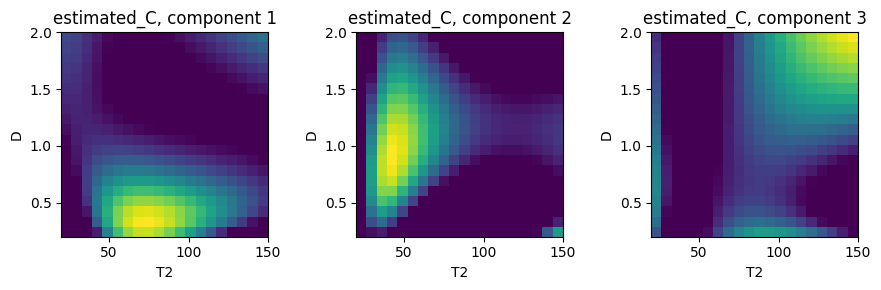

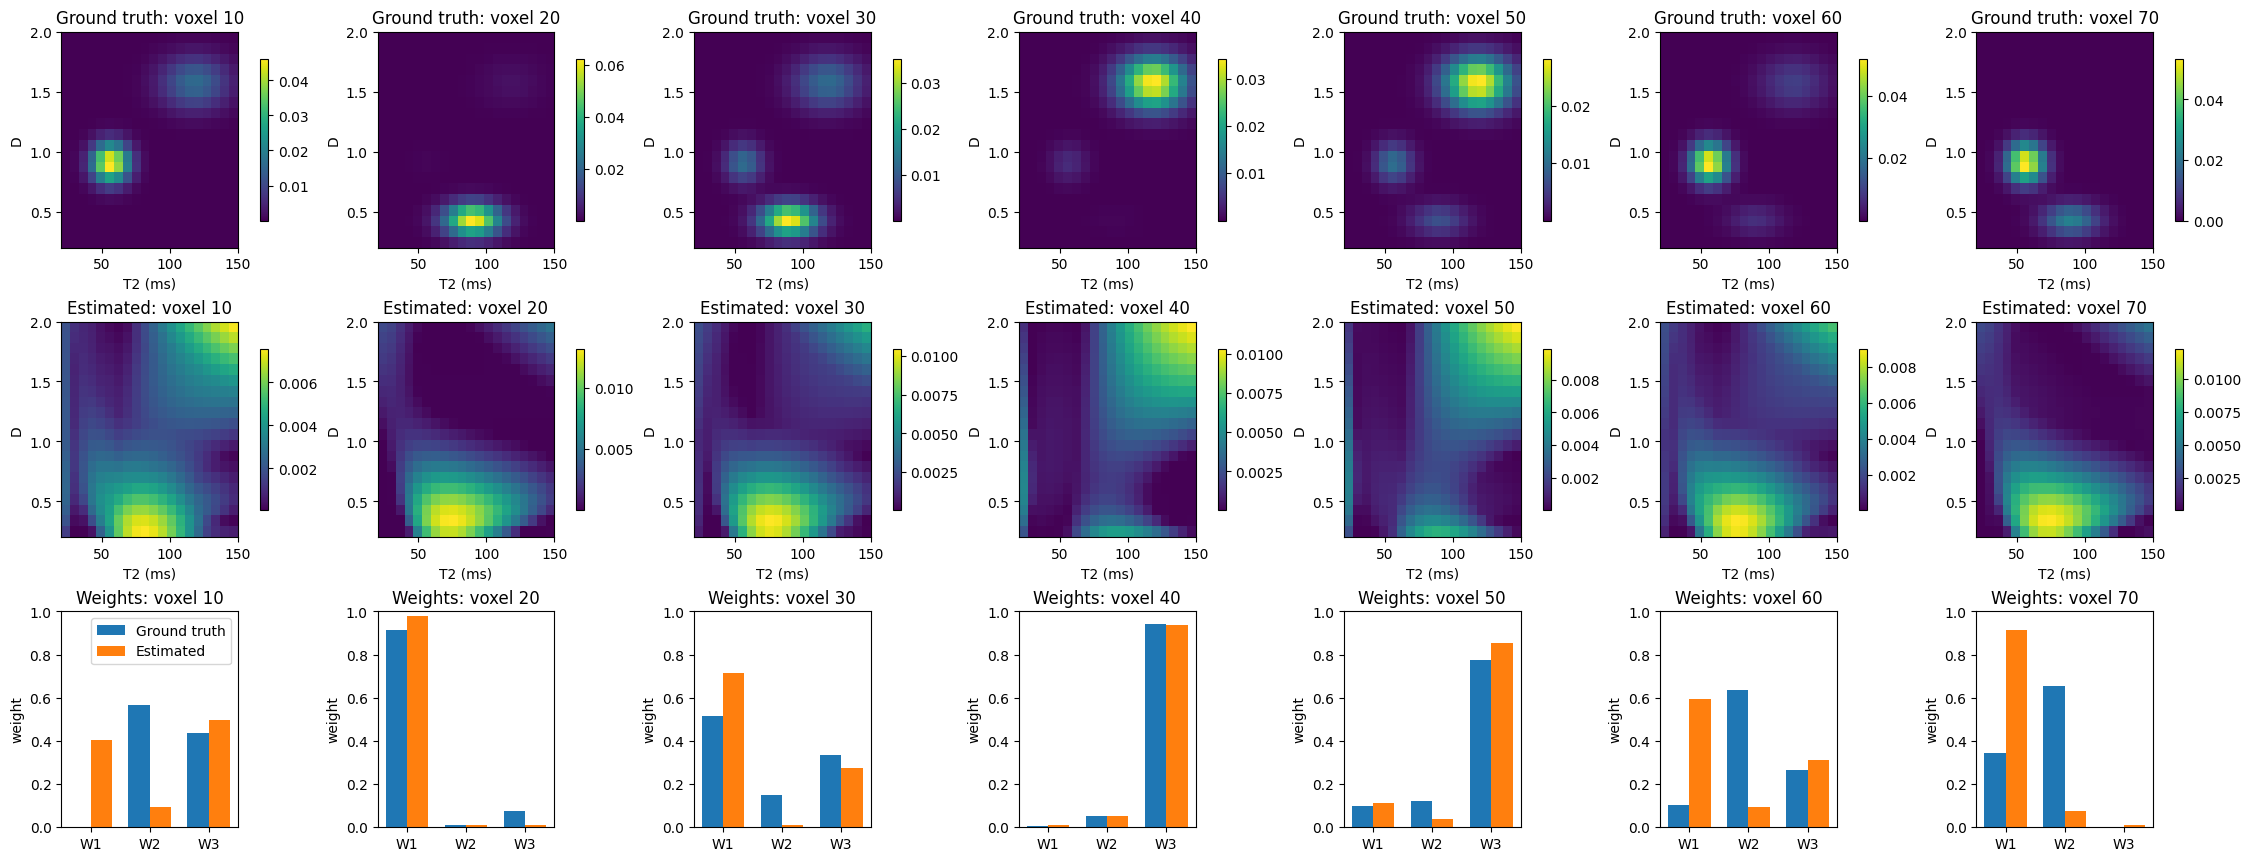

Seed 2: true C (first row) vs initial C (second row), starting W MAE 0.247


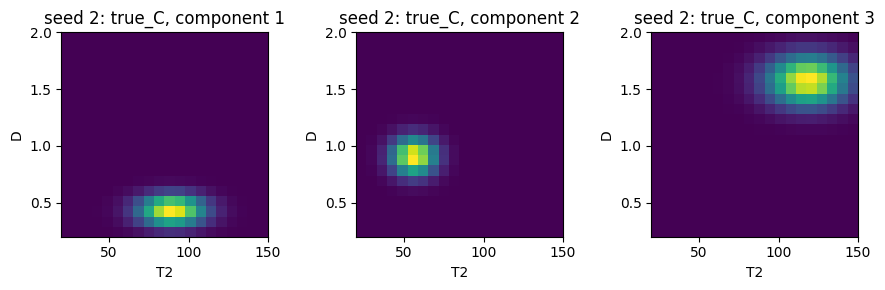

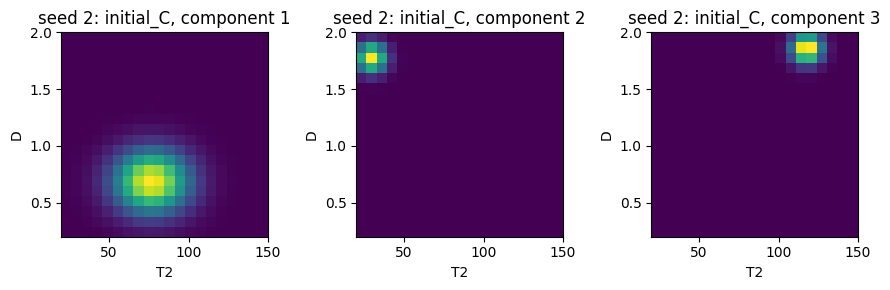



iter 0: loss=3970.2510, fit_err=289602.248458, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=3010.2304, fit_err=223123.813104, sigma2=36.000000, lam=0.0000, alpha=0.5147
iter 200: loss=3009.0584, fit_err=223124.341032, sigma2=36.000000, lam=0.0000, alpha=0.5097
Seed 2, dirichlet prior: estimated C, W MAE 0.229


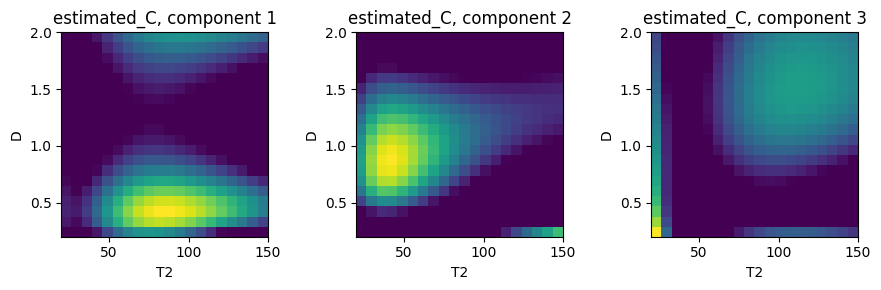

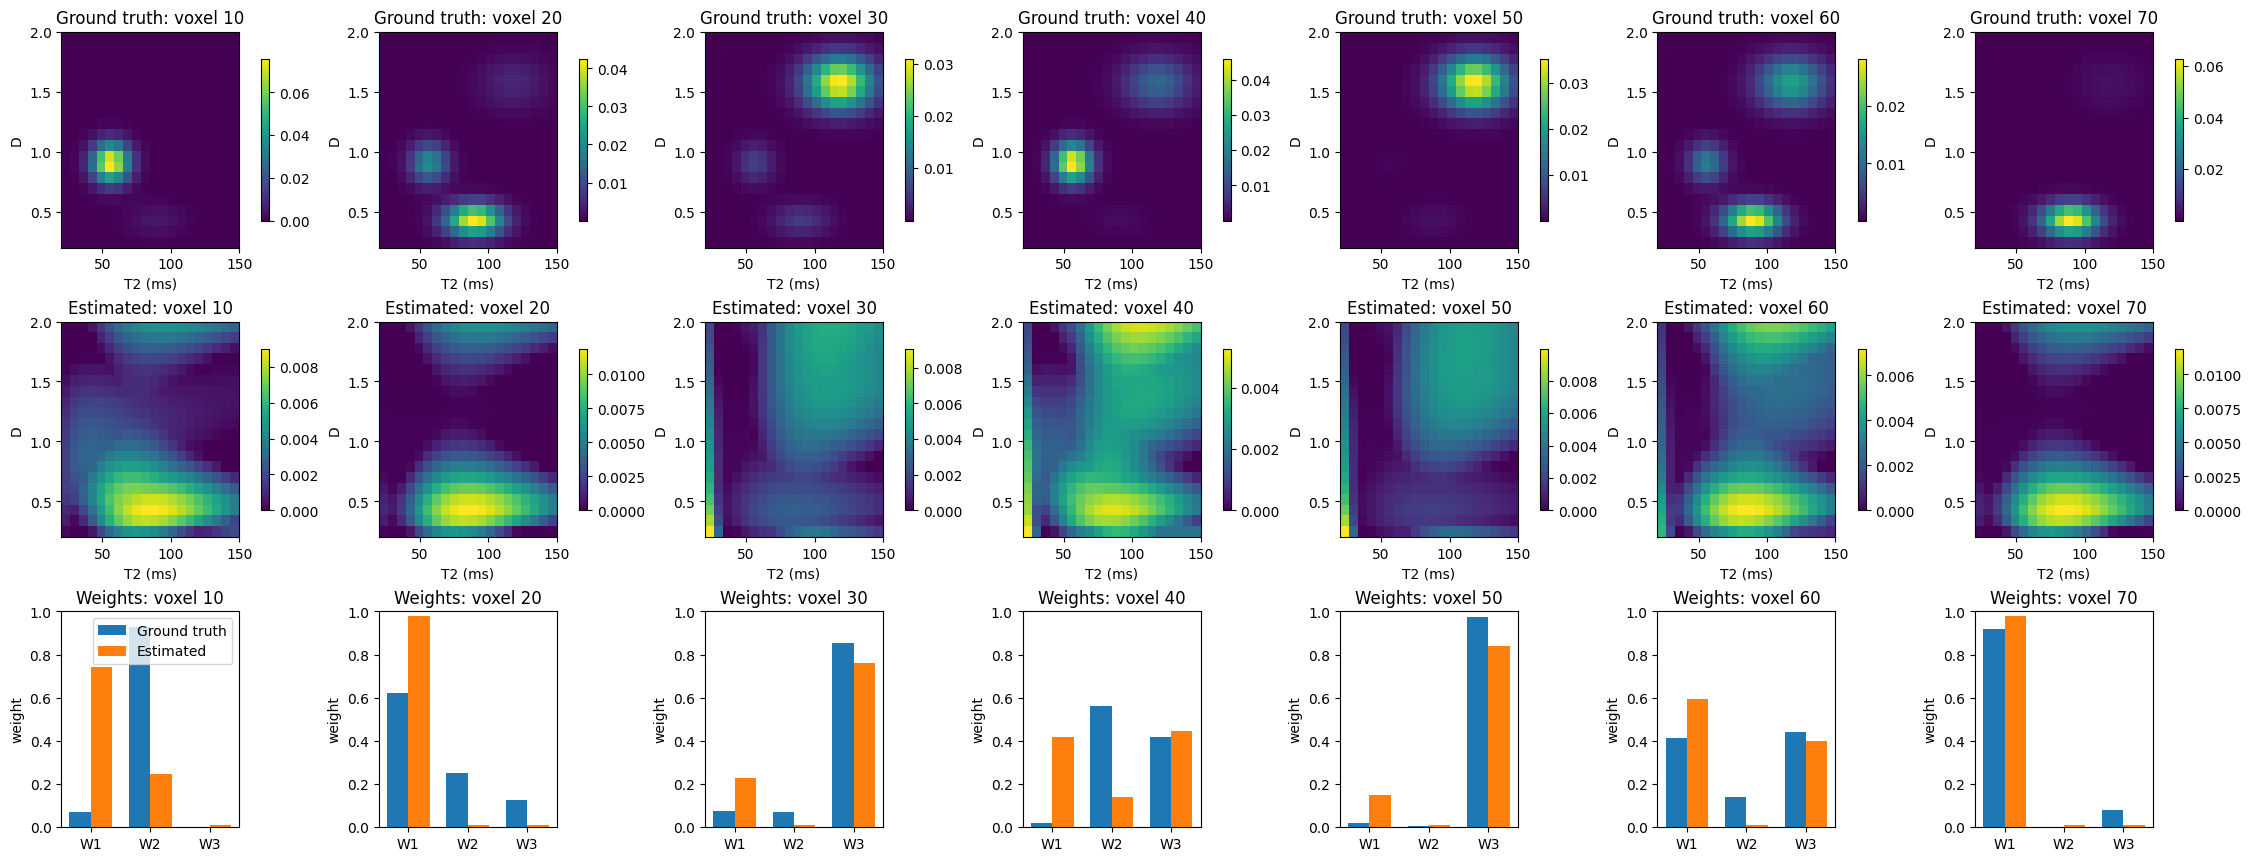

iter 0: loss=4564.4469, fit_err=299261.971806, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=3524.7410, fit_err=227419.195835, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 200: loss=3506.9516, fit_err=227395.640546, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 2, entropy prior: estimated C, W MAE 0.240


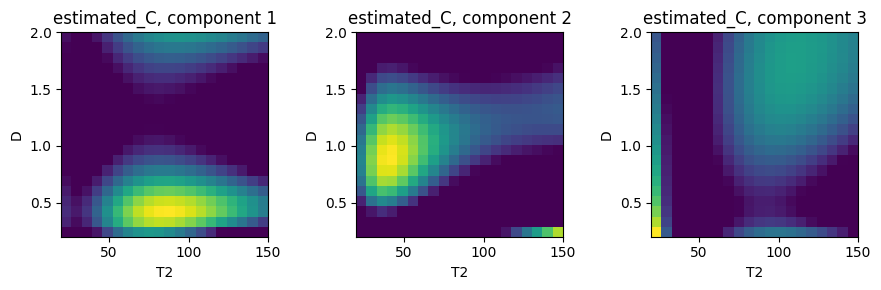

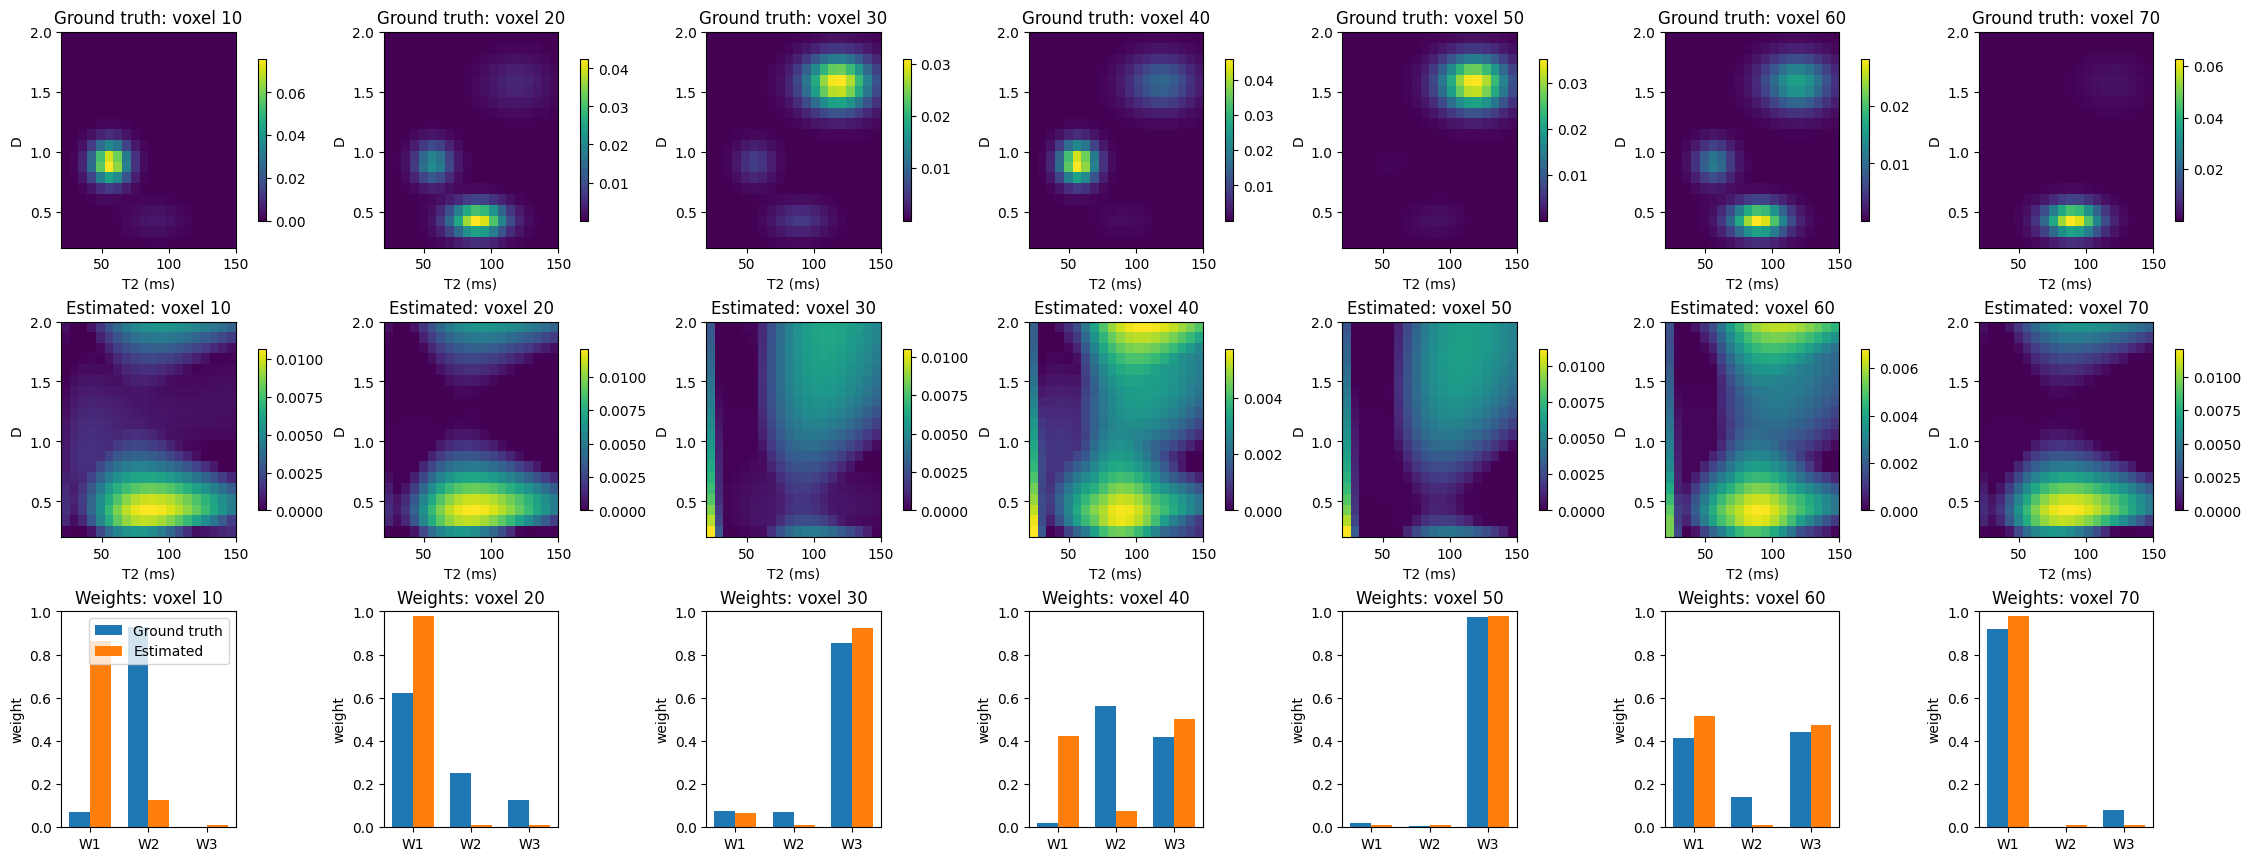

Seed 3: true C (first row) vs initial C (second row), starting W MAE 0.209


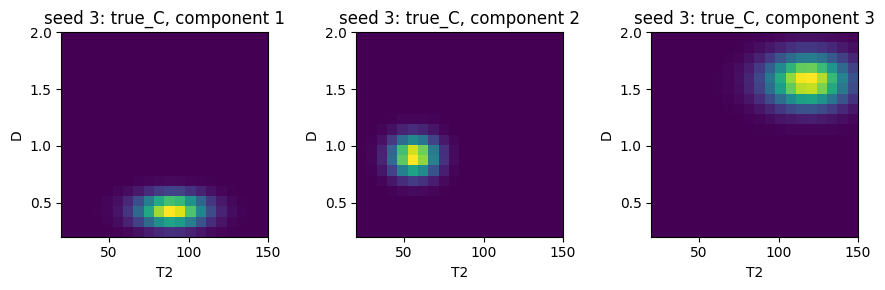

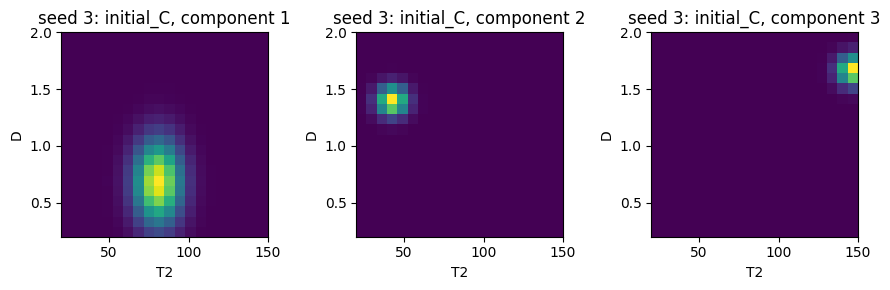



iter 0: loss=3593.6522, fit_err=262557.618864, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=2984.0923, fit_err=221442.437773, sigma2=36.000000, lam=0.0000, alpha=0.5029
iter 200: loss=2983.9486, fit_err=221442.520972, sigma2=36.000000, lam=0.0000, alpha=0.5024
Seed 3, dirichlet prior: estimated C, W MAE 0.192


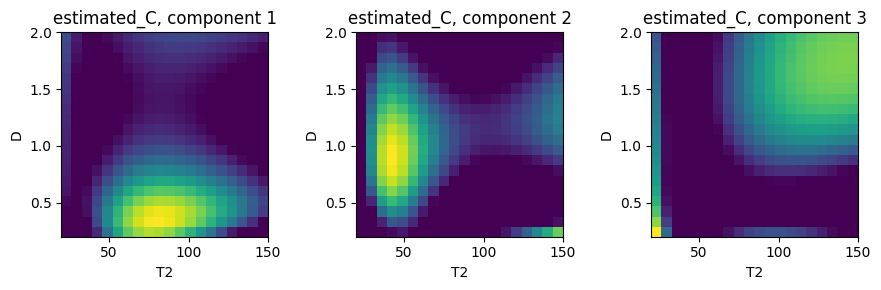

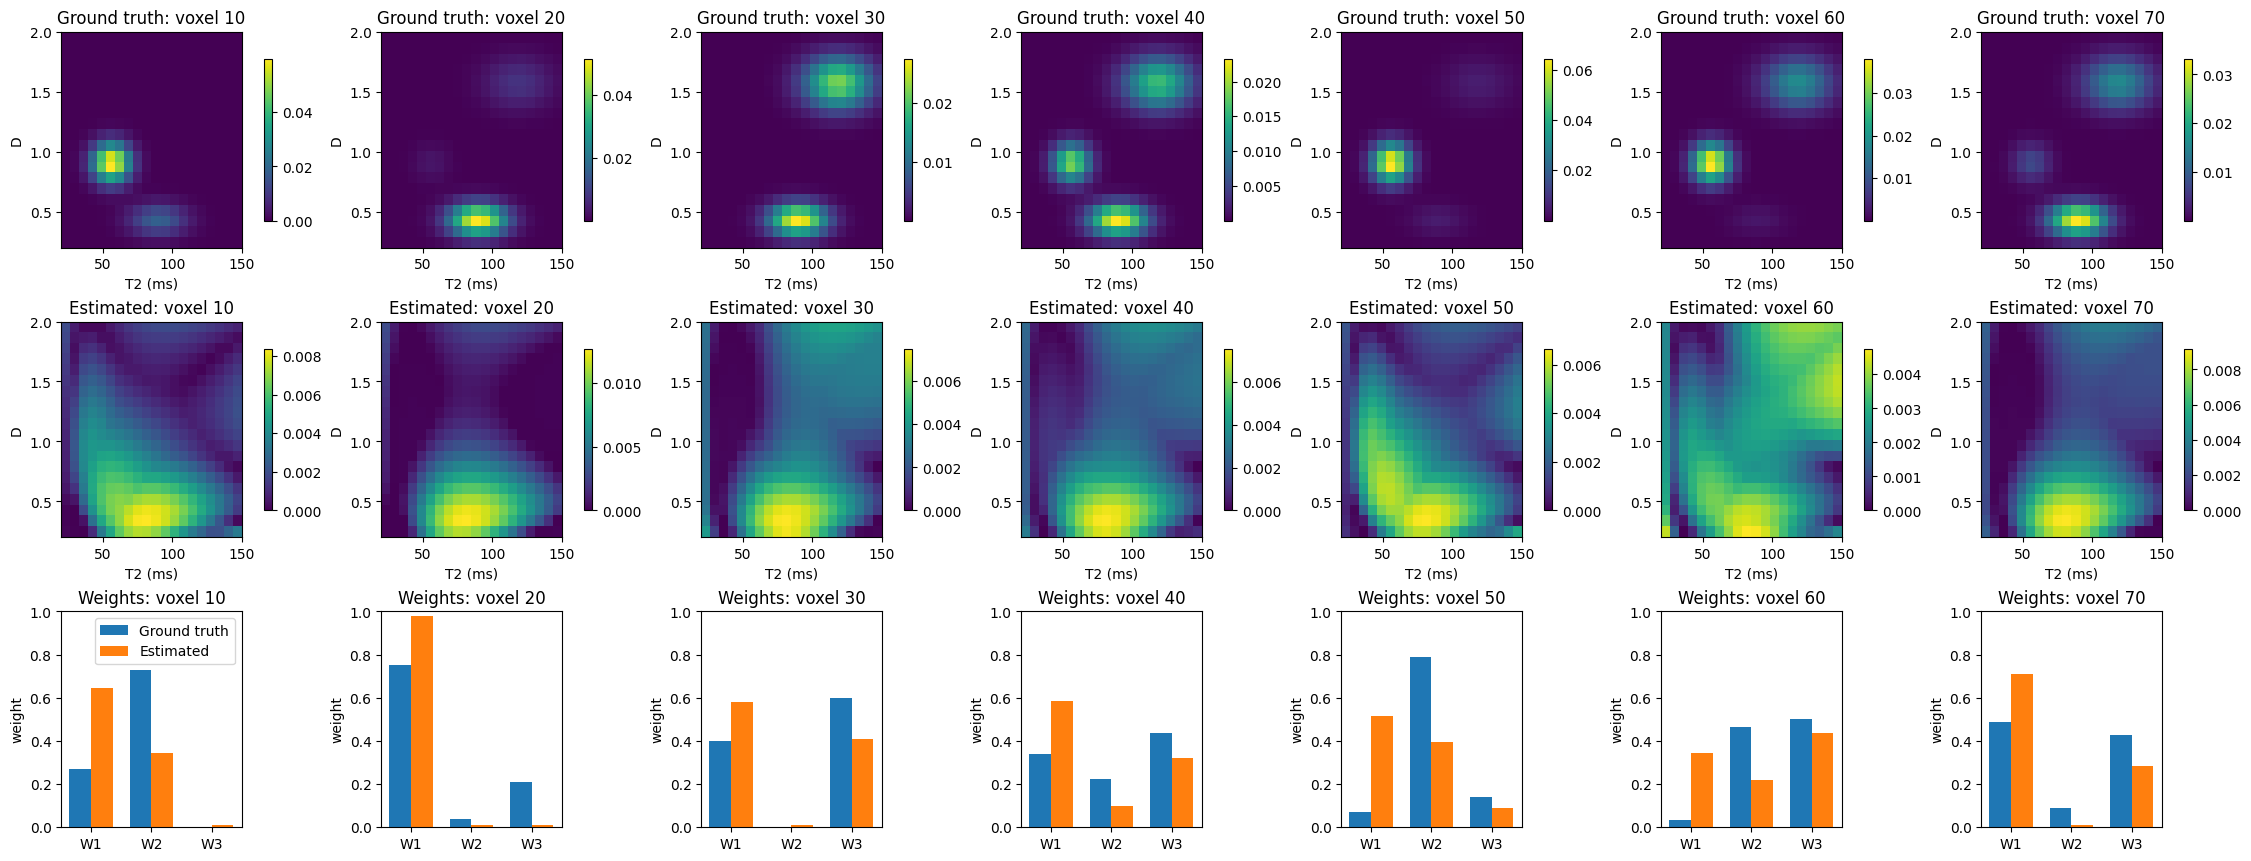

iter 0: loss=4157.1316, fit_err=269935.996096, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=3528.2519, fit_err=222506.433500, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 200: loss=3507.4136, fit_err=222777.803301, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 3, entropy prior: estimated C, W MAE 0.186


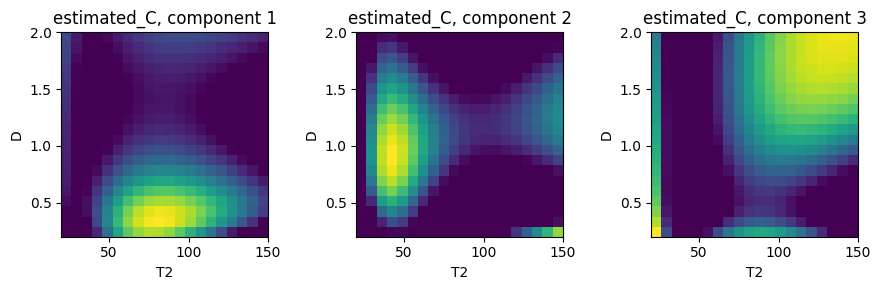

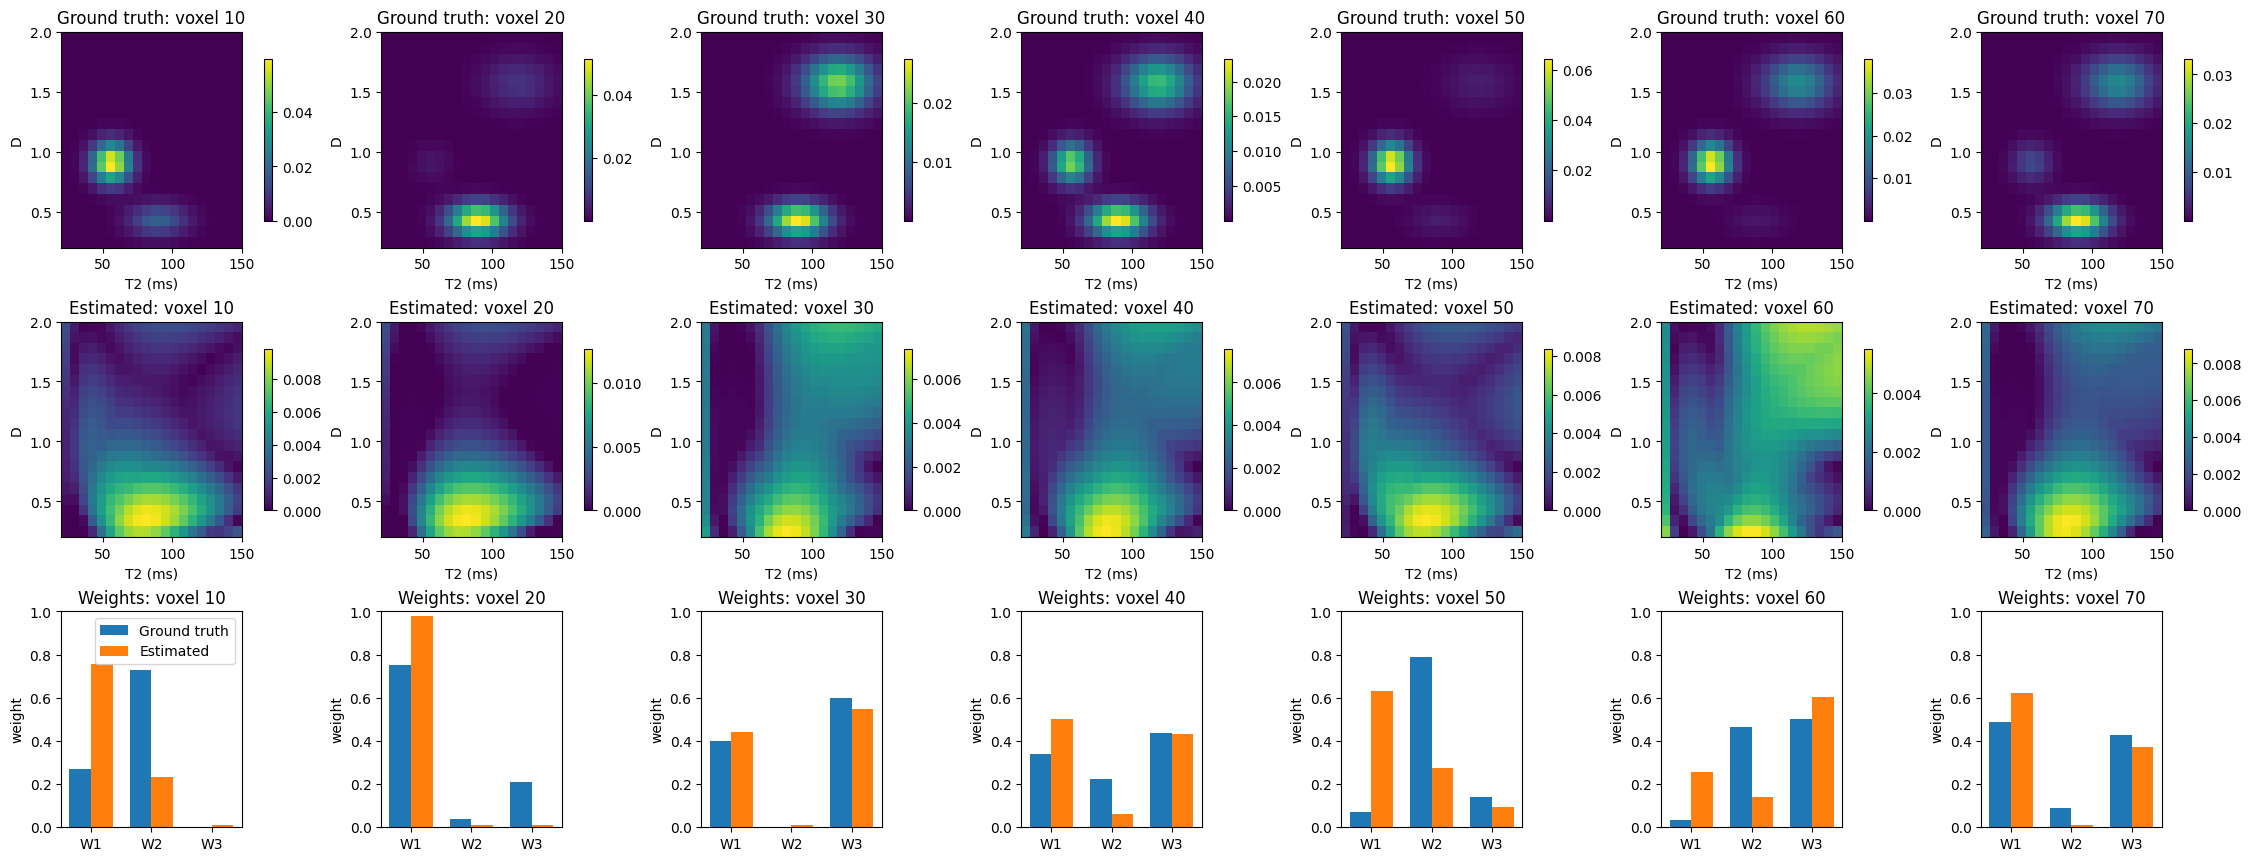

Seed 4: true C (first row) vs initial C (second row), starting W MAE 0.090


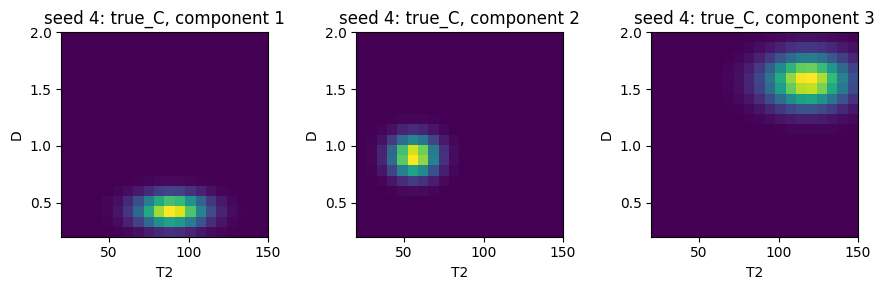

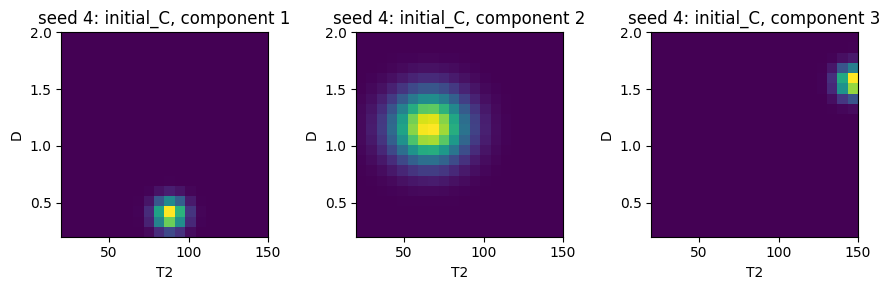



iter 0: loss=2414.9317, fit_err=177864.382925, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=2368.1576, fit_err=174620.895731, sigma2=36.000000, lam=0.0000, alpha=0.8450
iter 200: loss=2367.7948, fit_err=174605.204256, sigma2=36.000000, lam=0.0000, alpha=0.8393
Seed 4, dirichlet prior: estimated C, W MAE 0.072


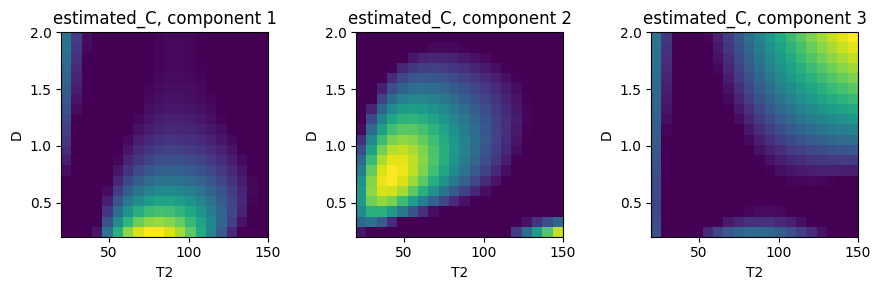

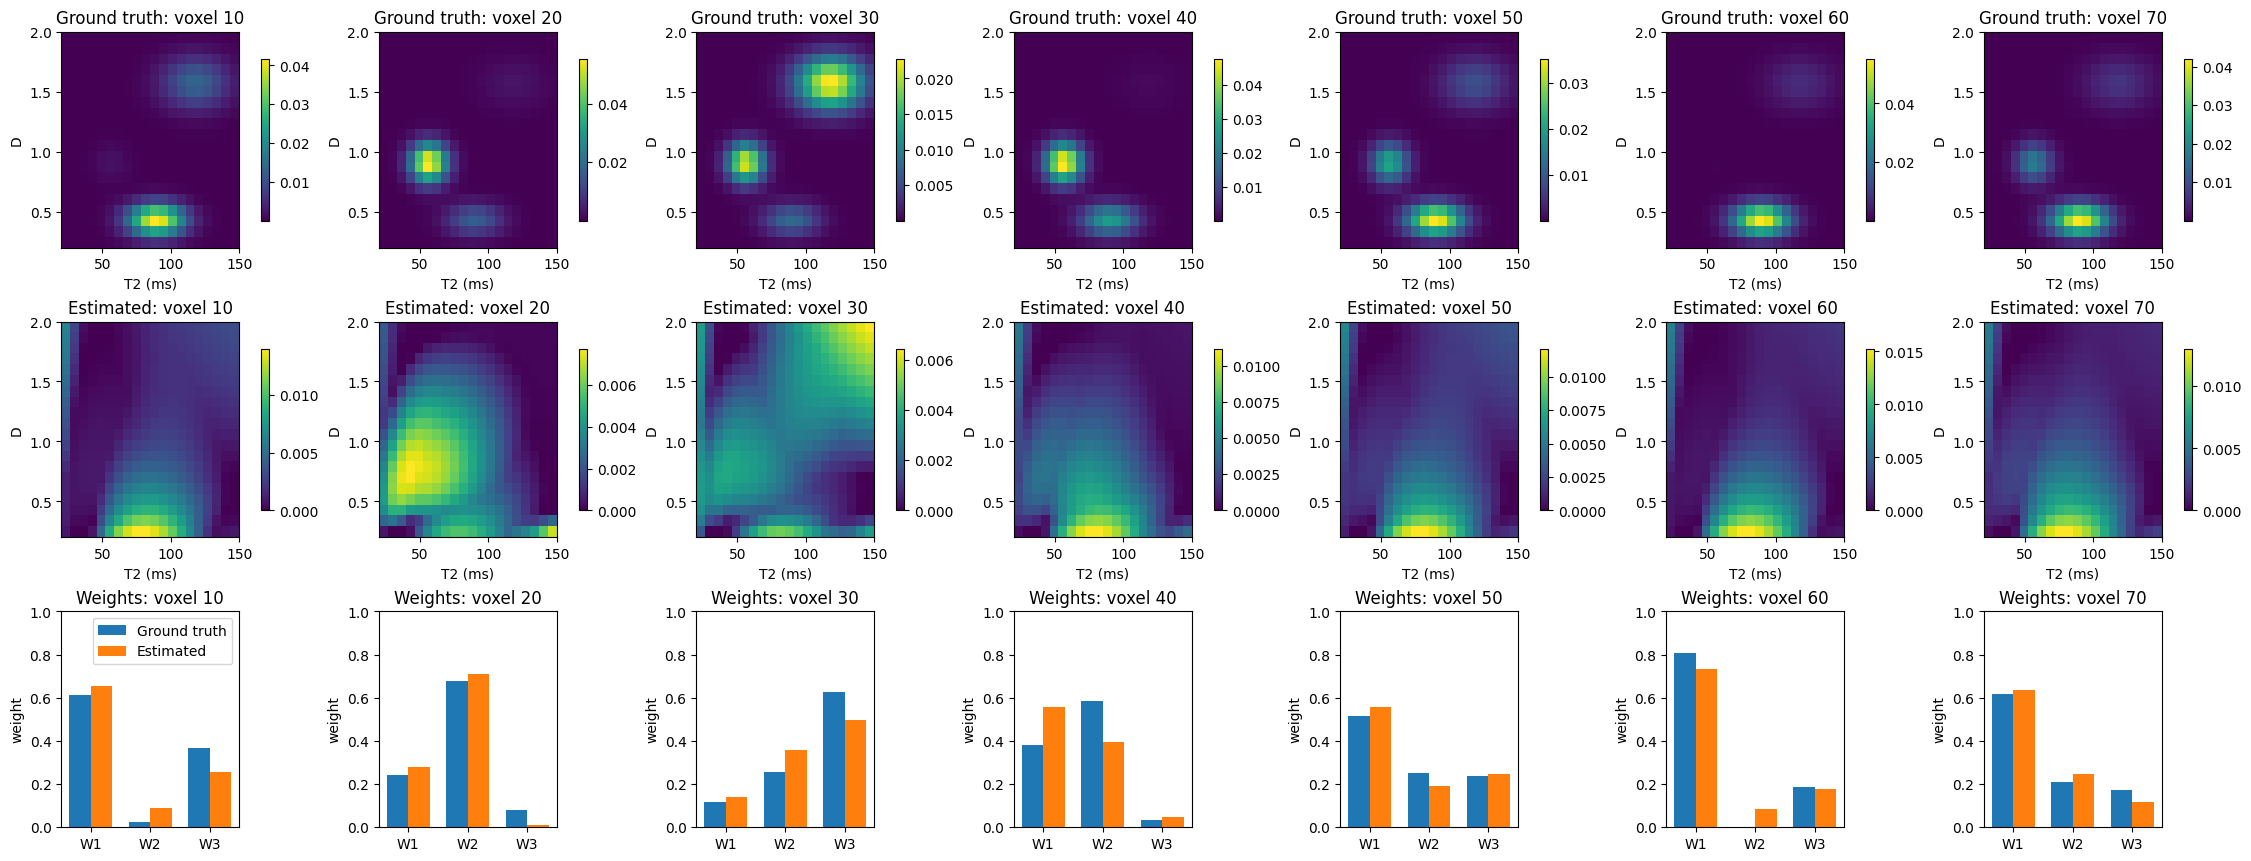

iter 0: loss=3058.3635, fit_err=179320.010738, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 100: loss=2922.0983, fit_err=178901.136473, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 200: loss=2922.0982, fit_err=178901.327628, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 4, entropy prior: estimated C, W MAE 0.042


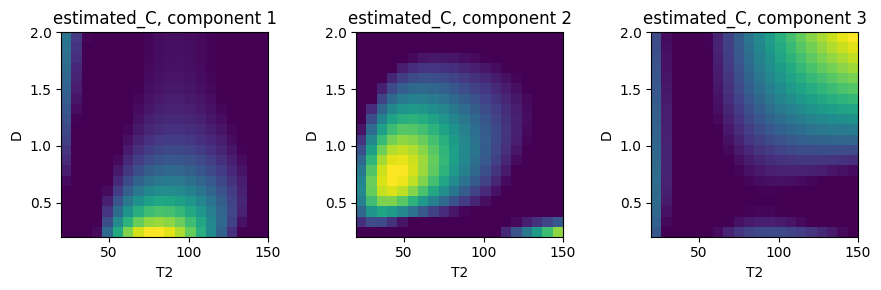

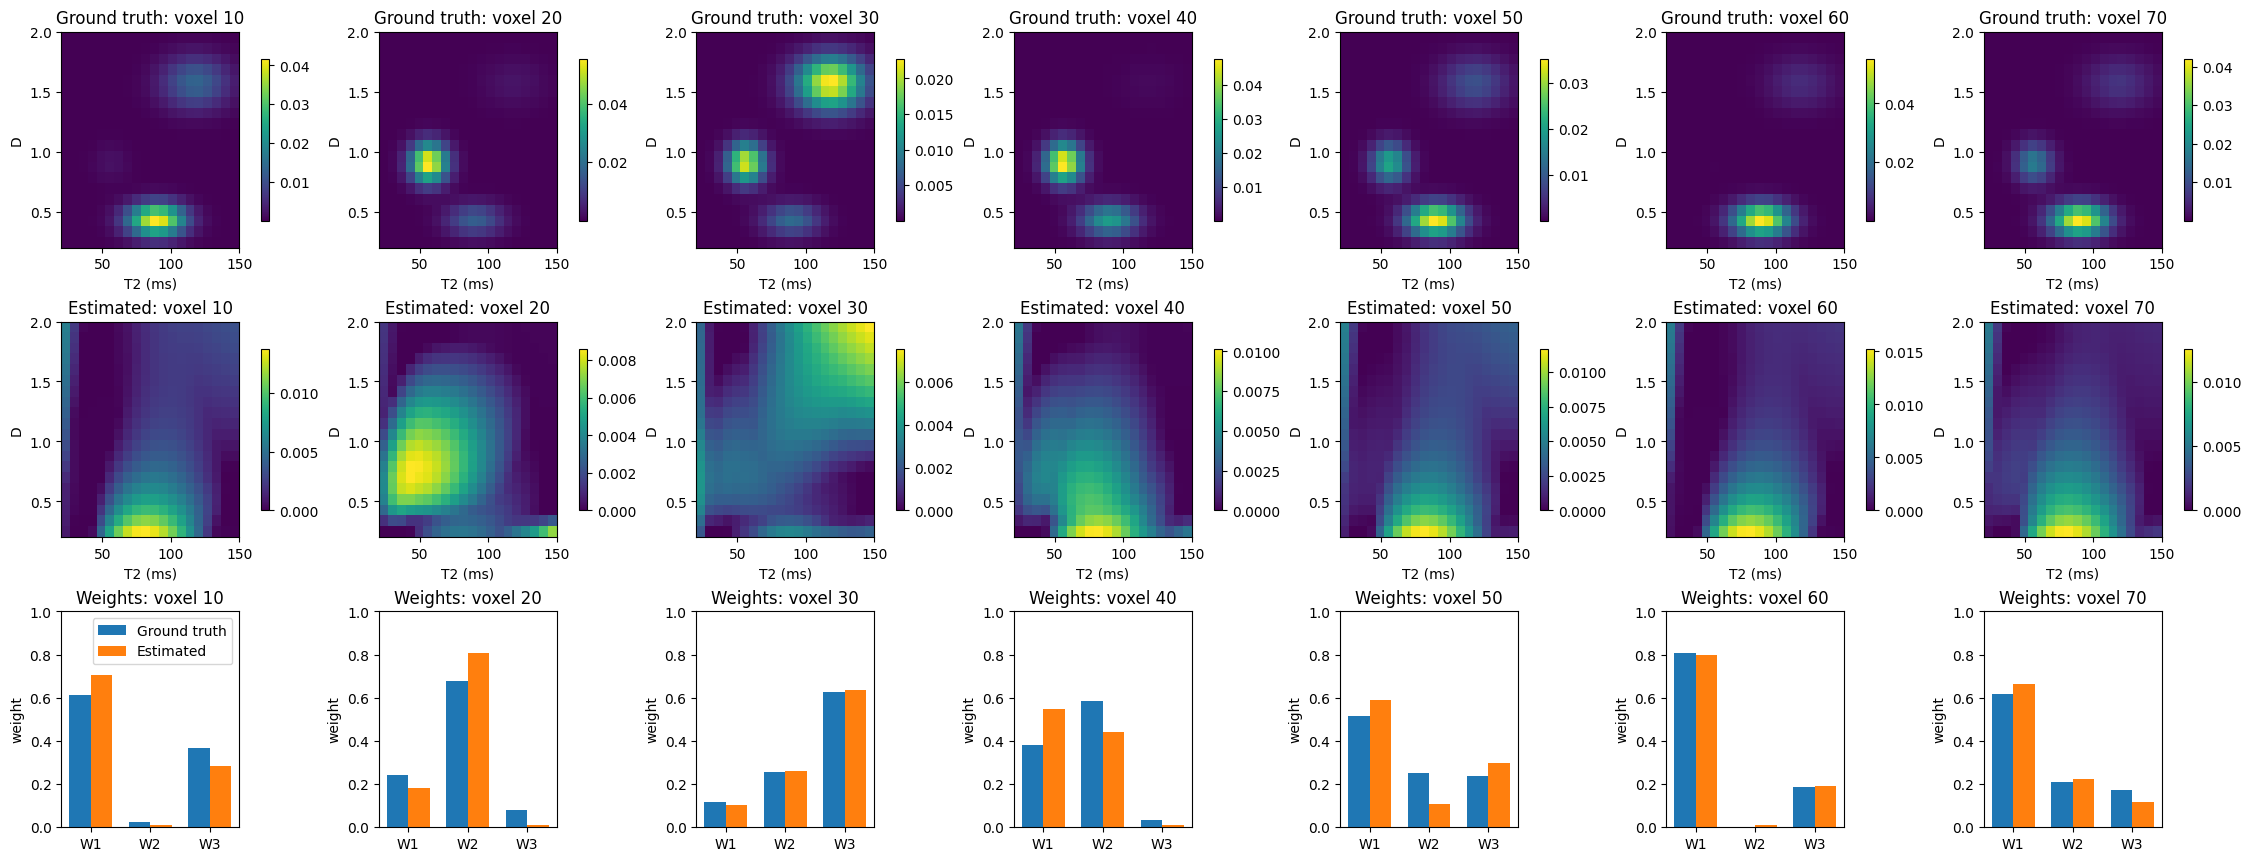

W MAE per seed: start, dirichlet, entropy
[[0.098 0.041 0.048]
 [0.206 0.185 0.219]
 [0.247 0.229 0.24 ]
 [0.209 0.192 0.186]
 [0.09  0.072 0.042]]
mean: [0.17  0.144 0.147]


In [39]:
# Dirichlet vs entropy prior on the same data, over several seeds
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

rows = []
for seed in range(5):
    rng_seed = np.random.default_rng(seed)
    alpha_true = 0.5
    W_true_dirichlet = rng_seed.dirichlet(alpha_true * np.ones(K), size=V).T

    # Calulate the signal Y = M0 * A * C_true * W_true
    Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_seed)

    # Set intial conditions
    C0_dirichlet=define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
    #^^^ This function could be re-written to not have so many arguments 
    Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

    M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

    print(f"Seed {seed}: true C (first row) vs initial C (second row), starting W MAE {np.mean(np.abs(W_true_dirichlet - W0_dirichlet)):.3f}")
    show_canonical_spectra([(f'seed {seed}: true_C', C_true)])
    show_canonical_spectra([(f'seed {seed}: initial_C', C0_dirichlet)])
    print("\n")


    # ----------------


    R = 10
    U, s, Vmat = apply_SVD_to_A(A, R)

    # C0 stays on the physical D–T2 grid, so it does not depend on R.
    Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

    # Refit weights because U @ Csmall0 has changed.
    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    errors = [np.mean(np.abs(W_true_dirichlet - W0_dirichlet))]
    for name, kwargs in priors.items():
        W_est_dirichlet, _, Csmall_est_dirichlet, *_ = run_optimisation(
            Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, K=K, R=R, eps=1e-10, n_iter=300,
            sigma2=np.mean(sigma**2), lam=1e-8, W=W0_dirichlet.copy(),
            update_W_flag=True, update_C_flag=True, update_M0_flag=True,
            m0_prior=M0_init_dirichlet, m0_prior_sigma=0.15, alpha=1.0, alpha_update_start=5,
            verbose_every=100, **kwargs)
        C_est_dirichlet, W_est_dirichlet = order_components(C_true, estimate_C(Vmat, s, Csmall_est_dirichlet), W_est_dirichlet, K)
        errors.append(np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
        print(f"Seed {seed}, {name} prior: estimated C, W MAE {errors[-1]:.3f}")
        show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])

        F_true = C_true @ W_true_dirichlet
        F_est = C_est_dirichlet @ W_est_dirichlet
        show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)

    rows.append(errors)

print("W MAE per seed: start, dirichlet, entropy")
print(np.round(rows, 3))
print("mean:", np.round(np.mean(rows, axis=0), 3))


**Result:**
- Both priors improve the weights from the initialisation on every seed. Neither prior is clearly better.
- On average the no mean initialisation ends slightly better, but which one wins changes from seed to seed.
- Seeds that end badly also fit the data worse than the noise level, which points to a bad starting point rather than a bad prior
